---
>「あなたが宇宙を理解することを望むなら、エネルギー、周波数、振動の観点から考えなさい。」\
>ニコラ・テスラ
---

# 音の分類

今回は、音を扱う　画像処理、テキスト処理、となれば、あとは音声処理ということになる

ただ、やることは基本的に同じである

# メルスペクトログラムの利用

音声処理にも様々な手法が存在する　従来はHMMが用いられたが、現在の主流はDNNの利用である

DNNを利用する際に、音声をそのまま波形データとして処理させることも可能といえば可能である
- 実際には処理コストが高く、かなりやっかいであることがわかる
- DNNは画像認識分野で発展が著しいため、これを応用すると考えるのは当然である
- そこで、音声を画像化するメルスペクトログラムの利用が想定され、音声解析手法としてよく利用されている

## 学習に用いるデータの取得


ESC-50データセットを利用する
- 環境音の分類手法ベンチマークとして準備されており、2000個の環境音がラベル付きで保存されている
- 5秒間の録音を50のクラス（1クラスあたり40例）収録されており、5つの主要なカテゴリーに大まかに分類されている

|動物|自然の音風景・水の音|人間・非音声の音|室内・家庭内の音|外・都市の音|
|-|-|-|-|-|
|犬|雨|赤ん坊の泣き声|ドアノック|ヘリ|
|雄鶏|海の波|くしゃみ|マウスクリック|チェーンソー|
|豚|燃える火|拍手|キーボード打鍵|サイレン|
|牛|コオロギ|呼吸|ドア・木のきしみ|車のクラクション|
|カエル|鳥のさえずり|咳をする|缶を開ける|エンジン|
|猫|水滴|足音|洗濯機|電車|
|雌鶏|風|笑い声|掃除機|教会の鐘|
|飛んでいる虫|水撒き|歯磨き|時計のアラーム|飛行機|
|羊|トイレの水洗|いびき|時計の音|花火|
|カラス|雷雨|飲む・すする|グラスを割る|鋸|

In [2]:
!pip install gdown
import os
if not os.path.exists('ESC-50-master/LICENSE'):
  !gdown 1OiP_cuLUVe4c0HzUB-vro4Jm106w_lOo
  !unzip -q ESC-50-master.zip

Downloading...
From (original): https://drive.google.com/uc?id=1OiP_cuLUVe4c0HzUB-vro4Jm106w_lOo
From (redirected): https://drive.google.com/uc?id=1OiP_cuLUVe4c0HzUB-vro4Jm106w_lOo&confirm=t&uuid=c4ca50bc-5222-4186-9502-711c08f721bb
To: /content/ESC-50-master.zip
100% 646M/646M [00:19<00:00, 32.7MB/s]


次に、データセットに関する各種設定と確認、さらにラベルデータの取得を行う

In [3]:
import pandas as pd

# gdownでダウンロードし/content配下に展開した環境音データセットのディレクトリを指定しておく（Google Driveのマウントは不要）
drive_dir = "ESC-50-master/"

# メタファイル（ファイル名にカテゴリーなどが紐づいた情報）がcsvファイルとして格納されているので、DataFrameで持っておく
meta_df = pd.read_csv(drive_dir + "meta/esc50.csv")

# メタファイルを確認する
display(meta_df.head())

# 全カテゴリーを取得して確認する
categories = meta_df['category'].unique()
print("データセットの数", meta_df.shape[0])
print(len(categories), categories[:10]) # いくつかカテゴリーを表示してみる
# データセットの数 2000
# 50 ['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock' 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw']

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


データセットの数 2000
50 ['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock'
 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw']


必要なライブラリを読み込む

In [4]:
import os
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

## 音響特徴量「メルスペクトル」と「MFCC（メル周波数ケプストラム係数）」

音響特徴量の利用
- 単純に収音データ（信号波形）をモデルに入力しただけでは上手くいかないことが多く学習する上で重要な情報とそうでない情報とを考慮する必要がある
- 一般に、音データのような信号波形ではフーリエ変換したスペクトルを起点に考えることが多く、これから得られる重要な情報のことを音響特徴量と呼ぶ
- 音響特徴量として、「メルスペクトル」と「MFCC（メル周波数ケプストラム係数）」が著名で、音声認識の分野では非常に馴染みの深い特徴量

### 波形

単に音をサンプリングし、その値を時系列で示したグラフ

### スペクトル

ある信号波形をあらゆる周波数の正弦波の合成の形で分解し、各周波数成分の強さを得るためにフーリエ変換を利用する
- この時の各周波数成分の強さを示したグラフを信号波形のパワースペクトルと呼ぶ
- サンプリング周波数がCD音質、つまり44100Hzのとき、サンプリング定理から半分の22050Hz（ナイキスト周波数と呼ぶ）まで周波数成分の強さを見ることができる
- 詳細は後述するが、音響解析では特に短時間フーリエ変換が利用される

### メル尺度とメル周波数

メル尺度は、人間の聴覚に基づいた尺度で、低周波数の音に対して敏感で、高周波数の音に対して鈍感である性質に基づいた尺度
- メル尺度の差が同じであれば、人間が感じる音高の差が同一
- 1000Hzの音を1000melの音高と定め以下の関係式で表現する
  - melはメル尺度をfは周波数を意味する

$$ mel = 2595.0 \times \log_{10}(1.0 + f / 700.0) $$

22050Hz（ナイキスト周波数）に対応するメル尺度について、メル尺度での等間隔分割が、周波数でどのような分割になるかを示したのが次の図である

<img src="http://class.west.sd.keio.ac.jp/dataai/text/mel4.png" width=600>

### スペクトルをメルスペクトルに変換

さて、実際にスペクトルをメルスペクトル、すなわちメル尺度で変換されたスペクトルに変換するには、次のようなメルフィルタバンクと呼ばれる三角窓のフィルタを作成し、内積を求めることで得る

<img src="http://class.west.sd.keio.ac.jp/dataai/text/mel5.png" width=600>

ここではすべて面積1の64本の三角窓のフィルタ(歯数)を記述している
- もちろん歯数はいくらでも調整できる
- 高周波ほど底辺が大きく高さが低くなる
- 各フィルタは、周辺周波数を加味した移動平均ともとらえることができる

このようにして得られたメルスペクトルは、用いたメルフィルタバンクが歯数64のフィルタで構成されていれば、17640（=44100Hz \times 0.8s/2）ポイントの情報を持つスペクトルから、64（=指定したメル周波数の分割数）に情報が縮約できる
- つまり、学習に利用できるように「情報の特徴量を抽出した」といえる
- 時系列にならべて、その大きさを明度として表せば絵の情報として利用できる

### スペクトルをMFCCに変換

メルスペクトルをそのまま利用して音響特徴量として利用できるが、さらにここから、MFCCと呼ばれる音声認識等で良く使用される特徴量が生成できる

実際の音響分析では、歯数として128といった値が用いられるが、これではまだ情報量が多いため、さらに圧縮する方法として次のような手法がある

1. ケプストラム分析 メルスペクトルそのものをさらにスペクトルとみなして対数表現を行い、さらにフーリエ変換を施して成分分析を行う手法、ある時の各成分の変化特徴を見ているようなイメージ

1. MFCC メルスペクトルに対して、離散コサイン変換し得られた成分、あるいは係数により構成する手法
  -  係数として第0成分はDC成分のため除いて、第1〜12成分などが利用される

音源データを読み込み、波形で可視化する、モデルに投入する各種特徴量（メルスペクトログラムやMFCCなど）を取得するためのライブラリlibrosaを利用する

波形データのデータタイプ <class 'numpy.ndarray'>
メルスペクトログラムのデータタイプ <class 'numpy.ndarray'>
MFCCのデータタイプ <class 'numpy.ndarray'>
サンプルレート 22050
波形データの形状 (110250,)
メルスペクトログラムの形状 (128, 216)
MFCCの形状 (20, 216)
category : toilet_flush


/tmp/ipykernel_591/3638764190.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  filename = row[1][0] # wavファイル名
/tmp/ipykernel_591/3638764190.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  category = row[1][1] # そのファイルのカテゴリ


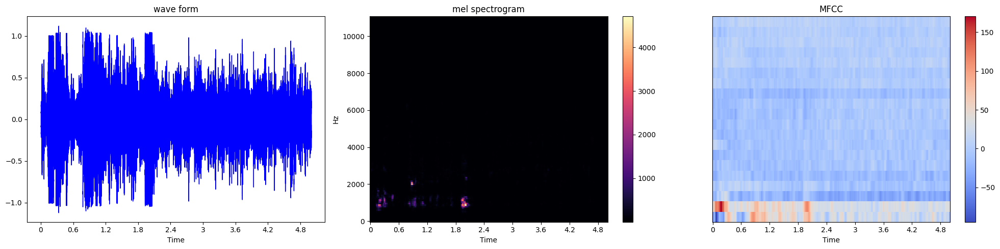

category : vacuum_cleaner


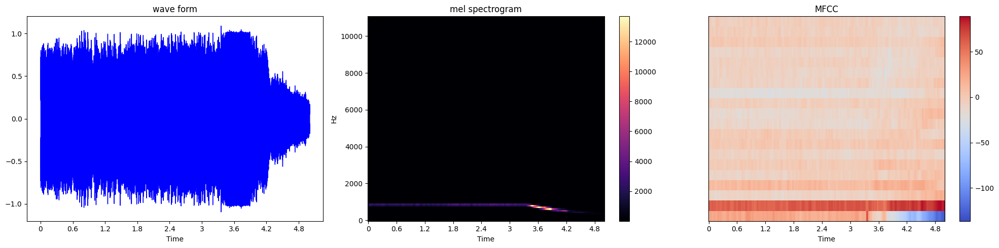

category : cow


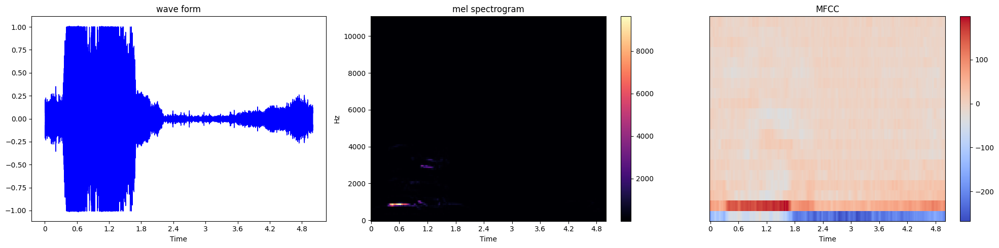

In [5]:
# とりあえず1つの音源ファイルを指定してlibrosaを使ってみる
#librosa.loadで音源の波形データ（第1戻り値）とサンプルレート（第2戻り値）を取得できる
waveform, sample_rate = librosa.load(drive_dir + "audio/1-100032-A-0.wav") # 犬の鳴き声の音源データを指定

# メルスペクトログラムの取得
# librosa.feature.melspectrogramに上で取得した波形データとサンプルレートを渡せば
# 一発でメルスペクトログラムを取得できる
feature_melspec = librosa.feature.melspectrogram(y=waveform, sr=sample_rate)

# MFCCの取得
# librosa.feature.mfccでOK
feature_mfcc = librosa.feature.mfcc(y=waveform, sr=sample_rate)

# 波形データ、メルスペクトログラム、MFCCはnumpy形式で得られる
print("波形データのデータタイプ", type(waveform))
print("メルスペクトログラムのデータタイプ", type(feature_melspec))
print("MFCCのデータタイプ", type(feature_mfcc))
print("サンプルレート", sample_rate)
print("波形データの形状", waveform.shape)
print("メルスペクトログラムの形状", feature_melspec.shape)
print("MFCCの形状", feature_mfcc.shape)

# ランダムに3つほど音源データをピックアップし、波形、メルスペクトログラム、MFCCを可視化する
# ついでにnotebook上で音源の再生ができるようにする
for row in meta_df.sample(frac=1)[['filename', 'category']][:3].iterrows():
  filename = row[1][0] # wavファイル名
  category = row[1][1] # そのファイルのカテゴリ

  # 波形データとサンプルレートを取得
  waveform, sample_rate = librosa.load(drive_dir + "audio/" + filename)

  # メルスペクトログラムを取得
  feature_melspec = librosa.feature.melspectrogram(y=waveform, sr=sample_rate)

  # MFCCを取得
  feature_mfcc = librosa.feature.mfcc(y=waveform, sr=sample_rate)

  # 可視化
  print("category : " + category)
  plt.figure(figsize=(20, 5))

  # librosa.display.waveplotで波形データを可視化できる
  plt.subplot(1,3,1)
  plt.title("wave form")
  librosa.display.waveshow(waveform, sr=sample_rate, color='blue')

  # librosa.display.specshowでメルスペクトログラム、MFCCを可視化できる
  plt.subplot(1,3,2)
  plt.title("mel spectrogram")
  librosa.display.specshow(feature_melspec, sr=sample_rate, x_axis='time', y_axis='hz')
  plt.colorbar()

  plt.subplot(1,3,3)
  plt.title("MFCC")
  librosa.display.specshow(feature_mfcc, sr=sample_rate, x_axis='time')
  plt.colorbar()

  plt.tight_layout()
  plt.show()
  print()

  # 音源の再生はlibrosaで取得できた波形データとサンプルレートを
  # IPython.display.Audioに以下のようにして渡す
  display(ipd.Audio(waveform, rate=sample_rate))

実際に再生してみるとよい

メルスペクトログラムやMFCCはある種チャネル数1の画像データとみなすことができ、画像とみなした時の隣接ピクセルは密接な関係性があり、離れたピクセル同士はそうではない、という特徴があると考えられ、であるならば、CNNが利用できる

## メルスペクトログラムのデシベルスケール変換

上記のメルスペクトログラムをそのまま用いると、0付近の値が多いためうまくCNNを用いても学習できないためさらなる工夫が必要
- 周波数に関しては人間の聴覚特性に応じて変換した
- であれば音圧も人間の聴覚特性に応じて変換すればよい、ならばデシベルだ

そもそも人間の聴覚特性で変換することがよいのか悪いのかという疑問もあるが、人が進化で獲得した能力なのだから、従うのがよいのでは？と納得し、そもそも、情報が多すぎて必要な情報をうまく勘案できない事態は避けたい

librosaでは、メルスペクトログラムにlibrosa.power_to_dbを施せばデシベルスケールに変換できる
- つまり基本的にはlibrosa.feature.melspectrogramでメルスペクトログラムを抽出、librosa.power_to_dbでデシベルスケールに変換、この手順を施したデータをメルスペクトログラムと呼ぶ場合も多い

実際にメルスペクトログラムの音圧をデシベルスケールに変換して可視化すると次のようになり、CNNを用いて解析できそうな画像となる

category : sneezing


/tmp/ipykernel_591/1300397727.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  filename = row[1][0] # wavファイル名
/tmp/ipykernel_591/1300397727.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  category = row[1][1] # そのファイルのカテゴリ


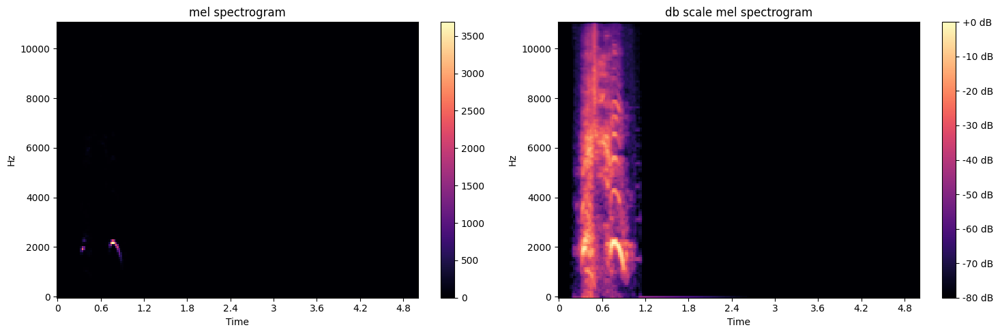

category : water_drops


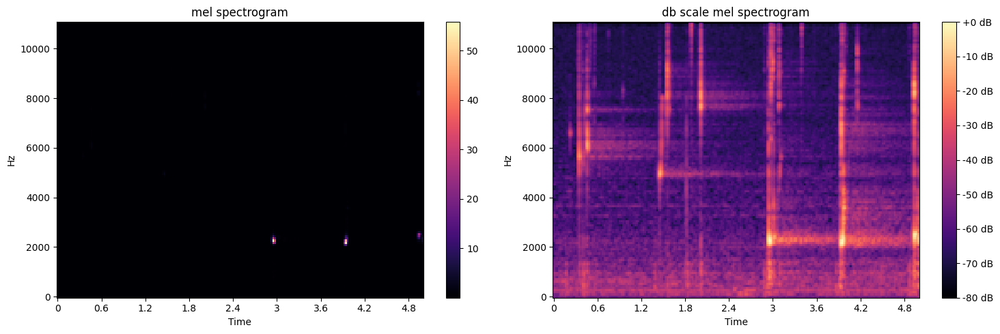

category : wind


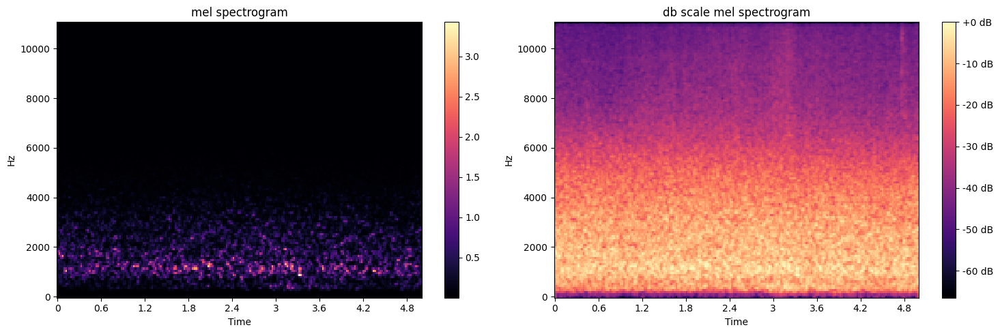

In [6]:
for row in meta_df.sample(frac=1)[['filename', 'category']][:3].iterrows():
  filename = row[1][0] # wavファイル名
  category = row[1][1] # そのファイルのカテゴリ

  waveform, sample_rate = librosa.load(drive_dir + "audio/" + filename)

  # メルスペクトログラムを求める
  feature_melspec = librosa.feature.melspectrogram(y=waveform, sr=sample_rate)

  print("category : " + category)
  plt.figure(figsize=(15,5))

  # librosa.feature.melspectrogramをそのまま可視化した場合
  plt.subplot(1,2,1)
  plt.title("mel spectrogram")
  librosa.display.specshow(feature_melspec, sr=sample_rate, x_axis='time', y_axis='hz')
  plt.colorbar()

  # デシベルスケールに変換した場合
  plt.subplot(1,2,2)
  plt.title("db scale mel spectrogram")
  feature_melspec_db = librosa.power_to_db(feature_melspec, ref=np.max)
  librosa.display.specshow(feature_melspec_db, sr=sample_rate, x_axis='time', y_axis='hz')
  plt.colorbar(format='%+2.0f dB')

  plt.tight_layout()
  plt.show()

# CNNを用いた分類

ここでは、学習済みモデルであるResNetを利用して転移学習（ファインチューニング）させる
- 準備に10分弱かかる

In [7]:
class ESC50Data(Dataset):
  def __init__(self, base_path, df, in_col, out_col):
    self.df = df
    self.data = [] # 音源データをメルスペクトログラム（画像）に変換して格納
    self.labels = [] # 各データのカテゴリー情報を格納する
    self.category2id={}
    self.id2category={}
    self.categories = list(sorted(df[out_col].unique())) # 正解ラベル格納用（５０ラベル）
    # ラベルをIDに変換する辞書を作成
    for i, category in enumerate(self.categories):
      self.category2id[category] = i
      self.id2category[i] = category

    # メタ情報ファイルからファイル名を取得し、wavデータを1件ずつ画像に変換
    for row in tqdm(range(len(df))):
      row = df.iloc[row]
      file_path = os.path.join(base_path, row[in_col])
      waveform, sr = librosa.load(file_path)

      # メルスペクトログラムを取得してデシベルスケールに変換
      feature_melspec = librosa.feature.melspectrogram(y=waveform, sr=sr)
      feature_melspec_db = librosa.power_to_db(feature_melspec, ref=np.max)

      self.data.append(feature_melspec_db)
      self.labels.append(self.category2id[row['category']])

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.data[idx], self.labels[idx]

# メタ情報ファイルを学習データとテストデータに分ける
train_df, test_df = train_test_split(meta_df, train_size=0.8)

# メタ情報ファイルから音源データをDataLoaderに変換する
train_data = ESC50Data(drive_dir + "audio/", train_df, 'filename', 'category')
test_data = ESC50Data(drive_dir + "audio/", test_df, 'filename', 'category')
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=True)

100%|██████████| 400/400 [00:19<00:00, 20.53it/s]


In [8]:
from torchvision.models import resnet34, ResNet34_Weights

# 学習済みのResNetをダウンロード
resnet_model = resnet34(weights=ResNet34_Weights.DEFAULT)

# ResNetの構造を出力して確認
print(resnet_model)
# 最初の畳み込みのチャネル3をチャネル1に変更
resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# 最後の層の次元を今回のカテゴリ数に変更
resnet_model.fc = nn.Linear(512,50)

# GPUを利用
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resnet_model = resnet_model.to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=2e-4)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 124MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 学習と検証

5分程度かかる

In [9]:
losses = []
for epoch in range(50):

  # 学習
  train_losses = 0

  for data in train_loader:
    optimizer.zero_grad()
    x, y = data
    x = x.to(device, dtype=torch.float32)
    y = y.to(device)
    x = x.unsqueeze(1) # チャネル数1を挿入
    out = resnet_model(x)
    loss = loss_function(out, y)
    loss.backward()
    optimizer.step()
    train_losses += loss.item()

  # 検証
  test_losses = 0
  actual_list, predict_list = [], []

  for data in test_loader:
    with torch.no_grad():
      x, y = data
      x = x.to(device, dtype=torch.float32)
      y = y.to(device)
      x = x.unsqueeze(1)
      out = resnet_model(x)
      loss = loss_function(out, y)
      _, y_pred = torch.max(out, 1)
      test_losses += loss.item()

      actual_list.append(y.cpu().numpy())
      predict_list.append(y_pred.cpu().numpy())

  actual_list = np.concatenate(actual_list)
  predict_list = np.concatenate(predict_list)
  accuracy = np.mean(actual_list == predict_list)

  print("epoch", epoch, "\t train_loss", train_losses,
        "\t test_loss", test_losses, "\t accuracy", accuracy)

epoch 0 	 train_loss 129.82456481456757 	 test_loss 22.633381485939026 	 accuracy 0.56
epoch 1 	 train_loss 52.248870730400085 	 test_loss 16.606740474700928 	 accuracy 0.6225
epoch 2 	 train_loss 29.211431831121445 	 test_loss 16.550120532512665 	 accuracy 0.64
epoch 3 	 train_loss 18.799906477332115 	 test_loss 14.74049562215805 	 accuracy 0.685
epoch 4 	 train_loss 12.25298498570919 	 test_loss 14.018212616443634 	 accuracy 0.71
epoch 5 	 train_loss 7.615922752767801 	 test_loss 13.273734152317047 	 accuracy 0.74
epoch 6 	 train_loss 7.1609664633870125 	 test_loss 13.177084267139435 	 accuracy 0.745
epoch 7 	 train_loss 5.572527553886175 	 test_loss 15.530577719211578 	 accuracy 0.7125
epoch 8 	 train_loss 6.672794567421079 	 test_loss 13.913979053497314 	 accuracy 0.7375
epoch 9 	 train_loss 5.098641188815236 	 test_loss 14.09288889169693 	 accuracy 0.7225
epoch 10 	 train_loss 6.032125419005752 	 test_loss 16.530491888523102 	 accuracy 0.68
epoch 11 	 train_loss 7.435121651738882 

# 演習課題

ResNetの利用は大変コストがかかり、実行速度が遅いため、精度は気にせず、自分なりのモデルを構築して学習させなさい
- 精度はマルチラベルで50%以上達成すればよい
- なお、時間に余裕がある場合は、ResNetのままでも構わない

また、実際に自身で生活音などを録音してwavファイルを生成、上記のモデルを利用して、正解するかどうか確認しなさい

# 演習問題

データ拡張を用いて精度を向上させなさい

# 参考となる関数やテクニック


関係する関数群として次の項目をまとめておく
- 波形の読み込み
- メルスペクトログラムへの変換
- 波形の表示
- ヒートマップの表示

wave size:(220500,)
melsp size:(128, 1723)
sampling rate:44100


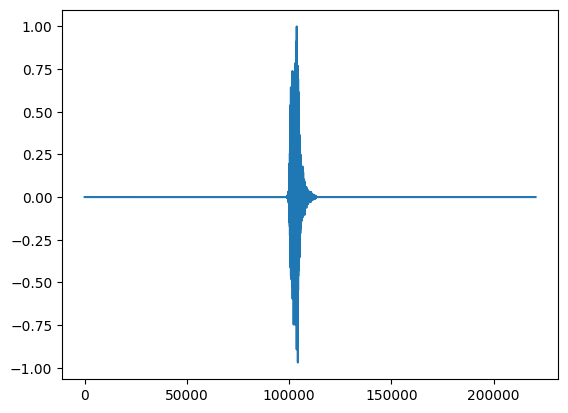

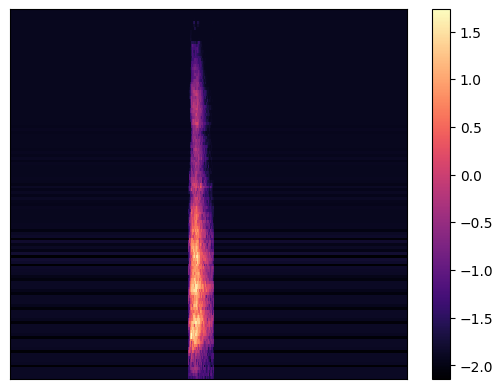

In [10]:
# load a wave data
def load_wave_data(audio_dir, file_name):
    file_path = os.path.join(audio_dir, file_name)
    x, fs = librosa.load(file_path, sr=44100)
    return x,fs

# change wave data to mel-stft
def calculate_melsp(x, n_fft=1024, hop_length=128):
    stft = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop_length))**2
    log_stft = librosa.power_to_db(stft)
    melsp = librosa.feature.melspectrogram(S=log_stft,n_mels=128)
    return melsp

# display wave in plots
def show_wave(x):
    plt.plot(x)
    plt.show()

# display wave in heatmap
def show_melsp(melsp, fs):
    librosa.display.specshow(melsp, sr=fs)
    plt.colorbar()
    plt.show()

# example data
audio_dir = 'ESC-50-master/audio'
meta_file = 'ESC-50-master/meta/esc50.csv'
meta_data = pd.read_csv(meta_file)
x, fs = load_wave_data(audio_dir, meta_data.loc[0,"filename"])
melsp = calculate_melsp(x)
print("wave size:{0}\nmelsp size:{1}\nsampling rate:{2}".format(x.shape, melsp.shape, fs))
show_wave(x)
show_melsp(melsp, fs)

## STFTについて

一般に、音声データに短時間フーリエ変換（Short-time Fourier transform : STFT）を施してスペクトログラムを得る
- 先の例では、librosaの機能を使って一発で変換したが、実際には内部でSTFTが利用されている

STFTの手順
- 音声信号のある時間範囲を窓で区切り、その窓の範囲でフーリエ変換を行うことで、該当する時間範囲での周波数スペクトルを求める
- 窓をずらしながら計算繰り返すことで、周波数スペクトルの時間経過の行列Dを得る
- 次のようなパラメタが存在する
  - n_fft（窓の長さ） デフォルト値は2048
  - hop_length（窓の移動幅） デフォルト値はn_fft/4
  - librosaのstft関数は2次元テンソルを返す

<img src="http://class.west.sd.keio.ac.jp/dataai/text/stft.webp" width=600>

In [11]:
def griffinlim(spectrogram, n_iter = 100, window = 'hann', n_fft = 2048, hop_length = -1, verbose = False):
    if hop_length == -1:
        hop_length = n_fft // 4
    angles = np.exp(2j * np.pi * np.random.rand(*spectrogram.shape))
    t = tqdm(range(n_iter), ncols=100, mininterval=2.0, disable=not verbose)
    for i in t:
        full = np.abs(spectrogram).astype(np.complex128) * angles
        inverse = librosa.istft(full, hop_length = hop_length, window = window)
        rebuilt = librosa.stft(inverse, n_fft = n_fft, hop_length = hop_length, window = window)
        angles = np.exp(1j * np.angle(rebuilt))
        if verbose:
            diff = np.abs(spectrogram) - np.abs(rebuilt)
            t.set_postfix(loss=np.linalg.norm(diff, 'fro'))
    full = np.abs(spectrogram).astype(np.complex128) * angles
    inverse = librosa.istft(full, hop_length = hop_length, window = window)
    return inverse

## STFTの逆変換

逆にSTFT変換されたデータから音声情報を復元することができる

- 位相情報が使える場合
  - 直交形式に変換(librosaには含まれていない)してからlibrosa.istft()を利用する
  - 強度S,位相phaseから$z=re^{i\theta}$として直交形式の複素数の行列Dへ変換
  - そのあとISTFTで復元
  
```
D = S * np.exp(1j*phase)
y_inv = librosa.istft(D)
```

- 位相情報が使えない場合
  - 次のgriffinlim()で位相推定して音声を復元、次のようなコードになる

In [12]:
def griffinlim(spectrogram, n_iter = 100, window = 'hann', n_fft = 2048, hop_length = -1, verbose = False):
    if hop_length == -1:
        hop_length = n_fft // 4
    angles = np.exp(2j * np.pi * np.random.rand(*spectrogram.shape))
    t = tqdm(range(n_iter), ncols=100, mininterval=2.0, disable=not verbose)
    for i in t:
        full = np.abs(spectrogram).astype(np.complex128) * angles
        inverse = librosa.istft(full, hop_length = hop_length, window = window)
        rebuilt = librosa.stft(inverse, n_fft = n_fft, hop_length = hop_length, window = window)
        angles = np.exp(1j * np.angle(rebuilt))
        if verbose:
            diff = np.abs(spectrogram) - np.abs(rebuilt)
            t.set_postfix(loss=np.linalg.norm(diff, 'fro'))
    full = np.abs(spectrogram).astype(np.complex128) * angles
    inverse = librosa.istft(full, hop_length = hop_length, window = window)
    return inverse

## 周波数ビン・時刻ビンの計算

このようにして得られたメルスペクトログラムの画像がどの程度の解像度を持つのかを求める必要がある場合がある

「周波数ビンの数」「時刻ビンの数」「周波数ビンの幅」「時刻ビンの幅」は以下のように計算できる

$$ 表現可能な周波数 = サンプリング周波数/2 $$

$$ 窓の移動幅のデータ数(hop\_len) = 窓幅のデータ数(n\_fft)/窓の移動幅の比$$

$$周波数ビンの数(Hz\_bin) = 1+n\_fft/2 $$

$$1秒あたりの時刻ビンの数(num\_bin) = サンプリング周波数(sr)/hop\_len$$

$$周波数ビンの幅[Hz] = 表現可能な周波数/Hz\_bin$$

$$時刻ビンの幅[ms] = 1000[ms]/num\_bin$$

例えば、librosa.stft()はデフォルト値で以下のような仕様になる
- 0～約11kHzの範囲を約1025分割
  - 周波数分解能は約10.76Hz
- １秒間を約43分割して表現
  - 時間分解能は約23.26ms

これらを参考に、srやn_fftを調整して目標の分解能やデータサイズを得るようにする



## 音声データ拡張

データ拡張として、次ような手法がある
- ホワイトノイズを入れる
  - ホワイトノイズは全周波数帯域に渡り均一に乱雑な音が含まれる
  - ノイズ環境でも識別できるようになると考えられる(ノイズに対してロバストになる)
  - 乱数を加えることで実現
- 周波数シフトする
  - 例えば動物の鳴き声で判別するような場合、大小の個体や年齢の差といった周波数成分分布に関する差を考慮することができる
  - np.rollで配列要素をシフトすることで実現
- 時間方向に伸張する
  - 例えばゆっくり話すのと速く話すなどの違いを吸収する
  - librosaの機能を利用して実現

In [13]:
# data augmentation: add white noise
def add_white_noise(x, rate=0.002):
  return x + rate*np.random.randn(len(x))

# data augmentation: shift sound in timeframe
def shift_sound(x, rate=2):
  return np.roll(x, int(len(x)//rate))

# data augmentation: stretch sound
def stretch_sound(x, rate=1.1):
  input_length = len(x)
  x = librosa.effects.time_stretch(x, rate=rate)
  if len(x)>input_length:
    return x[:input_length]
  else:
    return np.pad(x, (0, max(0, input_length - len(x))), "constant")

## 順番にメルスペクトログラムを求める

wavデータにメル周波数のフィルタバンクをかけてメルスペクトログラムを生成するには、次のようにすることもできる

In [14]:
# change wave data to mel-stft
def calculate_melsp(x, n_fft=1024, hop_length=128):
    stft = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop_length))**2
    log_stft = librosa.power_to_db(stft)
    melsp = librosa.feature.melspectrogram(S=log_stft,n_mels=128)
    return melsp

## データ生成

wavデータをAugmentationしメルスペクトログラムにして分類器の入力データとするには次のようにする
- ここでは前処理として全wavファイルをAugmentation、メルスペクトログラムにしたデータを生成している
- 学習データとテストデータに分割、ここではテストデータは25％とし、stratify=yとすることで各クラスを均等に分割している

In [15]:
from sklearn import model_selection
# get training dataset and target dataset
x = list(meta_data.loc[:,"filename"])
y = list(meta_data.loc[:, "target"])
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=0.25, stratify=y)
print("x train:{0}\ny train:{1}\nx test:{2}\ny test:{3}".format(
    len(x_train), len(y_train), len(x_test), len(y_test)))
# showing the classes are equally splitted
a = np.zeros(50)
for c in y_test:
    a[c] += 1
print(a)

x train:1500
y train:1500
x test:500
y test:500
[10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]


## データ拡張とnpzによる保存

- 学習データ、テストデータをまとめてnpzにして保存
- 学習データはさらにホワイトノイズ、シフト、ストレッチ、それらの組合せをかけて、別に保存

結果として以下のデータがnpz形式で用意されており、テストデータ500点、学習データ7,500点で構成されている
- テストデータのメルスペクトログラム（500点）
- 学習データのメルスペクトログラム（1,500点）
- ホワイトノイズの乗った学習データのメルスペクトログラム（1,500点）
- シフトされた学習データのメルスペクトログラム（1,500点）
- ストレッチされた学習データのメルスペクトログラム（1,500点）
- ホワイトノイズ、シフト、ストレッチがランダムに組み合わさった学習データのメルスペクトログラム（1,500点）



# 音声認識（ASR）

ここまでは、音を1つのラベルに対応させる**分類**を扱った

ここからは、音声を文字列に変換する**音声認識**（Automatic Speech Recognition、ASR）の原理を扱う
- 入力はこれまでと同じメルスペクトログラムである
- 変わるのは出力と損失関数である
- 大規模な学習済みモデルWhisperの利用は「N-アプリ-transformer」の章で扱うので、ここではその土台となる考え方を、小さなモデルを自分で学習させて確かめる

この節は次の順に進む
1. 分類と認識の違い、CTCの原理（小さな例を手で計算する）
2. 2単語だけの小さなデータ（YESNO）で、CTCのモデルを学習し、誤り率（WER、CER）を自作して測る
3. モデルが選んだアライメントを図で確かめ、うまくいかなかった構成（失敗例）と比べる
4. 復号の方法（貪欲復号、接頭辞ビームサーチ、言語モデルの併用）を実装する
5. 複数話者・大語彙の読み上げ音声で同じモデルを学習し、事前学習済みのCTCモデル（wav2vec 2.0）と比べる
6. CTCの先にある方式（注意機構つきエンコーダ・デコーダ、自己教師あり事前学習）を概観する

この節のセルは、次のセルから順に実行すれば、章の前半を実行していなくても動く

## 分類と認識の違い

分類では、入力全体に対して出力は1つである
- 5秒の音 → 「犬」
- 損失は、1つの予測分布と1つの正解ラベルの交差エントロピーで済む

認識では、入力も出力も系列であり、しかも長さが違う
- 入力はフレームの列 $\mathbf{x} = (x_1, \dots, x_T)$ で、1秒あたり50〜100フレームになる
- 出力は文字の列 $\mathbf{y} = (y_1, \dots, y_U)$ で、1秒あたり数文字から十数文字にすぎない
- つまり $T \gg U$ である

さらに厄介なのは、どのフレームがどの文字に対応するかという**アライメント**（alignment、対応付け）が与えられないことである
- 学習データとして手に入るのは「音声ファイル」と「その書き起こし文」の組だけである
- 「yes」の「y」が何ミリ秒目から何ミリ秒目までかを人手で付けるのは、費用がかかりすぎる
- 話す速さは人によっても場面によっても変わるので、等間隔に割り振ることもできない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-classification-vs-recognition.png" width=650>

上の図の上段が分類、下段が認識である
- 分類は、フレーム全体をまとめて1つのラベルにすればよい
- 認識では、赤い点線で示した「どのフレームがどの文字にあたるか」が、学習データに含まれていない

フレームごとの正解ラベルがあれば、フレームごとの分類問題として交差エントロピーで学習できるが、それが無い

この「長さが違い、対応も分からない」という問題に対する代表的な解が、次に扱うCTCである

In [16]:
# この節で使うライブラリを導入する（librosa: 音声の読み込みと特徴量、transformers: 事前学習済みモデル）
!pip install -q librosa transformers

## CTC（Connectionist Temporal Classification）

CTCの発想は、「対応が分からないなら、あり得る対応をすべて考えて確率を足し合わせる」である

### blank記号と折り畳み規則

モデルには、フレームごとに1つの記号を出力させる
- 出力の長さは入力と同じ $T$ になる
- 記号の集合は、文字の集合に**blank**（空白記号、ここでは `-` と書く）を1つ加えたものとする
  - blankは「このフレームでは何も出力しない」を意味する特別な記号であり、文字としての空白（スペース）とは別物である

長さ $T$ の記号列（これを**アライメント**または**パス**と呼ぶ）を、次の**折り畳み規則**で短い文字列に変換する
1. 連続する同じ記号を1つにまとめる
2. blankを取り除く

例を示す

|アライメント（$T=6$）|手順1の後|手順2の後|
|-|-|-|
|`a a - b b -`|`a - b -`|`ab`|
|`- a b - - -`|`- a b -`|`ab`|
|`a - a b b b`|`a - a b`|`aab`|
|`a a a b b b`|`a b`|`ab`|

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-ctc-collapse.png" width=550>

上の図は、表の1行目の例を手順ごとに描いたものである
- 灰色の箱がblank、青い箱が文字で、6フレームのアライメントが2文字の出力列になる

blankが必要な理由は2つある
- 無音や文字の途中など、何も出力したくないフレームの受け皿になる
- 「aa」のように同じ文字が続く出力を表せる
  - 手順1で連続する同じ記号はまとめられるので、間にblankを挟まない限り「aa」は作れない（表の3行目と4行目を比べるとよい）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-ctc-blank-repeat.png" width=600>

上の図の左がblankを挟まない場合、右が挟む場合である
- 違いは2フレーム目だけであるが、折り畳んだ結果は「ab」と「aab」に分かれる

### 全アライメントの周辺化

折り畳みの写像を $\mathcal{B}$ と書くと、1つの出力列 $\mathbf{y}$ に折り畳まれるアライメント $\pi$ は多数ある

CTCでは、フレーム $t$ で記号 $k$ を出す確率 $p_t(k)$ をモデルが出力し、各フレームの出力は互いに独立であると仮定する
- すると、1つのアライメントの確率は各フレームの確率の積になる
- 出力列 $\mathbf{y}$ の確率は、$\mathbf{y}$ に折り畳まれるすべてのアライメントの確率の和になる（**周辺化**）

$$ P(\mathbf{y} \mid \mathbf{x}) = \sum_{\pi \in \mathcal{B}^{-1}(\mathbf{y})} \prod_{t=1}^{T} p_t(\pi_t) $$

損失は、正解文字列の負の対数尤度 $-\log P(\mathbf{y} \mid \mathbf{x})$ である
- どのアライメントが正しいかは指定せず、正解に折り畳まれるアライメント全体の確率を高めるように学習する
- 結果として、モデルは都合のよいアライメントを自分で見つける

まず、小さな例でこの和を定義どおりに計算する
- 記号は `-`、`a`、`b` の3種類、フレーム数は $T=4$ とする
- アライメントは $3^4 = 81$ 通りしかないので、すべて列挙できる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-ctc-marginalize.png" width=650>

上の図は、この例で「ab」に折り畳まれる15本のアライメントのうち確率の高い5本と、その和を示している
- 数値は、次のセルを実行して得られるものと同じである

In [17]:
# 小さな例で、出力列"ab"に折り畳まれるアライメントを列挙して確率を足し合わせる
import itertools
import numpy as np

symbols = ["-", "a", "b"]   # 0番をblankとする
BLANK = 0

def collapse(path, blank=BLANK):
    # 折り畳み規則: 連続する同じ記号をまとめ、blankを除く
    out, prev = [], None
    for k in path:
        if k != prev and k != blank:
            out.append(k)
        prev = k
    return out

# モデルの出力に見立てた確率 probs[t, k]（各行の和は1）
probs = np.array([
    [0.6, 0.3, 0.1],   # t=0
    [0.2, 0.7, 0.1],   # t=1
    [0.3, 0.2, 0.5],   # t=2
    [0.5, 0.1, 0.4],   # t=3
])
T, K = probs.shape

target = [1, 2]   # "ab"
total = 0.0
table = {}        # 出力列ごとの確率
for path in itertools.product(range(K), repeat=T):
    p = np.prod([probs[t, k] for t, k in enumerate(path)])
    out = collapse(path)
    key = "".join(symbols[k] for k in out)
    table[key] = table.get(key, 0.0) + p
    if out == target:
        total += p
        print(" ".join(symbols[k] for k in path), f" p = {p:.4f}")

print(f'\nP("ab") = {total:.4f}')
print("\n確率の高い出力列（空文字列は<empty>と表示）")
for key, p in sorted(table.items(), key=lambda kv: -kv[1])[:5]:
    print(f"  {key or '<empty>':8s} {p:.4f}")
print(f"すべての出力列の確率の和 = {sum(table.values()):.4f}")

- - a b  p = 0.0096
- a - b  p = 0.0504
- a a b  p = 0.0336
- a b -  p = 0.1050
- a b b  p = 0.0840
a - - b  p = 0.0072
a - b -  p = 0.0150
a - b b  p = 0.0120
a a - b  p = 0.0252
a a a b  p = 0.0168
a a b -  p = 0.0525
a a b b  p = 0.0420
a b - -  p = 0.0045
a b b -  p = 0.0075
a b b b  p = 0.0060

P("ab") = 0.4713

確率の高い出力列（空文字列は<empty>と表示）
  ab       0.4713
  a        0.1971
  b        0.1134
  bab      0.0527
  ba       0.0419
すべての出力列の確率の和 = 1.0000


### 結果の読み方

- 「ab」に折り畳まれるアライメントは複数あり、それぞれの確率は小さいが、合計すると大きな値になる
  - `a`と`b`の境界がどのフレームにあるか、blankをどこに挟むかが違うだけで、すべて同じ出力を表している
- すべての出力列について確率を合計すると1になる
  - つまりCTCは、フレームごとの確率から「文字列の確率分布」を作っている

### 前向きアルゴリズム

列挙は、実際の音声では不可能である
- 記号が30種類、フレーム数が300なら、アライメントは $30^{300}$ 通りある

そこで動的計画法を使う

考え方は次のとおりである
- 正解列の前後と文字の間にblankを挟んだ**拡張列** $\mathbf{z}$ を作る
  - 「ab」なら $\mathbf{z} = (-, a, -, b, -)$ で、長さは $S = 2U + 1$ になる
- $\alpha_t(s)$ を「フレーム $t$ までで、拡張列の $s$ 番目まで進んでいるアライメントすべての確率の和」と定義する
- フレームが1つ進むとき、拡張列の上でできる動きは3つだけである
  - 同じ位置にとどまる（同じ記号を続けて出す）
  - 1つ進む
  - blankを1つ飛ばして2つ進む（ただし飛ばした先が同じ文字のときは不可、「aa」が「a」に折り畳まれてしまうため）

$$ \alpha_t(s) = \bigl( \alpha_{t-1}(s) + \alpha_{t-1}(s-1) + [\,z_s \neq - \text{ かつ } z_s \neq z_{s-2}\,]\ \alpha_{t-1}(s-2) \bigr)\, p_t(z_s) $$

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-ctc-lattice.png" width=600>

上の図は、正解が「ab」（拡張列は `- a - b -`）、4フレームの場合の格子である
- 丸の1つ1つが $\alpha_t(s)$ にあたり、矢印が3種類の動きを表す
- 左の緑の丸から右の緑の丸へ矢印をたどる道筋の1本1本が、「ab」に折り畳まれるアライメント1本に対応する
- 橙色の矢印（blankを飛ばす動き）は `a` から `b` へ進むときだけ現れる

- 最後のフレームで、拡張列の末尾（最後の文字、またはその後のblank）にいる確率を足せば $P(\mathbf{y} \mid \mathbf{x})$ になる
- 計算量は $O(T \cdot S)$ で済む
  - 途中までの経路が違っても、同じ位置にいるものは1つの数 $\alpha_t(s)$ にまとめてよい、というのが要点である
- この計算は足し算と掛け算だけでできているので、自動微分でそのまま勾配が得られる
  - CTCの原論文では、後ろ向きの確率 $\beta_t(s)$ も求めて勾配を式で書き下しているが、自動微分のある現在は前向きの計算だけを書けば足りる
- 実際の音声では数百個の確率を掛け合わせるので、値が小さくなりすぎて浮動小数点数で表せなくなる（アンダーフロー）
  - そのため実装では対数確率のまま計算し、和は $\log(e^a + e^b)$ の形（`logaddexp`）で求める
  - `nn.CTCLoss` の入力が確率ではなく対数確率（`log_softmax` の出力）なのは、このためである
  - 次のセルは、4フレームしかないので確率のまま計算している

次のセルで、前向きアルゴリズムの結果が、列挙による結果およびPyTorchの `F.ctc_loss` と一致することを確かめる

In [18]:
# 前向きアルゴリズムでP("ab")を求め、列挙の結果とPyTorchのCTC損失と比べる
import torch
import torch.nn.functional as F

def ctc_forward(probs, target, blank=BLANK):
    # 拡張列 z = (-, y1, -, y2, ..., -) を作る
    z = [blank]
    for k in target:
        z += [k, blank]
    T, S = len(probs), len(z)
    alpha = np.zeros((T, S))
    # 最初のフレームは、先頭のblankか最初の文字から始める
    alpha[0, 0] = probs[0, z[0]]
    if S > 1:   # 正解が空文字列でなければ、最初の文字からも始められる
        alpha[0, 1] = probs[0, z[1]]
    for t in range(1, T):
        for s in range(S):
            a = alpha[t - 1, s]                       # とどまる
            if s >= 1:
                a += alpha[t - 1, s - 1]              # 1つ進む
            if s >= 2 and z[s] != blank and z[s] != z[s - 2]:
                a += alpha[t - 1, s - 2]              # blankを飛ばして進む
            alpha[t, s] = a * probs[t, z[s]]
    # 末尾のblank、または最後の文字で終わるものを足す
    return alpha[-1, -1] + (alpha[-1, -2] if S > 1 else 0.0), alpha

p_forward, alpha = ctc_forward(probs, target)

# PyTorchのCTC損失は -log P(y|x) を返す（入力は対数確率、形状は[T, バッチ, 記号数]）
log_probs = torch.log(torch.tensor(probs)).unsqueeze(1)
loss = F.ctc_loss(log_probs, torch.tensor([target]),
                  input_lengths=torch.tensor([T]), target_lengths=torch.tensor([len(target)]),
                  blank=BLANK, reduction="sum")

print(f"列挙             : {total:.6f}")
print(f"前向きアルゴリズム: {p_forward:.6f}")
print(f"exp(-ctc_loss)   : {torch.exp(-loss).item():.6f}")
print("\nalpha（行がフレーム、列が拡張列 - a - b - の位置）")
print(np.round(alpha, 4))
assert abs(total - p_forward) < 1e-9 and abs(total - torch.exp(-loss).item()) < 1e-6

列挙             : 0.471300
前向きアルゴリズム: 0.471300
exp(-ctc_loss)   : 0.471300

alpha（行がフレーム、列が拡張列 - a - b - の位置）
[[0.6    0.3    0.     0.     0.    ]
 [0.12   0.63   0.06   0.03   0.    ]
 [0.036  0.15   0.207  0.36   0.009 ]
 [0.018  0.0186 0.1785 0.2868 0.1845]]


3つの値が一致する
- `alpha` の表は、左上から右下へ確率が流れていく様子を表している
- 右上が0なのは、1フレーム目でいきなり `b` まで進むことはできないためである

以降は、この計算を `nn.CTCLoss` に任せる

## 実習: CTCで小さな音声認識モデルを学習する

### データセット

**YESNO**データセットを使う
- 1人の話者が、ヘブライ語の「はい」（ken）と「いいえ」（lo）を1ファイルにつき8回ずつ発声した録音である
- 全部で60ファイル、サンプリング周波数は8kHz、圧縮ファイルは約4.5MBと小さい
- ファイル名が正解になっている
  - `0_1_1_0_0_1_0_1.wav` は「no yes yes no no yes no yes」を意味する

ここでは、正解を英語の文字列 `"no yes yes no ..."` として、**文字単位**で認識させる
- 出力する記号は、blank、スペース、`e`、`n`、`o`、`s`、`y` の7種類である
- 実際の発声はヘブライ語なので、綴りと発音の対応に意味はないが、「音の並びを文字の並びに変換する」という問題の構造は本物の音声認識と同じである
- 1ファイルは数秒の長さで8単語が入っており、単語の境界の時刻は与えられていない
  - まさに「長さが違い、対応が分からない」状況である

データが60ファイルしかなく話者も1人なので、ここで得られる誤り率を一般の音声認識の性能と考えてはならない

### 特徴量と正解文字列の準備

入力は、これまでと同じデシベルスケールのメルスペクトログラムである
- サンプリング周波数が8kHzと低いので、窓幅を400サンプル（50ミリ秒）、ずらし幅を160サンプル（20ミリ秒）、メルフィルタの本数を40とする
  - 1秒あたり50フレームになる
- 分類のときは画像として `[周波数, 時刻]` の形で扱ったが、今回は時刻方向の系列として扱うので `[時刻, 周波数]` に転置する

60ファイルのうち48ファイルを学習用、12ファイルをテスト用とする

/tmp/ipykernel_591/843068408.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


ファイル数: 60
例: ['waves_yesno/0_0_0_0_1_1_1_1.wav', 'waves_yesno/0_0_0_1_0_0_0_1.wav', 'waves_yesno/0_0_0_1_0_1_1_0.wav']
特徴量の形状 [時刻, 周波数]: (350, 40)  正解: no yes no yes yes yes no no （27文字）


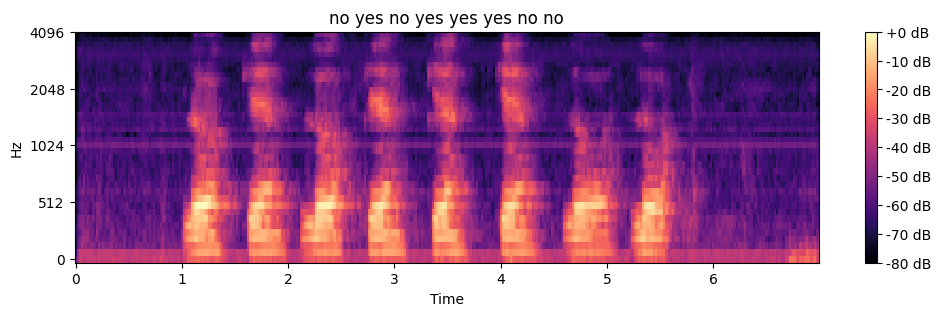

In [19]:
# YESNOデータセットをダウンロードして展開する
import os, glob, tarfile, urllib.request

url = "https://www.openslr.org/resources/1/waves_yesno.tar.gz"
if not os.path.exists("waves_yesno"):
    urllib.request.urlretrieve(url, "waves_yesno.tar.gz")
    with tarfile.open("waves_yesno.tar.gz") as tar:
        tar.extractall(".")

wav_files = sorted(glob.glob("waves_yesno/*.wav"))
print("ファイル数:", len(wav_files))
print("例:", wav_files[:3])

# メルスペクトログラムと正解文字列を作り、学習用とテスト用に分ける
import librosa
import librosa.display
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

chars = ["-", " ", "e", "n", "o", "s", "y"]       # 0番がblank
char2id = {c: i for i, c in enumerate(chars)}

def load_example(path):
    wav, sr = librosa.load(path, sr=8000)
    mel = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=400, hop_length=160, n_mels=40)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # ファイル名 0_1_1_... を "no yes yes ..." に変換する
    bits = os.path.basename(path).replace(".wav", "").split("_")
    text = " ".join("yes" if b == "1" else "no" for b in bits)
    return mel_db.T.astype(np.float32), text      # [時刻, 周波数]

examples = [load_example(p) for p in wav_files]
perm = np.random.permutation(len(examples))
train_set = [examples[i] for i in perm[:48]]
test_set = [examples[i] for i in perm[48:]]

# 学習データの平均と標準偏差で正規化する
mean = np.concatenate([x for x, _ in train_set]).mean()
std = np.concatenate([x for x, _ in train_set]).std()

x0, text0 = test_set[0]
print("特徴量の形状 [時刻, 周波数]:", x0.shape, " 正解:", text0, f"（{len(text0)}文字）")
plt.figure(figsize=(12, 3))
librosa.display.specshow(x0.T, sr=8000, hop_length=160, x_axis="time", y_axis="mel")
plt.title(text0)
plt.colorbar(format="%+2.0f dB")
plt.show()

約300フレームの入力から、30文字前後の文字列を出力する問題であることがわかる
- メルスペクトログラムには8個のかたまりが見えるが、どれが「yes」でどれが「no」かは、学習するまでモデルにはわからない

### モデル

モデルは、フレームごとに7種類の記号の確率を出力すればよい
- まず、時間方向の1次元畳み込み（`Conv1d`）を3層重ね、数フレームにまたがる局所的な音のパターンを取り出す
  - 分類ではメルスペクトログラムを画像として2次元畳み込みに通したが、ここでは40本のメル周波数をチャネルとみなし、時間方向にだけ畳み込む
  - 2層目のストライドを2にして、フレーム数を半分（1秒あたり25フレーム）に間引く
- 次に、双方向GRU（RNNの章を参照）で前後の文脈を取り込む
  - 「yes」の「y」を出すべきフレームかどうかは、その後に続く音を見ないと決めにくい
- 最後に全結合層で記号数の次元に変換し、`log_softmax` で対数確率にする

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-ctc-model.png" width=750>

上の図が全体の構成である
- モデルが出力するのはフレームごとの記号の対数確率までで、学習時はそれをCTC損失に、認識時は復号に渡す
- 正解の文字列が使われるのは、CTC損失の計算だけである

CTCには制約が1つある
- 出力フレーム数 $T$ は、正解の文字数 $U$ 以上でなければならない（同じ文字が続く場合は、間のblankの分だけさらに必要）
- 今回は間引いた後でも $T \approx 150$、$U \approx 30$ なので問題ない
- 実用のモデルでも、計算量を減らすために畳み込みで時間方向を間引くが、この制約を破らない範囲で行う

長さの違う系列をまとめてバッチにするため、短いものは0で埋め（パディング）、本来の長さを別に渡す
- `nn.CTCLoss` は `input_lengths` と `target_lengths` を受け取り、埋めた部分を損失の計算から除外する
- `input_lengths` には、間引いた後のフレーム数を渡す必要がある（`out_len` で計算する）

### 貪欲復号

学習したモデルから文字列を取り出す操作を**復号**（decoding）と呼ぶ

最も簡単な方法は**貪欲復号**（greedy decoding）である
1. フレームごとに、確率が最大の記号を選ぶ
2. 得られた記号列に折り畳み規則を適用する

折り畳みには、先に定義した `collapse` がそのまま使える

貪欲復号は「最も確率の高い1本のアライメント」を選んでいるだけで、「最も確率の高い出力列」を選んでいるとは限らない
- 出力列の確率は多数のアライメントの和だからである
- 複数の候補を残しながら探索するビームサーチや、言語モデルと組み合わせる方法で改善できるが、ここでは扱わない

In [20]:
# 1次元畳み込みと双方向GRUによるフレーム単位の記号予測モデルと、バッチ化の関数を定義する
import torch.nn as nn

class CTCModel(nn.Module):
    def __init__(self, n_mels=40, hidden=64, n_symbols=len(chars)):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_mels, hidden, 5, padding=2), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 5, stride=2, padding=2), nn.BatchNorm1d(hidden), nn.ReLU(),  # ここで1/2に間引く
            nn.Conv1d(hidden, hidden, 5, padding=2), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Dropout(0.2))
        self.rnn = nn.GRU(hidden, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2, n_symbols)

    def forward(self, x):                               # x: [バッチ, 時刻, 周波数]
        h = self.conv(x.transpose(1, 2)).transpose(1, 2)  # Conv1dは[バッチ, チャネル, 時刻]を受け取る
        h, _ = self.rnn(h)
        return self.fc(h).log_softmax(-1)               # [バッチ, 時刻/2, 記号数]

    @staticmethod
    def out_len(n):
        # 間引いた後のフレーム数（カーネル5、パディング2、ストライド2の畳み込みの出力長）
        return (n + 1) // 2

def make_batch(batch):
    # 長さの違う系列を0で埋めてまとめ、本来の長さも返す
    xs = [torch.tensor((x - mean) / std) for x, _ in batch]
    ys = [torch.tensor([char2id[c] for c in text]) for _, text in batch]
    x_len = torch.tensor([len(x) for x in xs])
    y_len = torch.tensor([len(y) for y in ys])
    x_pad = nn.utils.rnn.pad_sequence(xs, batch_first=True)
    y_pad = nn.utils.rnn.pad_sequence(ys, batch_first=True)
    return x_pad, x_len, y_pad, y_len, [text for _, text in batch]

model = CTCModel().to(device)
print("パラメータ数:", sum(p.numel() for p in model.parameters()))

# 貪欲復号: フレームごとの最大確率の記号を選び、折り畳んで文字列にする
def greedy_decode(log_probs, length):
    path = log_probs[:length].argmax(-1).tolist()
    return "".join(chars[k] for k in collapse(path)).strip()   # 前後の余分なスペースは除く

@torch.no_grad()
def recognize(model, dataset):
    # データセット全体を認識し、(正解, 認識結果)の組を返す
    model.eval()
    x_pad, x_len, _, _, texts = make_batch(dataset)
    log_probs = model(x_pad.to(device)).cpu()
    return [(ref, greedy_decode(lp, n)) for ref, lp, n in zip(texts, log_probs, model.out_len(x_len))]

# 学習前のモデルの出力（正解とは無関係な文字列になる）
for ref, hyp in recognize(model, test_set)[:2]:
    print("正解:", ref)
    print("認識:", repr(hyp[:60]), "\n")

パラメータ数: 105159
正解: no yes no yes yes yes no no
認識: 'e' 

正解: yes no yes no yes no no yes
認識: 'e' 



## 評価指標: 単語誤り率（WER）と文字誤り率（CER）

分類では正解率で評価できたが、認識結果は文字列なので「完全に一致したかどうか」だけでは粗すぎる
- 8単語のうち1単語だけ間違えた結果と、全部間違えた結果を区別したい

そこで、正解を認識結果に書き換えるのに必要な最小の編集回数、すなわち**編集距離**（レーベンシュタイン距離）を使う
- 編集は3種類: **置換**（substitution、$S$）、**削除**（deletion、$D$）、**挿入**（insertion、$I$）
- 正解の長さを $N$ として、誤り率を次のように定義する

$$ \text{誤り率} = \frac{S + D + I}{N} $$

- 単語を単位として数えたものが**単語誤り率**（Word Error Rate、WER）、文字を単位として数えたものが**文字誤り率**（Character Error Rate、CER）である
- 挿入が多いと分子が $N$ を超えるので、誤り率は100%を超えることがある

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-edit-distance-wer.png" width=600>

上の図は、次のセルで動作確認に使う例を、単語単位で対応づけたものである
- 一致しない箇所を、置換、削除、挿入のいずれかとして数える（この例に削除は無い）

編集距離も動的計画法で求められる
- $d(i, j)$ を「正解の先頭 $i$ 個と認識結果の先頭 $j$ 個の間の編集距離」とすると、$d(i, j)$ は $d(i-1, j)$（削除）、$d(i, j-1)$（挿入）、$d(i-1, j-1)$（一致または置換）から決まる
- CTCの前向きアルゴリズムと同じく、表を左上から順に埋めていく

「N-アプリ-transformer」の章では、ライブラリ `jiwer` でWERを計算しているが、ここではその中身を自作する

In [21]:
# 編集距離からWERとCERを計算する
def edit_distance(ref, hyp):
    # ref, hyp は単語のリストでも文字列でもよい
    d = list(range(len(hyp) + 1))            # 表の1行分だけを持つ
    for i in range(1, len(ref) + 1):
        prev, d[0] = d[0], i
        for j in range(1, len(hyp) + 1):
            cur = min(d[j] + 1,                               # 削除
                      d[j - 1] + 1,                           # 挿入
                      prev + (ref[i - 1] != hyp[j - 1]))      # 一致または置換
            prev, d[j] = d[j], cur
    return d[-1]

def error_rates(pairs):
    # (正解, 認識結果)の組のリストから、全体のWERとCERを求める
    w_err = sum(edit_distance(r.split(), h.split()) for r, h in pairs)
    w_len = sum(len(r.split()) for r, _ in pairs)
    c_err = sum(edit_distance(r, h) for r, h in pairs)
    c_len = sum(len(r) for r, _ in pairs)
    return w_err / w_len, c_err / c_len

# 動作確認
assert edit_distance("kitten", "sitting") == 3
assert edit_distance("abc", "") == 3 and edit_distance("", "ab") == 2
ref, hyp = "no yes yes no", "no yes yas no no"
print("単語の編集距離:", edit_distance(ref.split(), hyp.split()), " 文字の編集距離:", edit_distance(ref, hyp))
print("WER = {:.3f}, CER = {:.3f}".format(*error_rates([(ref, hyp)])))

# 日本語では単語の区切り方によってWERが変わるが、CERは変わらない
ref = "今日は良い天気です"
hyp = "今日は酔い天気です"
print("CER:", f"{edit_distance(ref, hyp) / len(ref):.3f}")

# 2通りの区切り方（どちらも不自然ではない）
seg_a = (["今日", "は", "良い", "天気", "です"], ["今日", "は", "酔い", "天気", "です"])
seg_b = (["今日は", "良い天気", "です"], ["今日は", "酔い天気", "です"])
for name, (r, h) in [("細かい区切り", seg_a), ("粗い区切り", seg_b)]:
    print(f"WER（{name}）: {edit_distance(r, h) / len(r):.3f}")

単語の編集距離: 2  文字の編集距離: 4
WER = 0.500, CER = 0.308
CER: 0.111
WER（細かい区切り）: 0.200
WER（粗い区切り）: 0.333


前半の例では、単語としては1個の置換（yes → yas）と1個の挿入（no）で $2/4 = 0.5$、文字としては1文字の置換と3文字（スペースと`no`）の挿入で $4/13 \approx 0.31$ となる
- 1文字の間違いでも単語全体が誤りになるので、一般にWERはCERより大きくなる
- 複数の発話をまとめて評価するときは、発話ごとの誤り率を平均するのではなく、編集回数の合計を正解の長さの合計で割る
  - 短い発話の誤りが過大に効くのを避けるためである
- ここではスペースも1文字として数えているが、スペースを除いて数える流儀もあるので、他の文献の値と比べるときは定義を確認する必要がある

### 日本語ではCERを使う理由

WERを計算するには、文を単語に区切る必要がある
- 英語はスペースで区切られているので、区切り方に迷いがない
- 日本語は単語の間にスペースを書かない
  - 単語に区切るには形態素解析が必要で、その結果は使う解析器や辞書によって変わる
  - 「単語」の定義が決まらないので、WERの値が区切り方に依存してしまう

セルの後半では、同じ認識結果でも区切り方によってWERが変わることを確かめた

誤りは「良」が「酔」になった1文字だけであるが、WERは区切り方によって0.2にも0.33にもなる
- CERは区切り方によらず $1/9$ である

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-cer-japanese.png" width=700>

上の図は、この例を3通りの単位で区切ったものである
- 赤い箱が誤りを含む単位で、誤りは同じ1文字でも、分母（単位の数）が区切り方によって変わる

- このため、日本語や中国語のように単語の間を空けない言語では、CERで評価するのが標準的である
- ただしCERにも弱点があり、「良い」と「よい」のような表記の揺れが誤りとして数えられる
  - 評価の前に表記を正規化する処理が必要になる（N章のWhisperの実習でも、英語の正規化を行ってからWERを計算している）

## 学習

準備が整ったので、`nn.CTCLoss` で学習する
- `nn.CTCLoss` に渡す対数確率の形状は `[時刻, バッチ, 記号数]` であり、モデルの出力 `[バッチ, 時刻, 記号数]` を転置して渡す
- `zero_infinity=True` は、入力が短すぎて正解を出力できない場合に損失が無限大になるのを防ぐ指定である
- 1エポックごとに、テストデータのWERとCERを記録する

データもモデルも小さいので、GPUなら数十秒で終わる（CPUでも動作する）

学習前      test WER 1.000  CER 0.963
epoch   1  loss 3.909  test WER 1.000  CER 1.000
epoch   2  loss 1.957  test WER 1.000  CER 1.000
epoch   3  loss 1.690  test WER 1.000  CER 1.000
epoch   4  loss 1.496  test WER 1.000  CER 1.000
epoch   5  loss 1.281  test WER 1.000  CER 0.704
epoch   6  loss 1.039  test WER 1.000  CER 0.556
epoch   7  loss 0.812  test WER 1.000  CER 0.556
epoch   8  loss 0.622  test WER 0.865  CER 0.367
epoch   9  loss 0.460  test WER 0.688  CER 0.133
epoch  10  loss 0.283  test WER 0.010  CER 0.009
epoch  15  loss 0.041  test WER 0.010  CER 0.009
epoch  20  loss 0.015  test WER 0.010  CER 0.009
epoch  25  loss 0.010  test WER 0.010  CER 0.009
epoch  30  loss 0.006  test WER 0.010  CER 0.009


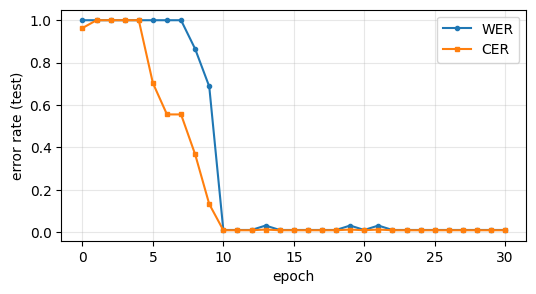

正解: no yes no yes yes yes no no
認識: no yes no yes yes yes no no 

正解: yes no yes no yes no no yes
認識: yes no yes no yes no no yes 

正解: no yes no yes no no no no
認識: no yes no yes no no no 

正解: no yes no no yes no yes no
認識: no yes no no yes no yes no 



In [22]:
# CTC損失で学習し、テストデータの誤り率の推移を記録する
from torch.utils.data import DataLoader

n_epochs = 30
train_loader = DataLoader(train_set, batch_size=8, shuffle=True, collate_fn=make_batch)
ctc_loss = nn.CTCLoss(blank=BLANK, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

wer0, cer0 = error_rates(recognize(model, test_set))
print(f"学習前      test WER {wer0:.3f}  CER {cer0:.3f}")
history = [(0, float("nan"), wer0, cer0)]

for epoch in range(1, n_epochs + 1):
    model.train()
    loss_sum = 0.0
    for x_pad, x_len, y_pad, y_len, _ in train_loader:
        log_probs = model(x_pad.to(device))                 # [バッチ, 時刻, 記号数]
        loss = ctc_loss(log_probs.transpose(0, 1), y_pad, model.out_len(x_len), y_len)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)   # RNNの勾配爆発を防ぐ
        optimizer.step()
        loss_sum += loss.item()
    wer, cer = error_rates(recognize(model, test_set))
    history.append((epoch, loss_sum / len(train_loader), wer, cer))
    if epoch <= 10 or epoch % 5 == 0:
        print(f"epoch {epoch:3d}  loss {history[-1][1]:.3f}  test WER {wer:.3f}  CER {cer:.3f}")

# 誤り率の推移と、テストデータの認識結果を表示する
ep, _, wers, cers = zip(*history)
plt.figure(figsize=(6, 3))
plt.plot(ep, wers, marker="o", markersize=3, label="WER")
plt.plot(ep, cers, marker="s", markersize=3, label="CER")
plt.xlabel("epoch")
plt.ylabel("error rate (test)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for ref, hyp in recognize(model, test_set)[:4]:
    print("正解:", ref)
    print("認識:", hyp, "\n")

### 結果の読み方

- 学習前の誤り率は1前後である
  - 重みが乱数のままなので、正解とは無関係な記号が出るか、ほとんど何も出ない
- 学習の初期には、損失は下がるのに誤り率が1から動かない期間がある
  - この間、モデルはすべてのフレームでblankを出力しており、認識結果は空文字列になっている（全文字が削除誤りになるので誤り率はちょうど1）
  - blankだけを出しても損失はある程度下がるので、CTCの学習はまずこの状態を通ることが多い
- その後、文字を出すフレームを見つけ始めると、数エポックのうちに誤り率が0の近くまで急に下がる
  - CERが先に下がり、WERが遅れて下がる点にも注目するとよい（文字が半分合っていても、単語としてはまだ全部誤りである）
- 誤りが残る場合は、認識結果のどこが違うかを見るとよい
  - 例えば「no no」のスペースが抜けて「nono」になると、文字としては1文字の削除であるが、単語としては1個の置換と1個の削除になる

フレームごとの対応を一切教えていないにもかかわらず、音声と文字列の組だけから認識ができるようになった点が重要である
- ただし、話者が1人で語彙が2単語という極めて易しい条件であることを忘れてはならない

次に、モデルがどのフレームでどの記号を出しているかを可視化する

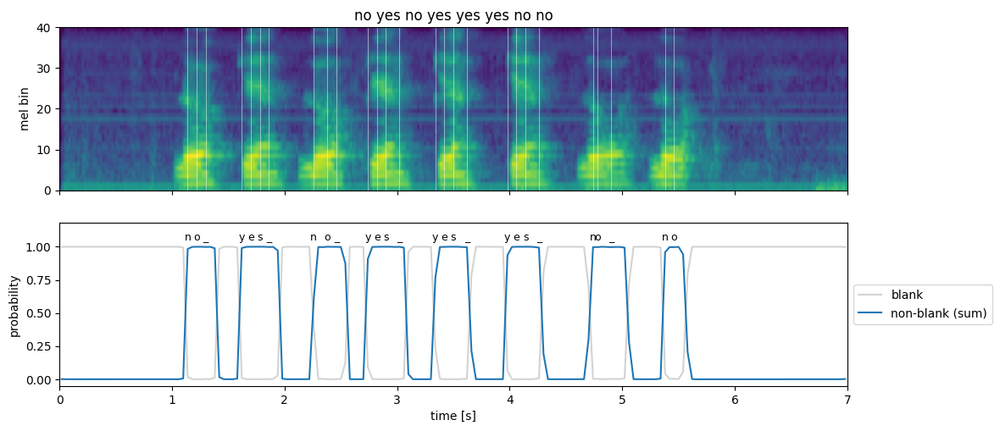

フレームごとの最大確率の記号（スペースは _ と表示）:
----------------------------nnoo___-----yyeess___-------nnnoo___----yyeesss__------yyeesss_--------yyeesss_-----------nooo____--------nnooo------------------------------------
blankのフレームの割合 0.65  文字1個が続くフレーム数の平均 2.30


In [23]:
# フレームごとの記号の確率と、モデルが選んだアライメントを図にする
def plot_alignment(spec, post, labels, frame_sec, title, blank=BLANK):
    # spec: [周波数, 時刻] のメルスペクトログラム、post: [時刻, 記号数] の確率、labels: 記号の表示名
    path = post.argmax(-1)
    t_axis = (np.arange(len(post)) + 0.5) * frame_sec     # 各フレームの中心の時刻
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
    axes[0].imshow(spec, origin="lower", aspect="auto", extent=[0, len(post) * frame_sec, 0, spec.shape[0]])
    axes[0].set_ylabel("mel bin")
    axes[0].set_title(title)
    axes[1].plot(t_axis, post[:, blank], color="lightgray", label="blank")
    axes[1].plot(t_axis, 1 - post[:, blank], color="tab:blue", label="non-blank (sum)")
    # 新しい文字が出力されたフレームに、縦線とその文字を書き込む
    prev = blank
    for i, k in enumerate(path):
        if k != blank and k != prev:
            axes[0].axvline(t_axis[i], color="white", linewidth=0.5, alpha=0.7)
            axes[1].text(t_axis[i], 1.05, labels[k], ha="center", fontsize=9)
        prev = k
    axes[1].set_ylim(-0.05, 1.18)
    axes[1].set_xlabel("time [s]")
    axes[1].set_ylabel("probability")
    axes[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    plt.show()

def alignment_stats(path, blank=BLANK):
    # blankのフレームの割合と、文字1個が続くフレーム数の平均
    path = list(path)
    runs = [len(list(g)) for k, g in itertools.groupby(path) if k != blank]
    return path.count(blank) / len(path), float(np.mean(runs)) if runs else 0.0

# テストデータ1件を、学習したモデルに通す
model.eval()
x0, text0 = test_set[0]
with torch.no_grad():
    post = model(torch.tensor((x0 - mean) / std).unsqueeze(0).to(device))[0].exp().cpu().numpy()

yesno_labels = ["-", "_", "e", "n", "o", "s", "y"]        # スペースは "_" と表示する
plot_alignment(x0.T, post, yesno_labels, 320 / 8000, text0)   # 間引き後の1フレームは40ミリ秒

print("フレームごとの最大確率の記号（スペースは _ と表示）:")
print("".join(yesno_labels[k] for k in post.argmax(-1)))
blank_ratio, mean_run = alignment_stats(post.argmax(-1))
print(f"blankのフレームの割合 {blank_ratio:.2f}  文字1個が続くフレーム数の平均 {mean_run:.2f}")

### 結果の読み方

上段がメルスペクトログラム、下段がフレームごとの確率である
- 灰色の線がblankの確率、青い線がblank以外の記号の確率の合計である
- 新しい文字が出力されたフレームに、上段では白い縦線を、下段ではその文字（スペースは `_`）を書き込んである

最後に表示した記号列が、モデルが選んだアライメントであり、これを折り畳むと認識結果になる

図から次のことが読み取れる
- 発声の前後と単語の間の無音区間では、blankの確率がほぼ1である
- 文字は、メルスペクトログラムで音が鳴っている8個のかたまりの位置に、単語ごとにまとまって現れる
  - モデルは、どのかたまりが「yes」でどのかたまりが「no」かを、音から判断できている
- 1つの単語の中では、文字とスペースが1〜3フレーム（40〜120ミリ秒）ずつ続けて出力され、単語の中にblankは入らない
- 確率は0か1に近い値ばかりで、中間の値をとるフレームは文字の切り替わりだけである
  - モデルに迷いがないことを示している

注意すべき点が2つある
- どのフレームでどの文字を出すかは、誰も教えていない
  - 損失はアライメントの和だけを見ているので、正解に折り畳まれさえすれば「いつ出すか」は制約されず、モデルが自分で決めている
- したがって、文字が出ている時刻を、その文字に対応する音の正確な開始時刻・終了時刻とみなすことはできない
  - 実際、「yes」の3文字とスペースは、発声区間の中に順に並んでいるだけで、「y」の音、「e」の音、「s」の音の境界を表しているわけではない
  - ただし、単語がどのあたりで発声されたかという粗い位置は読み取れる

なお、正解の文字列を与えたうえで最も確率の高いアライメントを1本求める処理を**強制アライメント**（forced alignment）と呼ぶ
- 前向きアルゴリズムの和を最大値に置き換え、経路をたどり直せば求められる（ビタビアルゴリズム）
- 字幕の時刻付けや、音声コーパスの作成に使われる

## 失敗例: 畳み込みを省くとどうなるか

上のモデルは、最初からこの構成だったわけではない

教材を作る際に最初に試したのは、メルスペクトログラムをそのまま双方向GRU 2層に入れる、より単純なモデルであった
- 「系列データにはRNN」という発想からすれば自然な構成である
- しかし、このデータではうまく学習できなかった

うまくいかなかった構成を知ることは、うまくいった構成を知ることと同じくらい役に立つので、ここで再現する
- 学習の手順、損失、データは同じで、モデルだけを差し替える
- 収束が遅いので100エポック学習する（データが小さいので、それでもGPUなら1分以内に終わる）

epoch  20  loss 1.680  test WER 0.917  CER 0.830
epoch  40  loss 0.937  test WER 0.625  CER 0.426
epoch  60  loss 0.673  test WER 0.490  CER 0.346
epoch  80  loss 0.659  test WER 0.510  CER 0.380
epoch 100  loss 0.438  test WER 0.385  CER 0.309
GRU only    train WER 0.271 CER 0.198   test WER 0.385 CER 0.309
Conv + GRU  train WER 0.000 CER 0.000   test WER 0.010 CER 0.009


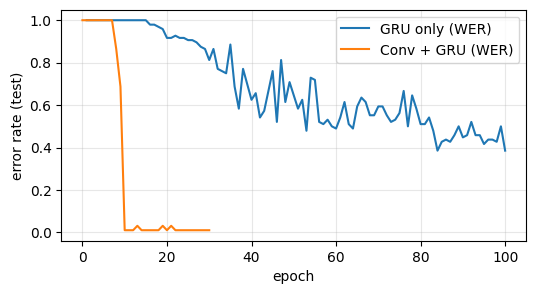

正解      : no yes no yes yes yes no no
GRU only  : nno noo yes yes yoo noo yes ye                                                                                                                                                                                                                                                                                                                             noo
Conv + GRU: ----------------------------nnoo   -----yyeess   -------nnnoo   ----yyeesss  ------yyeesss --------yyeesss -----------nooo    --------nnooo------------------------------------


In [24]:
# 失敗例: 畳み込みを使わず、メルスペクトログラムを双方向GRU 2層に直接入れるモデル
class GRUOnlyModel(nn.Module):
    def __init__(self, n_mels=40, hidden=64, n_symbols=len(chars)):
        super().__init__()
        self.rnn = nn.GRU(n_mels, hidden, num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2, n_symbols)

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.fc(h).log_softmax(-1)

    @staticmethod
    def out_len(n):
        return n          # 間引かないので、フレーム数は入力と同じ

torch.manual_seed(0)
gru_model = GRUOnlyModel().to(device)
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=2e-3)
gru_history = []
for epoch in range(1, 101):
    gru_model.train()
    for x_pad, x_len, y_pad, y_len, _ in train_loader:
        loss = ctc_loss(gru_model(x_pad.to(device)).transpose(0, 1), y_pad, x_len, y_len)
        gru_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(gru_model.parameters(), 5.0)
        gru_optimizer.step()
    gru_history.append((epoch,) + error_rates(recognize(gru_model, test_set)))
    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.3f}  test WER {gru_history[-1][1]:.3f}  CER {gru_history[-1][2]:.3f}")

# 2つのモデルを、学習データとテストデータの両方で比べる
for name, m in [("GRU only  ", gru_model), ("Conv + GRU", model)]:
    tr_wer, tr_cer = error_rates(recognize(m, train_set))
    te_wer, te_cer = error_rates(recognize(m, test_set))
    print(f"{name}  train WER {tr_wer:.3f} CER {tr_cer:.3f}   test WER {te_wer:.3f} CER {te_cer:.3f}")

plt.figure(figsize=(6, 3))
plt.plot([h[0] for h in gru_history], [h[1] for h in gru_history], label="GRU only (WER)")
plt.plot(ep, wers, label="Conv + GRU (WER)")
plt.xlabel("epoch")
plt.ylabel("error rate (test)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 同じテスト発話に対するアライメント（フレームごとの最大確率の記号）を比べる
with torch.no_grad():
    gru_post = gru_model.eval()(torch.tensor((x0 - mean) / std).unsqueeze(0).to(device))[0].exp().cpu().numpy()
print("正解      :", text0)
print("GRU only  :", "".join(chars[k] for k in gru_post.argmax(-1)))
print("Conv + GRU:", "".join(chars[k] for k in post.argmax(-1)))

### 結果の読み方

- GRUだけのモデルは、100エポック学習してもテストデータのWERが0.4前後で止まる
  - 畳み込みを前段に置いたモデルは、10エポック程度でほぼ0になっていた
- 学習データに対する誤り率も0にはなっておらず、しかもテストデータではそれよりずっと悪い
  - 学習データすら覚えきれず、覚えた分も未知のデータには通用していない

原因の手がかりは、最後に表示したアライメントにある
- 畳み込みを置いたモデルは、音が鳴っている位置に、その単語の文字を出している
- GRUだけのモデルは、発話の先頭付近にまとめて文字を並べており、文字の位置が音の位置と対応していない
  - 「yes」と「no」が並ぶ、という文字列の形は覚えたが、どの位置でどちらが発声されたかを音から読み取れていない

このことから、次のように考えられる
- 1フレーム（20ミリ秒）のメルスペクトルだけでは、それが「yes」の一部か「no」の一部かを判別しにくい
  - 判別の手がかりは、数フレームにまたがる時間的な変化のパターンにある
- GRUは原理的にはそのパターンを取り出せるはずであるが、48件のデータでは、そこに到達する前に、双方向の隠れ状態に発話全体の情報を溜め込んで文字列を出力する、という別の解に落ちてしまう
- 時間方向の畳み込みは「近くの数フレームをまとめて見る」という構造を最初から持っているので、局所的な音のパターンを少ないデータで学習できる
  - 画像で、畳み込みが「近くの画素をまとめて見る」構造によって少ないデータで学習できるのと同じ理由である（CNNの章を参照）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-conv-local-context.png" width=700>

上の図の左が畳み込みを置いた構成、右が失敗した構成である
- 左では、数フレーム分の音の変化が1つの特徴にまとめられてからGRUに届く
- 右では、GRUが1フレームずつ受け取り、パターンの抽出まで自分で学ばなければならない

実用の音声認識モデルも、ほぼ例外なく、最初の数層は畳み込みである
- Whisperはメルスペクトログラムに2層の1次元畳み込みをかけてからTransformerに入れる
- wav2vec 2.0は波形に7層の1次元畳み込みをかけてからTransformerに入れる

教訓は、**誤り率の数値だけでなく、モデルが何を出力しているかを見る**ことである
- 「WERが0.4で止まった」だけでは、学習率が悪いのか、モデルが小さいのか、データが足りないのかわからない
- アライメントを表示して「音の位置を見ていない」とわかったことで、局所的な特徴抽出を足すという対策にたどり着ける

## CTCの復号: 貪欲復号の限界と接頭辞ビームサーチ

### 貪欲復号はなぜ最良とは限らないか

復号で本当に求めたいのは、確率が最大の**出力列**である

$$ \hat{\mathbf{y}} = \arg\max_{\mathbf{y}} P(\mathbf{y} \mid \mathbf{x}) = \arg\max_{\mathbf{y}} \sum_{\pi \in \mathcal{B}^{-1}(\mathbf{y})} \prod_{t} p_t(\pi_t) $$

貪欲復号が求めているのは、確率が最大の**アライメント**を折り畳んだものである

$$ \mathcal{B}\Bigl( \arg\max_{\pi} \prod_{t} p_t(\pi_t) \Bigr) $$

この2つは一致するとは限らない
- 1本のアライメントとしては確率が最大でなくても、同じ出力列に折り畳まれるアライメントが多数あれば、合計では上回ることがある

2フレームだけの最小の例で確かめる

In [25]:
# 貪欲復号が最良の出力列を選ばない例（2フレーム、記号はblankとaの2種類）
toy = np.array([[0.6, 0.4],
                [0.6, 0.4]])
toy_table = {}
for path in itertools.product(range(2), repeat=2):
    key = "".join("-a"[k] for k in collapse(path))
    toy_table[key] = toy_table.get(key, 0.0) + np.prod([toy[t, k] for t, k in enumerate(path)])
    print("-a"[path[0]], "-a"[path[1]], " ->", repr(key), f" p = {np.prod([toy[t, k] for t, k in enumerate(path)]):.2f}")
print("出力列の確率:", {k or "<empty>": round(float(v), 2) for k, v in toy_table.items()})
print("貪欲復号の出力:", repr("".join("-a"[k] for k in collapse(toy.argmax(-1).tolist()))))

- -  -> ''  p = 0.36
- a  -> 'a'  p = 0.24
a -  -> 'a'  p = 0.24
a a  -> 'a'  p = 0.16
出力列の確率: {'<empty>': 0.36, 'a': 0.64}
貪欲復号の出力: ''


- 最も確率の高いアライメントは `- -`（0.36）なので、貪欲復号は空文字列を出力する
- しかし出力列として見ると、「a」は3本のアライメントの合計で0.64あり、空文字列の0.36より高い

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-greedy-vs-best-output.png" width=620>

上の図は、この例の4本のアライメントと、それぞれが折り畳まれる出力列を示している
- 黄色の枠が貪欲復号の選ぶアライメント、橙色の箱が確率最大の出力列である

モデルの出力が確信に満ちている（各フレームで1つの記号の確率がほぼ1）ときは、両者は一致する

差が出るのは、モデルが迷っているフレームがあるときである

### 接頭辞ビームサーチ

確率が最大の出力列を厳密に求めるのは難しいので、**ビームサーチ**（beam search）で近似する
- フレームを1つずつ進めながら、有望な候補を上位 $B$ 個（**ビーム幅**）だけ残す

ただし、アライメントを候補にして上位 $B$ 本を残すだけでは、貪欲復号と同じ問題が残る
- 同じ出力列になるアライメントが別々の候補として数えられ、合計されないからである

そこで、候補を「アライメント」ではなく「そこまでに確定した出力列（**接頭辞**、prefix）」にする
- 同じ接頭辞に折り畳まれるアライメントの確率は、その場で足し合わせる
- これを**接頭辞ビームサーチ**（prefix beam search）と呼ぶ

実装で注意が要るのは、折り畳み規則の「連続する同じ記号をまとめる」である
- 接頭辞が「a」のとき、次のフレームで `a` を出した結果が「a」のままか「aa」になるかは、直前のフレームがblankだったかどうかで決まる
- そこで、各接頭辞について確率を2つに分けて持つ
  - $p_b$: blankで終わるアライメントの確率の和
  - $p_{nb}$: 文字（blank以外）で終わるアライメントの確率の和

1フレーム進むときの更新は、次の3通りである

|このフレームで出す記号|新しい接頭辞|更新|
|-|-|-|
|blank|変わらない|$p_b \leftarrow (p_b + p_{nb}) \cdot p_t(-)$|
|接頭辞の最後と同じ文字 $c$|変わらない|$p_{nb} \leftarrow p_{nb} \cdot p_t(c)$|
|接頭辞の最後と同じ文字 $c$|1文字伸びる|$p_{nb} \leftarrow p_b \cdot p_t(c)$（blankを挟んだ場合だけ）|
|それ以外の文字 $c$|1文字伸びる|$p_{nb} \leftarrow (p_b + p_{nb}) \cdot p_t(c)$|

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-prefix-beam-step.png" width=700>

上の図は、接頭辞が「a」のときの4通りの更新を描いたものである（表の4行に対応する）
- 上の2つは接頭辞が変わらず、下の2つは接頭辞が1文字伸びる
- 別の接頭辞から伸びてきた候補と同じ接頭辞になった場合は、確率を足し合わせる

- 前向きアルゴリズムと同じ考え方であるが、正解列が与えられていないので、あり得る出力列を枝分かれさせながら進む点が異なる
- 長い音声では確率の積が非常に小さくなるので、実装では対数で計算する（和は `np.logaddexp` を使う）
- 引数 `lm`、`alpha`、`beta` は、後で言語モデルを組み合わせるときに使う

In [26]:
# 接頭辞ビームサーチ: 同じ出力列になるアライメントの確率をまとめながら、上位の候補だけを残して探索する
def prefix_beam_search(log_probs, beam_size=8, blank=BLANK, lm=None, alpha=0.0, beta=0.0, prune=1e-4):
    # log_probs: [時刻, 記号数] の対数確率（numpy配列）
    # lm: 接頭辞（記号番号のタプル）を受け取り、言語モデルの対数確率を返す関数（省略可）
    # 戻り値: (接頭辞, CTCの対数確率) を、スコアの高い順に並べたリスト
    NEG = -np.inf
    log_prune = np.log(prune)
    # 各接頭辞について、(blankで終わるアライメントの対数確率, 文字で終わるアライメントの対数確率) を持つ
    beams = {(): (0.0, NEG)}

    def score(item):
        prefix, (pb, pnb) = item
        s = np.logaddexp(pb, pnb)
        if lm is not None:
            s += alpha * lm(prefix) + beta * len(prefix)
        return s

    for lp in log_probs:
        new_beams = {}

        def add(prefix, pb, pnb):
            if pb == NEG and pnb == NEG:
                return                      # 確率0の候補は登録しない
            old_pb, old_pnb = new_beams.get(prefix, (NEG, NEG))
            new_beams[prefix] = (np.logaddexp(old_pb, pb), np.logaddexp(old_pnb, pnb))

        for prefix, (pb, pnb) in beams.items():
            p_total = np.logaddexp(pb, pnb)
            # (1) blankを出す: 接頭辞は変わらない
            add(prefix, p_total + lp[blank], NEG)
            # (2) 最後の文字をもう一度出す: 折り畳まれるので接頭辞は変わらない
            if prefix:
                add(prefix, NEG, pnb + lp[prefix[-1]])
            # (3) 文字を出して接頭辞を1文字伸ばす
            for k in np.nonzero(lp > log_prune)[0]:
                if k == blank:
                    continue
                if prefix and k == prefix[-1]:
                    add(prefix + (k,), NEG, pb + lp[k])       # 同じ文字で伸ばせるのは、blankを挟んだ場合だけ
                else:
                    add(prefix + (k,), NEG, p_total + lp[k])
        # スコアの高い beam_size 個だけを残す
        beams = dict(sorted(new_beams.items(), key=score, reverse=True)[:beam_size])

    ranked = sorted(beams.items(), key=score, reverse=True)
    return [(prefix, float(np.logaddexp(pb, pnb))) for prefix, (pb, pnb) in ranked]

# 確認1: 2フレームの例で、貪欲復号が選べなかった "a" が1位になる
for prefix, logp in prefix_beam_search(np.log(toy), beam_size=4):
    print(repr("".join("-a"[k] for k in prefix)), f"{np.exp(logp):.2f}")

# 確認2: ビーム幅を十分大きくすると枝刈りが起きないので、4フレームの例の全列挙（table）と一致する
result = prefix_beam_search(np.log(probs), beam_size=1000, prune=0.0)
for prefix, logp in result[:5]:
    key = "".join(symbols[k] for k in prefix)
    print(f"  {key or '<empty>':8s} beam {np.exp(logp):.4f}   enumeration {table[key]:.4f}")
assert all(abs(np.exp(logp) - table["".join(symbols[k] for k in prefix)]) < 1e-9 for prefix, logp in result)
assert len(result) == len(table)

'a' 0.64
'' 0.36
  ab       beam 0.4713   enumeration 0.4713
  a        beam 0.1971   enumeration 0.1971
  b        beam 0.1134   enumeration 0.1134
  bab      beam 0.0527   enumeration 0.0527
  ba       beam 0.0419   enumeration 0.0419


/tmp/ipykernel_591/3705000060.py:7: RuntimeWarning: divide by zero encountered in log
  log_prune = np.log(prune)


- 2フレームの例では、貪欲復号が選べなかった「a」が1位になる
- ビーム幅を十分大きくして枝刈りが起きないようにすると、接頭辞ビームサーチは全アライメントの列挙と同じ確率を、すべての出力列について与える
  - 実装が周辺化を正しく行っていることの確認になっている
- 実際の音声では、ビーム幅を8〜100程度にして、確率の低い候補を捨てながら進む

次に、YESNOで学習した2つのモデルに適用する

In [27]:
# YESNOのテストデータで、貪欲復号と接頭辞ビームサーチを比べる
@torch.no_grad()
def recognize_beam(model, dataset, **kwargs):
    model.eval()
    x_pad, x_len, _, _, texts = make_batch(dataset)
    log_probs = model(x_pad.to(device)).cpu().numpy()
    pairs = []
    for ref, lp, n in zip(texts, log_probs, model.out_len(x_len)):
        prefix, _ = prefix_beam_search(lp[:n], **kwargs)[0]
        pairs.append((ref, "".join(chars[k] for k in prefix).strip()))
    return pairs

for name, m in [("Conv + GRU", model), ("GRU only  ", gru_model)]:
    g_wer, g_cer = error_rates(recognize(m, test_set))
    b_wer, b_cer = error_rates(recognize_beam(m, test_set, beam_size=8))
    print(f"{name}  greedy WER {g_wer:.3f} CER {g_cer:.3f}   beam(8) WER {b_wer:.3f} CER {b_cer:.3f}")

Conv + GRU  greedy WER 0.010 CER 0.009   beam(8) WER 0.010 CER 0.009
GRU only    greedy WER 0.385 CER 0.309   beam(8) WER 0.396 CER 0.312


### 結果の読み方

- 畳み込みを置いたモデルでは、貪欲復号とビームサーチの結果が同じになる
  - このモデルはほぼすべてのフレームで確率が1に近い出力をしており、迷いがないからである
- GRUだけのモデルでも、ほとんど変わらない（むしろ僅かに悪くなることもある）
  - ビームサーチは「モデルの確率のもとで最良の出力列」を探す方法であり、モデルの確率そのものが間違っていれば、それに忠実に従うだけである
  - 探索を改善しても、音を聞けていないモデルは直らない

ビームサーチが効くのは、モデルが「どちらもあり得る」と迷っている場合で、かつ迷いを解く追加の情報がある場合である

その追加の情報が、次に扱う言語モデルである



## より現実的なデータ: 複数話者・大語彙の読み上げ音声

YESNOは、CTCの仕組みを確かめるには十分であったが、音声認識としては易しすぎる
- 話者は1人、単語は2種類、録音条件も同じである

そこで、同じ方法を、もう少し現実に近いデータに適用する

**Mini LibriSpeech**を使う
- LibriSpeechは、英語のオーディオブック（朗読）から作られた、音声認識の研究で標準的に使われるデータセットである（全体で約960時間）
- Mini LibriSpeechは、その一部を動作確認用に切り出したものである
  - 学習用 `train-clean-5`: 約5時間、約333MB
  - 評価用 `dev-clean-2`: 約2時間、約126MB（後の話者認識の節でも使う）
- サンプリング周波数は16kHz、書き起こしは大文字のアルファベットとアポストロフィだけで書かれている（ここでは小文字に直して使う）

YESNOとの違いは次のとおりである

|項目|YESNO|Mini LibriSpeech|
|-|-|-|
|話者|1人|学習用だけで約30人（評価用はそれとは別の人）|
|語彙|2単語|数千単語（評価用の単語の約1割は、学習用に一度も現れない）|
|出力する記号|7種類|29種類（blank、スペース、アポストロフィ、a〜z）|
|1発話の長さ|8単語で固定|数単語から数十単語までさまざま|

文字単位で認識する利点が、ここで効いてくる
- 単語単位では、学習データに無い単語は出力できない
- 文字単位なら、記号は29種類で済み、原理的にはどんな単語でも綴れる

2つのファイルを合わせて約460MBをダウンロードするので、回線によっては数分かかる

In [28]:
# Mini LibriSpeech（学習用 train-clean-5 約333MB、評価用 dev-clean-2 約126MB）を取得し、書き起こしを読み込む
import time

for name in ["train-clean-5", "dev-clean-2"]:
    if not os.path.exists("LibriSpeech/" + name):
        urllib.request.urlretrieve(f"https://www.openslr.org/resources/31/{name}.tar.gz", name + ".tar.gz")
        with tarfile.open(name + ".tar.gz") as tar:
            tar.extractall(".")

def read_librispeech(name):
    # 各ディレクトリの *.trans.txt に「発話ID 書き起こし」が1行ずつ入っている
    items = []
    for trans_path in sorted(glob.glob(f"LibriSpeech/{name}/*/*/*.trans.txt")):
        with open(trans_path) as f:
            for line in f:
                utt_id, text = line.strip().split(" ", 1)
                items.append((os.path.join(os.path.dirname(trans_path), utt_id + ".flac"), text.lower()))
    return items

ls_train = read_librispeech("train-clean-5")
ls_dev = read_librispeech("dev-clean-2")
# 開発用セットから、評価用300発話と、復号のパラメータ調整用100発話を無作為に取り出す
order = np.random.RandomState(0).permutation(len(ls_dev))
ls_test = [ls_dev[i] for i in order[:300]]
ls_tune = [ls_dev[i] for i in order[300:400]]

n_speakers = lambda items: len({path.split("/")[-3] for path, _ in items})
print(f"学習用: {len(ls_train)}発話 話者{n_speakers(ls_train)}人   評価用: {len(ls_test)}発話 話者{n_speakers(ls_test)}人")
train_words = {w for _, t in ls_train for w in t.split()}
test_words = [w for _, t in ls_test for w in t.split()]
print("語彙（学習用に現れる異なる単語の数）:", len(train_words))
print(f"評価用の単語のうち、学習用に一度も現れないものの割合: {np.mean([w not in train_words for w in test_words]):.3f}")
print("例:", ls_test[0][1])

/tmp/ipykernel_591/299037377.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


学習用: 1519発話 話者28人   評価用: 300発話 話者26人
語彙（学習用に現れる異なる単語の数）: 7230
評価用の単語のうち、学習用に一度も現れないものの割合: 0.122
例: we may do so was my reply but what about our worthy guide


### 特徴量

特徴量はYESNOのときと同じ考え方で、設定だけを16kHzの音声向けに変える
- 窓幅400サンプル（25ミリ秒）、ずらし幅160サンプル（10ミリ秒）、メルフィルタ80本
  - 1秒あたり100フレームになる
  - この「25ミリ秒の窓、10ミリ秒ずらし、80本」は、Whisperを含む多くの音声認識モデルで使われている設定である
- 話者や録音によって音量が違うので、発話ごとに平均0、標準偏差1に正規化する

In [29]:
# 特徴量（80次元のデシベルスケールのメルスペクトログラム）を計算する（1〜2分かかる）
ls_chars = ["-", " ", "'"] + list("abcdefghijklmnopqrstuvwxyz")   # 0番がblank、全部で29記号
ls_char2id = {c: i for i, c in enumerate(ls_chars)}

def ls_feature(path):
    wav, sr = librosa.load(path, sr=16000)
    mel = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=400, hop_length=160, n_mels=80)
    x = librosa.power_to_db(mel, ref=np.max).T.astype(np.float32)   # [時刻, 周波数]、1秒100フレーム
    return (x - x.mean()) / (x.std() + 1e-5)                         # 発話ごとに正規化する

start = time.time()
ls_train_x = [ls_feature(path) for path, _ in ls_train]
ls_test_x = [ls_feature(path) for path, _ in ls_test]
ls_tune_x = [ls_feature(path) for path, _ in ls_tune]
hours = sum(len(x) for x in ls_train_x) / 100 / 3600
print(f"学習用の音声の合計 {hours:.1f} 時間  （特徴量の計算 {time.time() - start:.0f} 秒）")
print("フレーム数の中央値:", int(np.median([len(x) for x in ls_train_x])),
      " 文字数の中央値:", int(np.median([len(t) for _, t in ls_train])))

学習用の音声の合計 5.3 時間  （特徴量の計算 73 秒）
フレーム数の中央値: 1393  文字数の中央値: 193


### モデルと学習

モデルの構成はYESNOのときと同じで、大きさだけを変える
- 畳み込み2層（1層目で時間方向を1/2に間引き、1秒あたり50フレームにする）
- 双方向GRU 3層（隠れ状態256次元）
- 全結合層で29記号の対数確率にする

上のセルの出力のとおり、1発話は中央値で約1400フレーム、約190文字である
- 1/2に間引いても約700フレームあり、「出力フレーム数は文字数以上」というCTCの制約を満たす
- 1/4に間引くとフレーム数が文字数に近づき、早口の発話では制約を破るおそれがある

学習の工夫を2つ入れている
- 長さの近い発話を同じバッチにまとめる
  - 長さがばらばらのままだと、短い発話に大量のパディングが付き、計算が無駄になる
- 学習率を最初に上げてから下げていく（`OneCycleLR`）
  - RNNとCTCの組合せは学習の初期に不安定になりやすいので、小さな学習率から始める

15エポックの学習に、GPUで数分かかる
- CPUでは非常に時間がかかるので、このセル以降はGPUを有効にして実行すること

In [30]:
# YESNOと同じ構成（畳み込み + 双方向GRU）を大きくしたモデルを、5時間の音声で学習する
class SpeechCTCModel(nn.Module):
    def __init__(self, n_mels=80, hidden=256, n_layers=3, n_symbols=len(ls_chars)):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_mels, hidden, 5, stride=2, padding=2), nn.BatchNorm1d(hidden), nn.ReLU(),   # 1/2に間引く
            nn.Conv1d(hidden, hidden, 5, padding=2), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Dropout(0.2))
        self.rnn = nn.GRU(hidden, hidden, num_layers=n_layers, batch_first=True, bidirectional=True, dropout=0.2)
        self.fc = nn.Linear(hidden * 2, n_symbols)

    def forward(self, x):
        h = self.conv(x.transpose(1, 2)).transpose(1, 2)
        h, _ = self.rnn(h)
        return self.fc(h).log_softmax(-1)

    @staticmethod
    def out_len(n):
        return (n + 1) // 2

def ls_batch(indices):
    xs = [torch.tensor(ls_train_x[i]) for i in indices]
    ys = [torch.tensor([ls_char2id[c] for c in ls_train[i][1]]) for i in indices]
    return (nn.utils.rnn.pad_sequence(xs, batch_first=True), torch.tensor([len(x) for x in xs]),
            nn.utils.rnn.pad_sequence(ys, batch_first=True), torch.tensor([len(y) for y in ys]))

@torch.no_grad()
def ls_log_probs(model, features):
    # 発話ごとに、フレームごとの対数確率 [時刻, 記号数] を求める
    model.eval()
    return [model(torch.tensor(x).unsqueeze(0).to(device))[0].cpu().numpy() for x in features]

def ids_to_text(ids, table):
    return "".join(table[k] for k in ids).strip()

def greedy_texts(log_probs_list, table, blank=BLANK):
    return [ids_to_text(collapse(lp.argmax(-1).tolist(), blank), table) for lp in log_probs_list]

torch.manual_seed(0)
np.random.seed(0)
ls_model = SpeechCTCModel().to(device)
print("パラメータ数:", sum(p.numel() for p in ls_model.parameters()))

# 長さの近い発話を同じバッチにまとめ、パディングの無駄を減らす
n_epochs, batch_size = 15, 16
by_length = np.argsort([len(x) for x in ls_train_x])
batches = [by_length[i:i + batch_size] for i in range(0, len(by_length), batch_size)]
ls_optimizer = torch.optim.AdamW(ls_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(ls_optimizer, max_lr=1e-3, total_steps=n_epochs * len(batches), pct_start=0.1)
ls_refs = [text for _, text in ls_test]

start = time.time()
for epoch in range(1, n_epochs + 1):
    ls_model.train()
    loss_sum = 0.0
    for b in np.random.permutation(len(batches)):
        x_pad, x_len, y_pad, y_len = ls_batch(batches[b])
        loss = ctc_loss(ls_model(x_pad.to(device)).transpose(0, 1), y_pad, ls_model.out_len(x_len), y_len)
        ls_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(ls_model.parameters(), 5.0)
        ls_optimizer.step()
        scheduler.step()
        loss_sum += loss.item()
    if epoch % 3 == 0:
        hyps = greedy_texts(ls_log_probs(ls_model, ls_test_x), ls_chars)
        wer, cer = error_rates(list(zip(ls_refs, hyps)))
        print(f"epoch {epoch:2d}  loss {loss_sum / len(batches):.3f}  test WER {wer:.3f}  CER {cer:.3f}  ({time.time() - start:.0f} 秒)")

ls_test_lp = ls_log_probs(ls_model, ls_test_x)
ls_tune_lp = ls_log_probs(ls_model, ls_tune_x)
ls_greedy = greedy_texts(ls_test_lp, ls_chars)
for ref, hyp in list(zip(ls_refs, ls_greedy))[:3]:
    print("\n正解:", ref)
    print("認識:", hyp)

パラメータ数: 3601437
epoch  3  loss 1.693  test WER 0.957  CER 0.508  (80 秒)
epoch  6  loss 1.075  test WER 0.883  CER 0.397  (136 秒)
epoch  9  loss 0.785  test WER 0.814  CER 0.357  (198 秒)
epoch 12  loss 0.628  test WER 0.803  CER 0.344  (254 秒)
epoch 15  loss 0.577  test WER 0.791  CER 0.339  (310 秒)

正解: we may do so was my reply but what about our worthy guide
認識: wey may doso was more bli bho what abo ar wor they gid

正解: that's macklewain's business
認識: that's maccle wans disnes

正解: the poets of succeeding ages have dwelt much in detail on the occurrences of this memorable day
認識: the polits tosecein agees ham twak moch in de tel un the a purnces of thisnemrable day


### 結果の読み方

- 誤り率は順調に下がるが、15エポックの時点でCERは0.3台、WERは0.8前後にとどまる
  - 文字の3分の2は合っているが、1文字でも違えば単語としては誤りなので、正しく出力できた単語はごく一部である
  - YESNOではほぼ0であったことと比べると、問題の難しさが桁違いであることがわかる
- 認識結果を声に出して読むと、正解に近い音になっているものが多い
  - モデルは「音を、それらしい文字に置き換える」ことは学んでいる
  - しかし、英語の綴りは発音どおりではないので、音から文字への対応だけでは正しい綴りにならない（「business」が「bisnus」のようになる）
- 存在しない単語や、あり得ない文字の並びが平気で出力される
  - CTCは各フレームの出力を独立と仮定しているので、「直前にどの文字を出したか」を使えない
  - どの文字の並びが英語として自然かという知識を、モデルは音から間接的に学ぶしかないが、5時間の音声ではとても足りない

この最後の点を補うのが言語モデルである

### 言語モデルを組み合わせる

**言語モデル**（language model、LM）は、文字列（または単語列）の確率 $P_{\mathrm{LM}}(\mathbf{y})$ を与えるモデルである（NLPの章を参照）
- 音は使わず、「この並びは言語として自然か」だけを評価する
- 書き起こし付きの音声は高価であるが、文章だけなら大量に手に入るので、音声よりはるかに多いデータで学習できる

復号のとき、CTCの確率と言語モデルの確率を合わせたスコアが最大になる出力列を探す

$$ \mathrm{score}(\mathbf{y}) = \log P_{\mathrm{CTC}}(\mathbf{y} \mid \mathbf{x}) + \alpha \log P_{\mathrm{LM}}(\mathbf{y}) + \beta\,|\mathbf{y}| $$

- $\alpha$ は言語モデルをどれだけ信用するかの重みである
- $\beta\,|\mathbf{y}|$ は長さに対する補正である
  - 言語モデルの確率は1文字増えるごとに必ず小さくなるので、そのままでは短い出力ほど有利になってしまう
  - 文字数 $|\mathbf{y}|$ に比例した加点で、それを打ち消す
- 音響モデル（ここではCTC）と言語モデルを別々に学習しておき、復号のときにスコアを足し合わせるこの方法を、**浅い融合**（shallow fusion）と呼ぶ

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-shallow-fusion.png" width=700>

上の図のとおり、2つのモデルが出会うのはビームサーチの中だけである
- 言語モデルの学習に音声は要らないので、文章だけを大量に使える

貪欲復号ではこの組合せができない
- 貪欲復号はフレームごとに記号を1つ決めてしまうので、「出力列全体として自然か」を評価する余地がない
- 接頭辞ビームサーチは、複数の接頭辞を候補として残しているので、候補を並べ替えるスコアに言語モデルの項を足すだけでよい
  - 先に定義した `prefix_beam_search` の引数 `lm`、`alpha`、`beta` がそれである

ここでは最も簡単な言語モデルとして、**文字n-gram**を使う
- 直前の $n-1$ 文字から次の1文字の確率を、出現回数を数えて求める
- 学習用の書き起こし（約1500文）だけから作るので、言語モデルとしては非常に小さい

$\alpha$ と $\beta$ は、評価用とは別に取り分けた100発話で選ぶ
- 評価に使うデータで選ぶと、そのデータにたまたま合った値を選んでしまい、性能を過大に見積もることになる

In [31]:
# 文字n-gram言語モデルを学習用の書き起こしから作り、接頭辞ビームサーチに組み込む
import math, functools
from collections import Counter, defaultdict

class CharNgramLM:
    def __init__(self, texts, n=6, k=0.1, n_symbols=len(ls_chars) - 1):
        # counts[m][文脈（直前のm文字）][次の文字] = 出現回数
        self.n, self.k, self.n_symbols = n, k, n_symbols
        self.counts = [defaultdict(Counter) for _ in range(n)]
        for text in texts:
            for i in range(len(text)):
                for m in range(min(n, i + 1)):
                    self.counts[m][text[i - m:i]][text[i]] += 1
        self.totals = [{ctx: sum(c.values()) for ctx, c in d.items()} for d in self.counts]

    def logp_next(self, context, ch):
        # 学習データに現れた最も長い文脈を使う（現れていなければ文脈を1文字ずつ短くする）
        for m in range(min(self.n - 1, len(context)), -1, -1):
            ctx = context[len(context) - m:]
            if ctx in self.counts[m]:
                return math.log((self.counts[m][ctx][ch] + self.k) / (self.totals[m][ctx] + self.k * self.n_symbols))

    def scorer(self, table):
        # 接頭辞（記号番号のタプル）の対数確率を返す関数を作る（同じ接頭辞の計算結果は使い回す）
        @functools.lru_cache(maxsize=None)
        def score(prefix):
            if not prefix:
                return 0.0
            text = "".join(table[k] for k in prefix)
            return score(prefix[:-1]) + self.logp_next(text[:-1], text[-1])
        return score

char_lm = CharNgramLM([text for _, text in ls_train])

# 言語モデルが文字列らしさを数値にできていることを確かめる
for text in ["the king has fled", "the kng hes fled", "teh gnik sah delf"]:
    logp = sum(char_lm.logp_next(text[:i], text[i]) for i in range(len(text)))
    print(f"{text!r:22s} 1文字あたりの対数確率 {logp / len(text):.2f}")

def beam_texts(log_probs_list, table, **kwargs):
    texts = []
    for lp in log_probs_list:
        lm = char_lm.scorer(table) if kwargs.get("alpha", 0.0) > 0 else None
        prefix, _ = prefix_beam_search(lp, lm=lm, **kwargs)[0]
        texts.append(ids_to_text(prefix, table))
    return texts

# 重みalphaと補正betaは、評価用とは別の100発話で選ぶ
tune_refs = [text for _, text in ls_tune]
best = None
for alpha in [0.3, 0.6, 1.0]:
    for beta in [0.0, 1.0, 2.0]:
        wer, cer = error_rates(list(zip(tune_refs, beam_texts(ls_tune_lp, ls_chars, beam_size=16, alpha=alpha, beta=beta))))
        print(f"alpha {alpha:.1f}  beta {beta:.1f}  tune WER {wer:.3f}  CER {cer:.3f}")
        if best is None or wer < best[0]:
            best = (wer, alpha, beta)
_, best_alpha, best_beta = best
print("選ばれた値: alpha =", best_alpha, " beta =", best_beta)

'the king has fled'    1文字あたりの対数確率 -1.91
'the kng hes fled'     1文字あたりの対数確率 -2.66
'teh gnik sah delf'    1文字あたりの対数確率 -3.97
alpha 0.3  beta 0.0  tune WER 0.686  CER 0.304
alpha 0.3  beta 1.0  tune WER 0.680  CER 0.290
alpha 0.3  beta 2.0  tune WER 0.721  CER 0.313
alpha 0.6  beta 0.0  tune WER 0.660  CER 0.315
alpha 0.6  beta 1.0  tune WER 0.652  CER 0.291
alpha 0.6  beta 2.0  tune WER 0.659  CER 0.291
alpha 1.0  beta 0.0  tune WER 0.670  CER 0.353
alpha 1.0  beta 1.0  tune WER 0.641  CER 0.308
alpha 1.0  beta 2.0  tune WER 0.643  CER 0.299
選ばれた値: alpha = 1.0  beta = 1.0


- 言語モデルは、正しい綴りの文、少し崩れた文、でたらめな文の順に低い確率を与えており、文字列の英語らしさを数値にできている
- $\alpha$ と $\beta$ の組合せによって誤り率が変わる
  - $\alpha$ が小さすぎると言語モデルが効かず、大きすぎると音を無視して「ありがちな文字列」を出すようになる
  - $\beta$ が0だと短い出力に偏り、大きすぎると余分な文字が挿入される

選ばれた値を使って、評価用のデータで3つの復号方法を比べる
- 純粋なPythonで書いたビームサーチなので、上のセルと次のセルは、それぞれ1〜数分かかる

In [32]:
# 評価用300発話で、貪欲復号、ビームサーチ、言語モデルつきビームサーチを比べる
ls_beam = beam_texts(ls_test_lp, ls_chars, beam_size=16)
ls_beam_lm = beam_texts(ls_test_lp, ls_chars, beam_size=16, alpha=best_alpha, beta=best_beta)

results = {}
for name, hyps in [("greedy", ls_greedy), ("beam(16)", ls_beam), ("beam(16) + char LM", ls_beam_lm)]:
    results["small CTC, " + name] = error_rates(list(zip(ls_refs, hyps)))
    print(f"{name:20s} WER {results['small CTC, ' + name][0]:.3f}  CER {results['small CTC, ' + name][1]:.3f}")

for i in range(3):
    print("\n正解      :", ls_refs[i])
    print("貪欲復号  :", ls_greedy[i])
    print("ビーム+LM :", ls_beam_lm[i])

greedy               WER 0.791  CER 0.339
beam(16)             WER 0.784  CER 0.331
beam(16) + char LM   WER 0.661  CER 0.326

正解      : we may do so was my reply but what about our worthy guide
貪欲復号  : wey may doso was more bli bho what abo ar wor they gid
ビーム+LM : e made so was more ply to what a ba orward they gid

正解      : that's macklewain's business
貪欲復号  : that's maccle wans disnes
ビーム+LM : that make an's busnes

正解      : the poets of succeeding ages have dwelt much in detail on the occurrences of this memorable day
貪欲復号  : the polits tosecein agees ham twak moch in de tel un the a purnces of thisnemrable day
ビーム+LM : the polits to seeing agas had take much inde tell in the apurnces of the sneerable day


### 結果の読み方

- ビームサーチだけでは、貪欲復号からの改善はわずかである
  - YESNOのときと同じく、CTCの確率だけを使っている限り、探索を丁寧にしても得られるものは小さい
- 言語モデルを組み合わせると、WERがはっきり下がる
  - 「bisnus」のような、音は近いが英語に無い綴りが、英語にありそうな綴りに近づく
  - 単語の区切り（スペース）の位置も直りやすい
- CERの改善はWERほど大きくない
  - 言語モデルは、ほぼ合っていた単語を正しい綴りに整える一方で、別の単語に書き換えてしまうこともあり、文字単位では得と損が打ち消し合う
- 言語モデルが誤った方向に直してしまう例も多い
  - 言語モデルは音を聞いていないので、「英語としてありがち」な別の単語に置き換えてしまうことがある
  - 固有名詞のように学習用の文章に現れない単語は、特に壊されやすい
- それでもWERは0.6台であり、実用にはほど遠い
  - 約1500文から作った文字n-gramは言語モデルとして弱すぎるうえ、そもそもの音響モデルの誤りが多すぎる

実用の仕組みでは、大量の文章で学習した単語n-gramやニューラル言語モデルが使われる
- 言語モデルを差し替えるだけで、医療や法律などの専門用語に強くする、といった調整ができるのも、この方式の利点である

## 事前学習済みのCTCモデル: wav2vec 2.0

次に、同じ評価データを、大量のデータで学習済みのCTCモデルで認識する

`facebook/wav2vec2-base-960h` を使う（重みのダウンロードは約380MB）
- 入力はメルスペクトログラムではなく、16kHzの波形そのものである
- 7層の1次元畳み込みが波形を20ミリ秒ごとの特徴に変換し、12層のTransformerが文脈を取り込む
- 最後に全結合層が1つあり、フレームごとに32種類の記号の確率を出力する
- LibriSpeechの960時間の音声を使い、まず書き起こしなしで事前学習し、そのあと書き起こしを使ってCTC損失で微調整したモデルである（事前学習の方法は「その先」の項で述べる）

重要なのは、**出力の形式が、ここまでに自作したモデルとまったく同じ**であることである
- フレームごとの記号の確率であり、blankがあり、折り畳めば文字列になる
- したがって、復号には自作の `collapse` を、評価には自作の `error_rates` を、そのまま使える
- 違いは記号表だけである
  - blankは `<pad>` という名前で0番に置かれている
  - 単語の区切りはスペースではなく `|` で表される

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-small-vs-wav2vec2.png" width=750>

上の図は、自作のモデルとwav2vec 2.0の構成を並べたものである
- 入力、層の種類、規模は違うが、右端の出力の形式は同じである

In [33]:
# 事前学習済みのCTCモデル wav2vec 2.0（LibriSpeech 960時間で微調整済み）を読み込む
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

w2v_name = "facebook/wav2vec2-base-960h"
processor = Wav2Vec2Processor.from_pretrained(w2v_name)
w2v_model = Wav2Vec2ForCTC.from_pretrained(w2v_name).to(device).eval()

# 記号表を取り出す（<pad>がblank、"|"が単語の区切りを表す）
vocab = processor.tokenizer.get_vocab()
w2v_chars = [token for token, _ in sorted(vocab.items(), key=lambda kv: kv[1])]
w2v_blank = vocab["<pad>"]
print("記号表:", w2v_chars)
print("blankの番号:", w2v_blank, "  パラメータ数:", sum(p.numel() for p in w2v_model.parameters()))

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


記号表: ['<pad>', '<s>', '</s>', '<unk>', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z']
blankの番号: 0   パラメータ数: 94396320


In [34]:
# wav2vec 2.0で評価用300発話を認識する（復号は自作の折り畳み、評価は自作のWERとCER）
@torch.no_grad()
def w2v_log_probs(path):
    wav, _ = librosa.load(path, sr=16000)
    inputs = processor(wav, sampling_rate=16000, return_tensors="pt").input_values.to(device)   # 入力は波形そのもの
    return w2v_model(inputs).logits[0].log_softmax(-1).cpu().numpy()                              # [時刻, 記号数]、1フレーム20ミリ秒

def w2v_text(ids):
    return "".join(w2v_chars[k] for k in ids).replace("|", " ").strip().lower()

start = time.time()
w2v_test_lp = [w2v_log_probs(path) for path, _ in ls_test]
w2v_greedy = [w2v_text(collapse(lp.argmax(-1).tolist(), w2v_blank)) for lp in w2v_test_lp]
results["wav2vec 2.0, greedy"] = error_rates(list(zip(ls_refs, w2v_greedy)))
print(f"推論時間 {time.time() - start:.0f} 秒")

print(f"\n{'model, decoding':32s} {'WER':>6s} {'CER':>6s}")
for name, (wer, cer) in results.items():
    print(f"{name:32s} {wer:6.3f} {cer:6.3f}")

for i in range(3):
    print("\n正解       :", ls_refs[i])
    print("小さなCTC  :", ls_greedy[i])
    print("wav2vec 2.0:", w2v_greedy[i])

推論時間 16 秒

model, decoding                     WER    CER
small CTC, greedy                 0.791  0.339
small CTC, beam(16)               0.784  0.331
small CTC, beam(16) + char LM     0.661  0.326
wav2vec 2.0, greedy               0.032  0.009

正解       : we may do so was my reply but what about our worthy guide
小さなCTC  : wey may doso was more bli bho what abo ar wor they gid
wav2vec 2.0: we may do so was my reply but what about our worthy guide

正解       : that's macklewain's business
小さなCTC  : that's maccle wans disnes
wav2vec 2.0: that's mackelwain's business

正解       : the poets of succeeding ages have dwelt much in detail on the occurrences of this memorable day
小さなCTC  : the polits tosecein agees ham twak moch in de tel un the a purnces of thisnemrable day
wav2vec 2.0: the poets of succeeding ages have dwelt much in detail on the occurrences of this memorable day


### 結果の読み方

- wav2vec 2.0のWERは数%であり、自作のモデルの0.8前後とは桁が違う
  - 言語モデルを使わない貪欲復号だけで、この値である
- 残っている誤りは、固有名詞の綴りのような、音だけからは決めようのないものが多い

この差がどこから来るかを整理する

|項目|自作のモデル|wav2vec 2.0（base）|
|-|-|-|
|書き起こし付きの学習データ|約5時間|960時間|
|書き起こしなしの事前学習|なし|あり（同じ960時間の音声）|
|パラメータ数|約360万|約9400万|
|入力|メルスペクトログラム|波形|
|損失、出力の形式、復号|CTC、フレームごとの記号の確率、折り畳み|同じ|

- 原理は同じであり、違うのはデータの量、事前学習の有無、モデルの大きさである
- 音声認識の性能は、手法の工夫よりも、まずデータの量で決まる部分が大きい

ただし、この比較はwav2vec 2.0に有利な条件であることに注意する
- 評価に使ったのは、このモデルが学習したのと同じ種類の音声（LibriSpeechの朗読、雑音の少ない録音）である
- 雑音のある環境、会話、訛りのある発話、専門用語が多い内容では、誤り率はこれよりずっと高くなる
- このモデルは英語専用であり、日本語は認識できない

### アライメントとスパイク

最後に、同じ発話について、2つのモデルが選んだアライメントを並べて見る

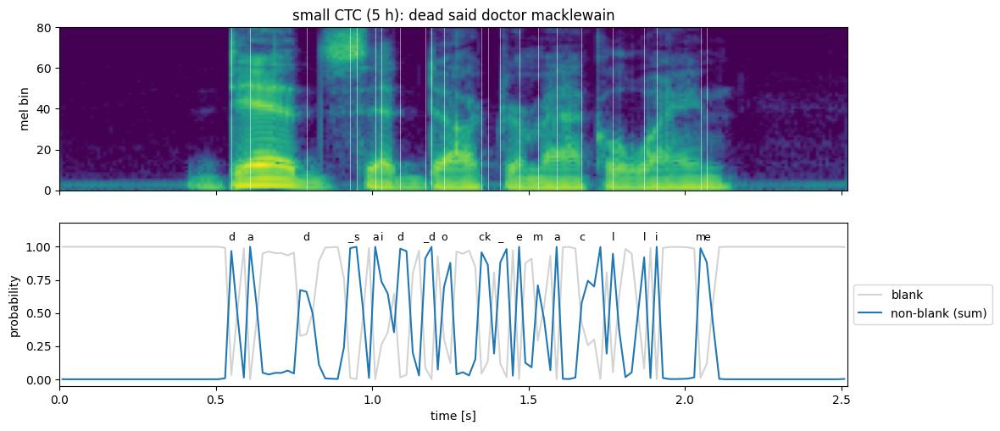

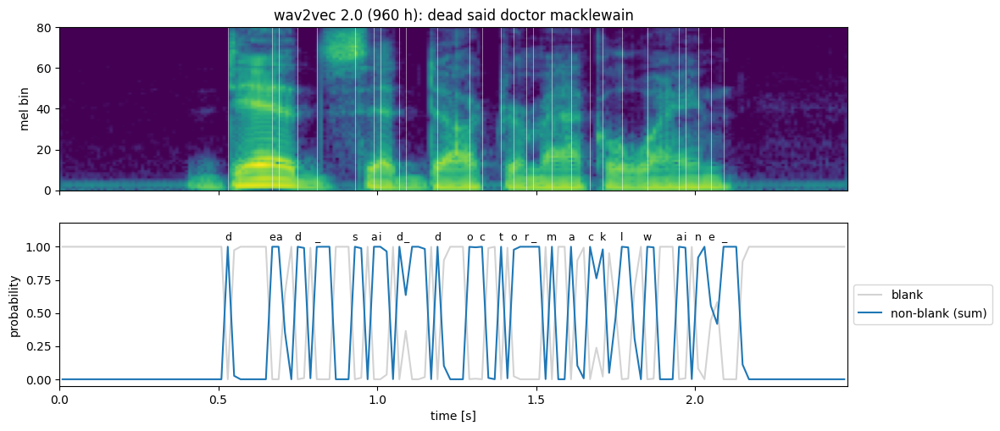

小さなCTC  : ---------------------------d--aa-------d------_ss-aii-dd--_d-oo----ck-__-e--m--a---cccc-l----l-i------me----------------------
wav2vec 2.0: --------------------------d------ea--dd-___---ss-aii-d____-d----ooc--t-oor__-m--a--cck--ll--ww---ai-nne-___-----------------

model                   blank ratio  frames per char
small CTC (5 h)                0.64             1.43
wav2vec 2.0 (960 h)            0.56             1.52


In [35]:
# 同じ発話について、自作のモデルとwav2vec 2.0のアライメントを比べる
idx = int(np.argmin([len(x) if len(x) > 250 else 10**9 for x in ls_test_x]))   # 2.5秒より長い中で最も短い発話
path, ref = ls_test[idx]
wav, _ = librosa.load(path, sr=16000)
spec = librosa.power_to_db(librosa.feature.melspectrogram(y=wav, sr=16000, n_fft=400, hop_length=160, n_mels=80), ref=np.max)

ls_labels = ["-", "_", "'"] + list("abcdefghijklmnopqrstuvwxyz")
w2v_labels = [c.lower().replace("|", "_") for c in w2v_chars]
plot_alignment(spec, np.exp(ls_test_lp[idx]), ls_labels, 0.02, "small CTC (5 h): " + ref)
plot_alignment(spec, np.exp(w2v_test_lp[idx]), w2v_labels, 0.02, "wav2vec 2.0 (960 h): " + ref, blank=w2v_blank)

print("小さなCTC  :", "".join(ls_labels[k] for k in ls_test_lp[idx].argmax(-1)))
print("wav2vec 2.0:", "".join("-" if k == w2v_blank else w2v_labels[k] for k in w2v_test_lp[idx].argmax(-1)))

# 評価用の全発話について、blankの割合と、文字1個が続くフレーム数を集計する
print(f"\n{'model':22s} {'blank ratio':>12s} {'frames per char':>16s}")
for name, lps, blank in [("small CTC (5 h)", ls_test_lp, BLANK), ("wav2vec 2.0 (960 h)", w2v_test_lp, w2v_blank)]:
    stats = np.array([alignment_stats(lp.argmax(-1), blank) for lp in lps])
    print(f"{name:22s} {stats[:, 0].mean():12.2f} {stats[:, 1].mean():16.2f}")

YESNOのときとは様子が違う
- どちらのモデルでも、文字は1フレーム（20ミリ秒）か2フレームだけ、鋭い山として現れる
  - これをCTCの**スパイク**と呼ぶ
- 1つの単語の中でも、文字と文字の間にblankが入る
  - 表示した記号列で、文字の間に `-` が挟まっていることを確認するとよい
  - YESNOのモデルでは、blankは無音区間に集中しており、単語の中には入らなかった
- 文字が続くフレーム数の平均は1.5前後（約30ミリ秒）しかない
  - YESNOのモデルでは約2.3フレーム（1フレームが40ミリ秒なので約90ミリ秒）であった
- 全フレームに占めるblankの割合は6割前後である
  - 朗読の音声は無音区間が短いので、blankの多くは発声の途中に置かれている

2つのモデルの違いも読み取れる
- wav2vec 2.0のスパイクは、ほとんどが確率1まで届いている
- 自作のモデルのスパイクには、0.5〜0.8程度で止まるものが混ざる
  - モデルが迷っているフレームであり、誤りはこういう場所で起きる
  - 言語モデルつきのビームサーチが効くのも、こういうフレームである

なぜスパイクになるのかは、次のように説明できる
- blankは、どのフレームで出しても出力列を変えない「安全な」記号である
- 文字は、出す位置を間違えたり、余分に出したりすると、出力列が変わって損失が増える
- 文字を何フレームも出し続けても、折り畳まれて1文字になるだけで得をしない
- そのため、モデルは「その文字だと最も確信できる1か所でだけ文字を出し、残りはblankにする」という出力に落ち着きやすい

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-ctc-spike.png" width=650>

上の図は、この性質を模式的に描いたものである（実際の出力は、上のセルが描く図で確かめること）
- 発声している区間（黄色）の中でも、ほとんどの時間はblankの確率が1に近く、文字は細い山としてだけ現れる

YESNOのモデルで、単語の中にblankが入らなかったのは、問題が易しすぎたためと考えられる
- 単語が2種類しかなく、最初の音を聞いた時点で残りの文字がすべて決まるので、文字を続けて出しても間違える危険がない

スパイクの性質から、実用上の注意が導かれる
- スパイクの位置は、その文字の音が鳴っている区間のどこかではあるが、開始時刻でも中心でもない
  - 単語の時刻を字幕などに使う場合、CTCのスパイクから得た時刻は数十ミリ秒から百ミリ秒程度ずれることがある
- 学習の初期に全フレームがblankになる現象（YESNOの学習で見た、誤り率がちょうど1の期間）も、同じ理由で起きる
  - まずは安全なblankだけを出し、確信が持てた場所から順に文字を出し始める

## その先: 注意機構つきエンコーダ・デコーダと自己教師あり事前学習

### CTCの限界

CTCは「各フレームの出力は互いに独立」と仮定していた
- つまり、直前にどの文字を出したかを、次の文字を決めるときに使えない
- 言語としてのつながり（「th」の次は「e」が来やすい、など）は、エンコーダが音から間接的に学ぶか、外部の言語モデルで補うしかない
- また、出力が入力より長くなる変換や、順序が入れ替わる変換（音声翻訳など）は表現できない

### 注意機構つきエンコーダ・デコーダ（Whisper）

この制約を外したのが、**注意機構つきエンコーダ・デコーダ**（attention-based encoder-decoder）である
- エンコーダが、メルスペクトログラムをフレーム単位の特徴系列に変換する（ここまではCTCのモデルと同じ役割）
- デコーダが、それまでに出力した文字列を条件として、次のトークンを1つずつ予測する
  - 文章生成の言語モデルと同じ自己回帰の形である（Transformerの章を参照）
- デコーダは、交差注意（cross-attention）でエンコーダ出力のどの時刻を見るかを自分で決める
  - アライメントを、周辺化ではなく注意の重みとして**学習する**ことになる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-ctc-vs-attention.png" width=750>

上の図の左がCTC、右が注意機構つきエンコーダ・デコーダである
- 左は、エンコーダの出力からフレームごとに記号を出し、折り畳むだけである
- 右は、デコーダが「それまでに出力した文字」と「エンコーダの出力」の両方を見て次の1文字を決め、それを入力に戻して繰り返す

|項目|CTC|注意機構つきエンコーダ・デコーダ|
|-|-|-|
|アライメントの扱い|すべてを足し合わせる（周辺化）|注意の重みとして学習する|
|出力間の依存|独立と仮定|過去の出力すべてに依存|
|入力と出力の順序|単調（入れ替わらない）|制約なし（翻訳も可能）|
|復号|1回の順伝播で全フレームを出力|トークンごとに順伝播を繰り返す|
|弱点|言語的なつながりを捉えにくい|音声に無い語句を生成することがある|

Whisperはこの方式のモデルであり、入力はここで使ったものと同じ種類のログメルスペクトログラムである
- デコーダが言語モデルの役割も兼ねるので、句読点や大文字小文字を含む自然な文が出力される
- 両者を組み合わせ、CTC損失を補助的に加えてエンコーダの学習を安定させる構成も広く使われている

Whisperを実際に動かして文字起こしを行う実習は「N-アプリ-transformer」の章の「Whisper(汎用音声認識)」の節を参照すること
- そこで計算しているWERは、この節で自作したものと同じ定義である

### 自己教師あり事前学習（wav2vec 2.0、HuBERT）

書き起こしの付いた音声は高価であるが、書き起こしの無い音声は大量に手に入る

先ほど使ったwav2vec 2.0は、これを利用するために作られたモデルである

BERT（BERTの章を参照）と同じ発想を音声に適用する
1. ラベルなしの音声だけを使い、入力の一部を隠して、隠した部分を周囲から当てる課題で事前学習する
2. 得られたモデルの上に出力層を1つ載せ、少量の書き起こし付きデータで微調整する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asr-self-supervised-pretrain.png" width=720>

上の図が2段階の流れである
- 段階1で学習したモデルの重みを、段階2にそのまま引き継ぐ

- **wav2vec 2.0**は、波形を畳み込みで特徴系列にし、その一部をマスクして、正しい特徴（を離散化したもの）を他の候補の中から選ばせる対照学習で事前学習する
- **HuBERT**は、音声特徴をクラスタリングして作った擬似ラベルを、マスクした位置について予測させる
- どちらも、微調整の段階ではCTC損失が使われる
  - 先ほどの `facebook/wav2vec2-base-960h` は、事前学習のあと960時間の書き起こしで微調整したものである
  - wav2vec 2.0の論文では、事前学習をしておけば、微調整に使う書き起こしが10分や1時間しかなくても認識が成り立つことが示されている
  - 自作のモデルが5時間の書き起こしだけではWER 0.8前後であったことと比べると、ラベルなしデータによる事前学習の効果の大きさがわかる
  - つまり、この節で学んだCTCは、事前学習モデルを音声認識器に仕上げる最後の段階で今も使われている

Whisperは大量の書き起こし付きデータ（弱い教師）で直接学習する方式、wav2vec 2.0やHuBERTはラベルなしデータで表現を学んでから少量の教師で仕上げる方式であり、データの集め方についての異なる戦略である

# 課題1（CTC音声認識の頑健性の評価）

この節で学習したYESNOの認識モデルについて、次の実験を行い、結果を考察せよ

1. テストデータの波形に白色雑音を加え、信号対雑音比（SNR）を20dB、10dB、5dB、0dBと変えたときのWERとCERを求め、SNRを横軸とするグラフに描け
  - 雑音は波形に加えること（メルスペクトログラムに変換する前）
2. 学習データにも雑音を加えるデータ拡張（「音声データ拡張」の節を参照）を行って学習し直し、1.と同じグラフを重ねて描け
3. 出力する記号を文字単位（7種類）から単語単位（blank、`yes`、`no` の3種類）に変えて学習し、誤り率が下がり始めるエポックと最終的なWERを文字単位の場合と比較せよ
4. 2.と3.の結果について、なぜそうなったと考えられるかを述べよ
5. 誤って認識された例を1つ以上取り上げ、編集距離の内訳（置換、削除、挿入のどれが何回か）を示せ
  - 誤りが1つも無い場合は、雑音を加えた条件から選ぶこと

# 音響イベント検出（Sound Event Detection）

ここまでに、音を1つのラベルに対応させる分類と、音声を文字列に変換する音声認識を扱った

ここからの3つの節では、音を扱う残りの主要な課題を順に扱う
- **音響イベント検出**: どの音が、いつからいつまで鳴ったか
- **話者認識**: 誰が話しているか
- **音声合成**: 文章から音声を作る（認識の逆向き）

各節は、その節のセルだけを上から実行すれば動くようにしてある
- ライブラリの読み込みは節ごとに行っている
- データは、前の節までに取得済みであれば、再びダウンロードすることはない（ESC-50と、「音声認識」の節のMini LibriSpeechを共用する）
- 事前学習済みモデルを使うセルは、`transformers` が必要である（「音声認識」の節の先頭のセルで導入している　Colabには最初から入っている）

この節は次の順に進む
1. 分類、タグ付け、検出の違いと、検出器の作り方（フレーム単位の予測、後処理、強ラベルと弱ラベル、評価）
2. 合成した音で検出器を学習し、後処理と評価指標を自分で実装する
3. しきい値を動かして適合率と再現率の引き換えを見る　弱ラベルだけで学習するとどうなるかを確かめる
4. 大規模データで学習済みのモデルを、実際の音に適用する（タグ付け、時刻つきの検出、ゼロショット分類、転用）
5. 「正常な音だけ」から異常を見つける考え方を小さく試し、「G-音声処理-2-異常音検知」の章へつなぐ

## 分類、タグ付け、検出の違い

「何の音か」を答える課題は、答えの細かさによって3つに分かれる

|課題|出力|例（10秒の録音）|
|-|-|-|
|分類（classification）|クリップ全体に1つのラベル|「犬」|
|タグ付け（tagging）|クリップ全体に複数のラベル|「犬」と「車」が含まれる|
|検出（detection）|ラベルごとの開始時刻と終了時刻|「犬」1.2〜2.0秒、「車」0.0〜6.5秒、「犬」7.1〜7.8秒|

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-classify-tag-detect.png" width=680>

上の図は、同じ10秒の録音に対する3つの課題の出力を並べたものである
- 分類とタグ付けの出力には時刻が含まれず、検出だけが「いつからいつまで」を答える

- この章の前半で行ったESC-50の分類は、1つのクリップに1種類の音だけが入っている前提であった
- 実際の環境では、複数の音が同時に鳴り（**重畳**、polyphonic）、鳴っていない時間のほうが長い
- 監視の用途では「異音がした」だけでなく「何時何分に、何秒間」がわからないと、設備の動作記録と突き合わせることができない

画像でいえば、分類と検出の関係は、画像分類と物体検出の関係にあたる（物体検出・分割の章を参照）
- 物体検出は平面上の矩形を求め、音響イベント検出は時間軸上の区間を求める

## フレーム単位の予測

検出器の基本的な作り方は、メルスペクトログラムの**フレームごと**に「各クラスが鳴っているか」を予測させることである
- 入力は `[時刻, 周波数]` のメルスペクトログラム、出力は `[時刻, クラス数]` の確率である
- 複数の音が同時に鳴りうるので、クラス間で確率を分け合うソフトマックスではなく、クラスごとに独立なシグモイドを使う
  - 損失は、フレームごと、クラスごとの2値交差エントロピーとなる
- 「どのクラスも鳴っていない」は、すべての出力が0に近い状態として自然に表せる

「音声認識」の節のCTCのモデルも、フレームごとに記号を出力していた
- ただしCTCでは、どのフレームでその記号を出すかは学習で制約されず、時刻としては信頼できなかった
- ここでは、フレームごとの正解を与えて学習するので、出力の時刻がそのまま検出時刻になる

モデルの構成は、畳み込みと再帰型ネットワークを組み合わせたものがよく使われる
- 畳み込み層で、周波数方向の模様（倍音の並び、帯域の広がり）を捉える
  - プーリングは周波数方向にだけ行い、時刻方向のフレーム数は減らさない（時刻の細かさを保つため）
- 双方向GRUで、前後の文脈（音が続いているか、途切れたか）を捉える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-frame-prediction.png" width=720>

上の図は、検出器の入力から出力までの形を示している
- 出力は、フレームを横、クラスを縦に並べた表であり、各マスが「そのフレームでそのクラスが鳴っている確率」である
- 赤枠のフレームのように、複数のクラスが同時に1になってよい

## しきい値と後処理

フレームごとの確率を、検出区間に変換する必要がある
1. **しきい値処理**: 確率がしきい値（例えば0.5）を超えたフレームを「鳴っている」とする
2. **中央値フィルタ**（median filter）: 各フレームを、前後数フレームの多数決で置き換える
3. 「鳴っている」が連続する部分を1つの区間とし、開始時刻と終了時刻を得る

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-postprocess.png" width=680>

上の図は、3つの手順を上から順に描いたものである
- 2段目（しきい値処理だけ）には、音の途中の切れ目と、1フレームだけの誤検出がある　3段目（中央値フィルタの後）では、どちらも消えている

中央値フィルタを入れる理由は、フレームごとの判定が互いに独立に行われるためである
- 音の途中で1フレームだけ確率が下がると、1つの音が2つの区間に分かれてしまう
- 雑音で1フレームだけ確率が上がると、長さ20ミリ秒の音が検出されてしまう
- 実際の音は一定以上の長さを持つので、多数決でこれらを取り除く
- フィルタの幅は、検出したい音の最短の長さより短くする（長くしすぎると短い音そのものが消える）

## 強ラベルと弱ラベル

フレームごとの正解（開始時刻と終了時刻の付いたラベル）を**強ラベル**（strong label）と呼ぶ
- 人が音を聴きながら境界を記録する必要があり、作成に手間がかかる

これに対して、「このクリップには犬の声が含まれる」というクリップ単位のラベルを**弱ラベル**（weak label）と呼ぶ
- 境界を付けなくてよいので、大量に集めやすい
- 後で使うAudioSetも、主に弱ラベルで作られている

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-strong-weak-label.png" width=680>

上の図は、同じクリップに付けた2種類のラベルである
- 強ラベルは時間軸上の区間、弱ラベルはクラスごとの「あり・なし」だけである

弱ラベルだけで検出器を学習する方法の基本は次のとおりである
- モデルにはフレーム単位の確率を出力させる
- それを時刻方向にまとめて（**プーリング**）、クリップ単位の確率を1つ作る
- 損失は、クリップ単位の確率と弱ラベルの間で計算する
- 学習後は、まとめる前のフレーム単位の確率を検出に使う

まとめ方によって、学習される出力の性質が変わると予想できる
- 最大値をとると、最も確信のある1フレームだけが学習され、検出区間が短くなりやすい
- 平均をとると、鳴っていないフレームまで確率を上げようとして、検出区間が長くなりやすい
- その中間として、確率の大きいフレームほど重く平均する方法（線形ソフトマックス、注意機構による重み付け）が使われる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-weak-pooling.png" width=700>

上の図は、弱ラベル学習の損失の作り方である
- フレームごとの確率（左の棒）を1つの数値にまとめてから、弱ラベルと比べる　まとめ方の違いが、学習される出力の違いになる

この予想が正しいかどうかは、後の実習で3通りを実際に学習して確かめる

「袋（クリップ）にラベルがあり、中身（フレーム）のラベルはわからない」という設定は、**複数インスタンス学習**（multiple instance learning）と呼ばれる

## 評価

検出の評価では、**適合率**（precision、検出したもののうち正しかった割合）と**再現率**（recall、正解のうち検出できた割合）の調和平均であるF値を使う
- 正しい検出の数をTP、誤検出の数をFP、見逃しの数をFNとすると、$F = 2\,TP / (2\,TP + FP + FN)$ である
- 鳴っていない時間が大半なので、単純な正解率では「何も検出しない」モデルが高得点になってしまう

何を1個と数えるかで、2つの流儀がある

|流儀|数える単位|正解の条件|性質|
|-|-|-|-|
|セグメント単位（segment-based）|一定の長さ（例えば1秒）に区切った時間区間とクラスの組|その区間内で、正解も検出も「鳴っている」|時刻の細かいずれに寛容|
|イベント単位（event-based）|検出された1つ1つの区間|クラスが同じで、開始時刻（と終了時刻）のずれが許容幅以内|分割や境界のずれに厳しい|

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-segment-vs-event.png" width=720>

上の図は、1つの音が途中で2つに分かれて検出された場合の数え方である
- セグメント単位では、1秒ごとの区間がすべて正解（TP）になる
- イベント単位では、正解の区間に対応する検出が無く（FN 1個）、2つの検出はどちらも誤検出（FP 2個）になる

- イベント単位の許容幅は**カラー**（collar）と呼ばれ、開始時刻は±200ミリ秒、終了時刻は±200ミリ秒または音の長さの20%の大きいほう、といった設定が使われる
- 1つの音が2つに分かれて検出されると、セグメント単位ではほとんど減点されないが、イベント単位では見逃し1個と誤検出2個になる
- どちらを重視するかは用途で決まる
  - 「この1時間に異音が何回あったか」を数えるならイベント単位
  - 「異音が鳴っていた時間帯」がわかればよいならセグメント単位

## 実習: 合成した音でフレーム単位の検出器を学習する

強ラベルの付いた実録音のデータは大きく、作成の手間も大きいので、ここでは音を合成して使う
- 合成であれば、どの音をいつ置いたかがわかっているので、強ラベルが正確に、いくらでも得られる
- 実際の研究でも、背景音の上に個別の音を配置して学習データを作ることが広く行われている

設定は次のとおりである
- 1クリップは10秒、サンプリング周波数は16kHz
- 背景は大きさの異なる白色雑音
- その上に、3種類の音を1〜5個、時刻と長さ（0.4〜2秒）と大きさを乱数で決めて配置する（重なってもよい）

|クラス|音の性質|メルスペクトログラム上の見え方|
|-|-|-|
|`beep`|高さが一定の音|水平な線|
|`sweep`|高さが上がる、または下がる音|斜めの線|
|`knock`|短い打撃音の繰り返し|縦縞の並び|

特徴量は、この章でこれまで使ってきたものと同じデシベルスケールのメルスペクトログラムである
- ずらし幅を320サンプル（20ミリ秒）とするので、1秒あたり50フレーム、1クリップは500フレームになる

sweep   4.58 -  5.69 s
sweep   6.75 -  8.07 s
knock   7.21 -  8.87 s
beep    3.12 -  3.61 s


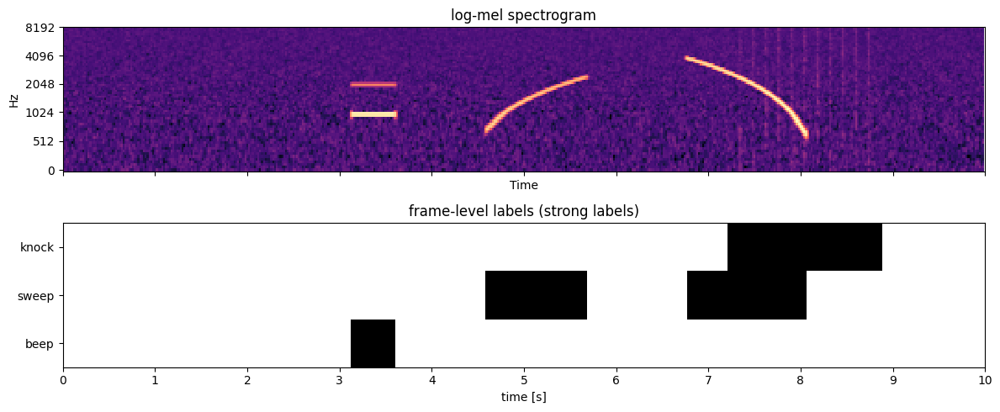

In [36]:
# 3種類の短い音を合成する関数と、それらを雑音の上に配置して1クリップを作る関数
import numpy as np
import torch
import torch.nn as nn
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

SED_SR = 16000                    # サンプリング周波数
SED_SEC = 10                      # 1クリップの長さ[秒]
SED_HOP = 320                     # ずらし幅（20ミリ秒、1秒あたり50フレーム）
SED_FRAMES = SED_SEC * SED_SR // SED_HOP
sed_classes = ["beep", "sweep", "knock"]

def synth_event(kind, dur, rng):
    # kind の音を dur 秒ぶん合成する
    t = np.arange(int(dur * SED_SR)) / SED_SR
    if kind == "beep":            # 高さが一定の音（警報音のような音）
        f = rng.uniform(600, 2500)
        x = np.sin(2 * np.pi * f * t) + 0.3 * np.sin(2 * np.pi * 2 * f * t)
    elif kind == "sweep":         # 高さが上がっていく、または下がっていく音
        f0, f1 = rng.uniform(400, 1200), rng.uniform(2000, 4000)
        if rng.random() < 0.5:
            f0, f1 = f1, f0
        x = np.sin(2 * np.pi * (f0 * t + (f1 - f0) * t ** 2 / (2 * dur)))
    else:                         # 短い打撃音が等間隔に続く音（ノックのような音）
        x = np.zeros(len(t))
        tick = int(rng.uniform(0.08, 0.15) * SED_SR)
        n = int(0.03 * SED_SR)
        for s in range(0, len(t) - n, tick):
            x[s:s + n] += rng.standard_normal(n) * np.exp(-np.arange(n) / (0.006 * SED_SR))
    fade = min(160, len(x) // 2)  # 両端をなめらかにして、不自然なクリック音を防ぐ
    x[:fade] *= np.linspace(0, 1, fade)
    x[-fade:] *= np.linspace(1, 0, fade)
    return x / (np.abs(x).max() + 1e-9)

def make_clip(rng):
    # 背景雑音の上に1〜5個の音を配置し、波形とフレーム単位の正解ラベルと区間の一覧を返す
    wav = rng.uniform(0.01, 0.05) * rng.standard_normal(SED_SEC * SED_SR)
    label = np.zeros((SED_FRAMES, len(sed_classes)), dtype=np.float32)
    events = []
    for _ in range(rng.integers(1, 6)):
        c = int(rng.integers(len(sed_classes)))
        dur = rng.uniform(0.4, 2.0)
        on = rng.uniform(0, SED_SEC - dur)
        s = int(on * SED_SR)
        x = synth_event(sed_classes[c], dur, rng)
        wav[s:s + len(x)] += rng.uniform(0.05, 0.3) * x
        label[int(round(on * SED_SR / SED_HOP)):int(round((on + dur) * SED_SR / SED_HOP)), c] = 1
        events.append((c, on, on + dur))
    return wav.astype(np.float32), label, events

def sed_logmel(wav):
    # デシベルスケールのメルスペクトログラム（[時刻, 周波数]の形）
    mel = librosa.feature.melspectrogram(y=wav, sr=SED_SR, n_fft=1024, hop_length=SED_HOP, n_mels=64)
    return librosa.power_to_db(mel, ref=1.0).T[:SED_FRAMES].astype(np.float32)

# 1クリップ作って、メルスペクトログラムと正解ラベルを並べて表示する
rng = np.random.default_rng(8)
wav, label, events = make_clip(rng)
for c, on, off in events:
    print(f"{sed_classes[c]:6s} {on:5.2f} - {off:5.2f} s")

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
librosa.display.specshow(sed_logmel(wav).T, sr=SED_SR, hop_length=SED_HOP, x_axis="time", y_axis="mel", ax=ax[0])
ax[0].set_title("log-mel spectrogram")
ax[1].imshow(label.T, aspect="auto", origin="lower", extent=[0, SED_SEC, -0.5, len(sed_classes) - 0.5], cmap="Greys",
             interpolation="nearest")
ax[1].set_yticks(range(len(sed_classes)))
ax[1].set_yticklabels(sed_classes)
ax[1].set_title("frame-level labels (strong labels)")
ax[1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(wav, rate=SED_SR))

上の図がメルスペクトログラム、下の図がフレーム単位の正解ラベル（強ラベル）である
- 3.1〜3.6秒の2本の水平な線が `beep` である（下の線が基本の高さ、上の線がその2倍の高さの成分）
- 4.6〜5.7秒の右上がりの線と、6.8〜8.1秒の右下がりの線が `sweep` である
- 7.2〜8.9秒の `knock` は、細い縦縞として薄く見えるだけである
  - `beep` と `sweep` は、エネルギーが狭い周波数帯に集まるので、小さな音でも背景から浮き上がって見える
  - `knock` は、短い雑音の繰り返しであり、エネルギーが広い周波数に散らばるので、背景の白色雑音に埋もれやすい
  - この違いが、後で検出の難しさの違いとして現れる
- 7.2〜8.1秒では `sweep` と `knock` が同時に鳴っている（正解ラベルが2つのクラスで同時に1になっている）
- 再生して、3種類の音を耳でも聞き分けてみるとよい

学習用とテスト用のデータを作る
- 乱数のシードを変えているので、テスト用のクリップは学習用のどれとも一致しない

In [37]:
# 学習用300クリップとテスト用60クリップを作る
def make_dataset(n, seed):
    rng = np.random.default_rng(seed)
    X, Y, E = [], [], []
    for _ in range(n):
        wav, label, events = make_clip(rng)
        X.append(sed_logmel(wav))
        Y.append(label)
        E.append(events)
    return torch.tensor(np.stack(X)), torch.tensor(np.stack(Y)), E

sed_Xtr, sed_Ytr, _ = make_dataset(300, seed=1)
sed_Xte, sed_Yte, sed_Ete = make_dataset(60, seed=2)

# 入力の値の範囲をそろえる（平均と標準偏差は学習用データから求める）
sed_mean, sed_std = sed_Xtr.mean(), sed_Xtr.std()
sed_Xtr, sed_Xte = (sed_Xtr - sed_mean) / sed_std, (sed_Xte - sed_mean) / sed_std
print("入力:", tuple(sed_Xtr.shape), " 正解:", tuple(sed_Ytr.shape))
print("各クラスが鳴っているフレームの割合:", sed_Ytr.mean(dim=(0, 1)).numpy().round(3))

入力: (300, 500, 64)  正解: (300, 500, 3)
各クラスが鳴っているフレームの割合: [0.117 0.112 0.099]


どのクラスも、鳴っているフレームは全体の1割程度である
- すべて「鳴っていない」と答えるだけで、フレーム単位の正解率は約9割になる
- 正解率ではなくF値で評価する理由がここにある

検出器を定義して学習する
- 畳み込み3層（周波数方向だけを1/4ずつ縮める）と双方向GRUで、約11万パラメータの小さなモデルである
- 損失関数を引数にしてあるのは、後で弱ラベル学習と比べるためである
- T4で1分以内、CPUでも数分で終わる

In [38]:
# フレーム単位の検出器（畳み込み + 双方向GRU）を定義して学習する
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SEDNet(nn.Module):
    def __init__(self, n_mels=64, n_class=3, hidden=64):
        super().__init__()
        def block(cin, cout):
            # 周波数方向だけを1/4に縮め、時刻方向のフレーム数は保つ
            return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                                 nn.MaxPool2d((1, 4)))
        self.cnn = nn.Sequential(block(1, 32), block(32, 64), block(64, 64))
        self.gru = nn.GRU(64 * (n_mels // 64), hidden, batch_first=True, bidirectional=True)
        self.out = nn.Linear(2 * hidden, n_class)

    def forward(self, x):                     # x: [バッチ, 時刻, 周波数]
        h = self.cnn(x.unsqueeze(1))          # [バッチ, チャネル, 時刻, 周波数/64]
        h = h.permute(0, 2, 1, 3).flatten(2)  # [バッチ, 時刻, 特徴]
        h, _ = self.gru(h)
        return self.out(h)                    # フレームごと、クラスごとのロジット

def train_sed(loss_fn, epochs=30, seed=0):
    # loss_fn(ロジット, フレーム単位の正解) を最小化する
    torch.manual_seed(seed)
    model = SEDNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(sed_Xtr))
        total = 0.0
        for i in range(0, len(perm), 32):
            idx = perm[i:i + 32]
            x, y = sed_Xtr[idx].to(device), sed_Ytr[idx].to(device)
            loss = loss_fn(model(x), y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch + 1:3d}  loss {total / len(perm):.4f}")
    return model

def predict_sed(model):
    # テスト用データのフレームごとの確率 [クリップ, 時刻, クラス]
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(sed_Xte.to(device))).cpu().numpy()

# 強ラベル学習: フレームごと、クラスごとの2値交差エントロピー
sed_model = train_sed(nn.BCEWithLogitsLoss())
sed_prob = predict_sed(sed_model)
print("パラメータ数:", sum(p.numel() for p in sed_model.parameters()))

epoch  10  loss 0.0930
epoch  20  loss 0.0554
epoch  30  loss 0.0372
パラメータ数: 106371


学習したモデルの出力を、検出区間に変換する

`binarize` がしきい値処理と中央値フィルタ、`to_events` が0と1の列から区間への変換である
- 小さな入力で期待どおりに動くことを `assert` で確かめている

表示するクリップの番号: 26


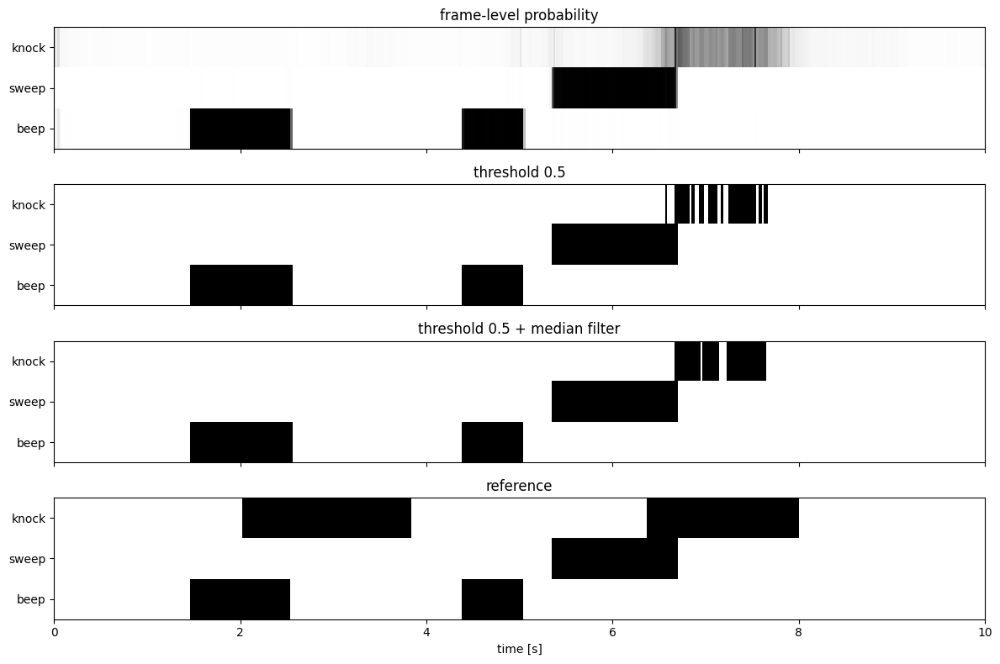

検出区間の総数  しきい値のみ: 190  中央値フィルタあり: 163  正解: 194


In [39]:
# しきい値処理と中央値フィルタで、フレームごとの確率を検出区間に変換する
from scipy.ndimage import median_filter

def binarize(prob, threshold=0.5, median=1):
    # prob: [クリップ, 時刻, クラス]　median はフィルタの幅（フレーム数、1なら何もしない）
    act = (prob > threshold).astype(np.int8)
    if median > 1:
        act = median_filter(act, size=(1, median, 1), mode="nearest")
    return act

def to_events(act):
    # 1クリップ分の0/1の列 [時刻, クラス] を (クラス, 開始[秒], 終了[秒]) の一覧にする
    events = []
    for c in range(act.shape[1]):
        a = np.concatenate([[0], act[:, c], [0]])
        d = np.diff(a)
        for on, off in zip(np.where(d == 1)[0], np.where(d == -1)[0]):
            events.append((c, on * SED_HOP / SED_SR, off * SED_HOP / SED_SR))
    return events

# 動作確認: 0 1 1 0 1 を区間に直す
assert to_events(np.array([[0], [1], [1], [0], [1]])) == [(0, 0.02, 0.06), (0, 0.08, 0.1)]
# 幅3の中央値フィルタは、1フレームだけの検出と1フレームだけの途切れを消す
assert binarize(np.array([[[0], [1], [0], [0], [1], [1], [0], [1], [1]]]), median=3)[0, :, 0].tolist() == [0, 0, 0, 0, 1, 1, 1, 1, 1]

sed_raw = binarize(sed_prob)                 # しきい値のみ
sed_med = binarize(sed_prob, median=7)       # しきい値 + 幅7フレーム（0.14秒）の中央値フィルタ

# 1クリップについて、確率、検出結果、正解を並べて表示する
k = int(np.argmax((sed_raw != sed_med).sum(axis=(1, 2))))      # 中央値フィルタで結果が最も変わったクリップ
print("表示するクリップの番号:", k)
fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ext = [0, SED_SEC, -0.5, len(sed_classes) - 0.5]
for a, img, title in zip(ax, [sed_prob[k], sed_raw[k], sed_med[k], sed_Yte[k].numpy()],
                         ["frame-level probability", "threshold 0.5", "threshold 0.5 + median filter", "reference"]):
    a.imshow(img.T, aspect="auto", origin="lower", extent=ext, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    a.set_yticks(range(len(sed_classes)))
    a.set_yticklabels(sed_classes)
    a.set_title(title)
ax[-1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()
print("検出区間の総数  しきい値のみ:", sum(len(to_events(a)) for a in sed_raw),
      " 中央値フィルタあり:", sum(len(to_events(a)) for a in sed_med),
      " 正解:", sum(len(e) for e in sed_Ete))

4段の図は、上から、モデルの出力した確率、しきい値処理だけの結果、中央値フィルタをかけた結果、正解である
- 表示しているのは、テスト用60クリップのうち、中央値フィルタの前後で結果が最も大きく変わったクリップである
  - つまり、検出がうまくいっていないクリップをわざと選んでいる　全体としての性能は、次の評価で確かめる
- このクリップには `knock` が3回入っているが、確率（1段目）は全体に薄い灰色で、はっきり黒くなる部分が少ない
  - モデルが「鳴っているかもしれない」と迷っている状態である
- しきい値処理だけの結果（2段目）は、確率が0.5をまたぐたびに検出が始まったり終わったりするので、細い縦線や、途中に切れ目のある区間になる
- 中央値フィルタをかけると（3段目）、1〜数フレームだけの細い検出と短い切れ目が消える
- それでも、正解（4段目）とは大きく違う　1つの音が複数の短い区間に分かれ、3回目の音は丸ごと見逃されている
  - 後処理は、細かな乱れを整えることはできるが、モデルが出せなかった確率を作り出すことはできない

次に、評価指標を実装する
- `segment_f1` は、時間軸を1秒ごとに区切って比べる
- `event_f1` は、検出区間と正解区間を1対1に対応させ、開始時刻と終了時刻のずれがカラー以内のものを正解と数える
- 全体の値に加えて、クラスごとの内訳も求める

In [40]:
# セグメント単位とイベント単位のF値を計算する
def f_score(tp, fp, fn):
    return 2 * tp / max(2 * tp + fp + fn, 1)

def segment_f1(act, ref, seg_sec=1.0):
    # 時間軸を seg_sec 秒の区間に切り、区間内で1フレームでも鳴っていれば「鳴っている」とみなして比べる
    n = int(seg_sec * SED_SR / SED_HOP)
    a = act.reshape(act.shape[0], -1, n, act.shape[2]).max(axis=2)
    r = ref.reshape(ref.shape[0], -1, n, ref.shape[2]).max(axis=2)
    return f_score(np.sum((a == 1) & (r == 1)), np.sum((a == 1) & (r == 0)), np.sum((a == 0) & (r == 1)))

def event_f1(est_list, ref_list, collar=0.2, off_ratio=0.2):
    # 検出区間と正解区間を1対1に対応させる
    # 同じクラスで、開始時刻のずれが collar 秒以内、終了時刻のずれが max(collar, 長さ*off_ratio) 以内なら正解
    tp = fp = fn = 0
    for est, ref in zip(est_list, ref_list):
        used = set()
        for c, on, off in ref:
            tol = max(collar, off_ratio * (off - on))
            hit = [i for i, (ce, one, offe) in enumerate(est)
                   if i not in used and ce == c and abs(one - on) <= collar and abs(offe - off) <= tol]
            if hit:      # 簡略化のため先着順で対応付ける（重なりが多いデータでは二部マッチングにする）
                used.add(hit[0])
                tp += 1
            else:
                fn += 1
        fp += len(est) - len(used)
    return f_score(tp, fp, fn)

# 動作確認: 正解と同じものを渡せばどちらも1になる
ref_act = sed_Yte.numpy().astype(np.int8)
ref_events = [to_events(a) for a in ref_act]
assert segment_f1(ref_act, ref_act) == 1.0 and event_f1(ref_events, ref_events) == 1.0

for name, act in [("しきい値のみ", sed_raw), ("中央値フィルタあり", sed_med)]:
    print(f"{name:10s} セグメント単位F値 {segment_f1(act, ref_act):.3f}"
          f"  イベント単位F値 {event_f1([to_events(a) for a in act], ref_events):.3f}")

# クラスごとの内訳（中央値フィルタあり）
for c, name in enumerate(sed_classes):
    est_c = [[e for e in to_events(a) if e[0] == c] for a in sed_med]
    ref_c = [[e for e in ev if e[0] == c] for ev in ref_events]
    print(f"{name:6s} セグメント単位F値 {segment_f1(sed_med[:, :, c:c + 1], ref_act[:, :, c:c + 1]):.3f}"
          f"  イベント単位F値 {event_f1(est_c, ref_c):.3f}")

しきい値のみ     セグメント単位F値 0.940  イベント単位F値 0.813
中央値フィルタあり  セグメント単位F値 0.941  イベント単位F値 0.872
beep   セグメント単位F値 1.000  イベント単位F値 0.973
sweep  セグメント単位F値 0.989  イベント単位F値 0.984
knock  セグメント単位F値 0.810  イベント単位F値 0.627


### 結果の読み方

全体の値
- セグメント単位のF値は、中央値フィルタの有無でほとんど変わらない（手元の実行では0.94前後）
  - 1〜2フレームの誤りは、1秒の区間の判定をほとんど変えないためである
- イベント単位のF値は、セグメント単位より低く、中央値フィルタで改善する（同0.80〜0.84から0.86〜0.89へ）
  - 細切れの検出が1つにまとまり、誤検出と見逃しが同時に減るためである
- 同じ検出結果でも、指標によって数値がこれだけ違う
  - 論文や製品の「F値」を比べるときは、どちらの流儀か、セグメントの長さやカラーがいくつかを必ず確認する

クラスごとの内訳
- `beep` と `sweep` は、どちらの指標でもほぼ完全に検出できている
- `knock` だけが低い（手元の実行では、セグメント単位0.82、イベント単位0.63〜0.70）
  - 合成した音を見たときに予想したとおり、背景雑音に埋もれやすい音が難しい
  - 先ほどの4段の図は、この `knock` の失敗例であった
- **全体の平均だけを見ていると、特定のクラスだけがうまくいっていないことに気づけない**
  - 評価では、クラスごとの値と、失敗した例の中身を必ず確認する
  - 改善の方針もクラスごとに変わる　ここでは、小さな `knock` を含む学習データを増やす、時間方向に細かい特徴量（短い窓）を使う、などが考えられる

数値は、GPUの種類や乱数によって実行ごとに少し変わる

### しきい値とフィルタの幅を変える

ここまで、しきい値は0.5、中央値フィルタの幅は7フレームに固定していた

これらを変えると何が起こるかを調べる
- しきい値を下げると、検出が増える　見逃しは減るが、誤検出が増える
- しきい値を上げると、検出が減る　誤検出は減るが、見逃しが増える
- つまり、**適合率と再現率は、しきい値を介して引き換えの関係にある**

しきい値  適合率  再現率  セグメントF値  イベントF値
  0.10    0.869   0.928     0.898        0.708
  0.30    0.985   0.906     0.944        0.874
  0.50    0.991   0.895     0.941        0.872
  0.70    0.997   0.887     0.939        0.895
  0.90    1.000   0.866     0.928        0.836
フィルタの幅[フレーム] [1, 3, 7, 15, 31, 61]
セグメントF値         [0.94  0.94  0.941 0.941 0.938 0.913]
イベントF値           [0.813 0.86  0.872 0.861 0.851 0.738]


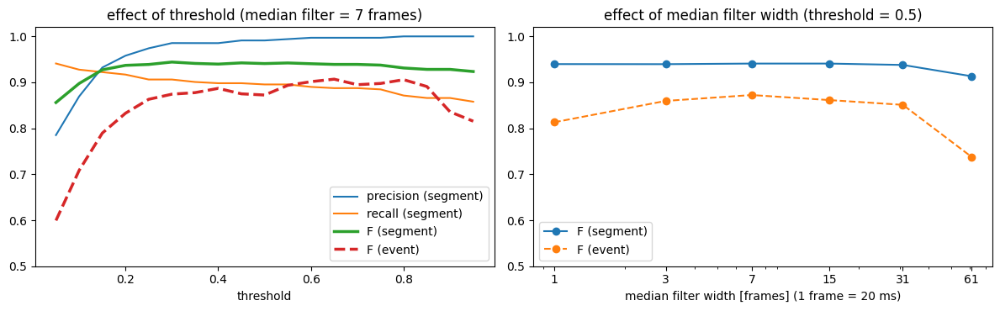

In [41]:
# しきい値と中央値フィルタの幅を変えて、適合率・再現率・F値の変化を調べる
def segment_prf(act, ref, seg_sec=1.0):
    # セグメント単位の適合率、再現率、F値
    n = int(seg_sec * SED_SR / SED_HOP)
    a = act.reshape(act.shape[0], -1, n, act.shape[2]).max(axis=2)
    r = ref.reshape(ref.shape[0], -1, n, ref.shape[2]).max(axis=2)
    tp, fp, fn = np.sum((a == 1) & (r == 1)), np.sum((a == 1) & (r == 0)), np.sum((a == 0) & (r == 1))
    return tp / max(tp + fp, 1), tp / max(tp + fn, 1), f_score(tp, fp, fn)

def event_score(act):
    return event_f1([to_events(a) for a in act], ref_events)

ths = np.round(np.arange(0.05, 1.0, 0.05), 2)
th_seg = np.array([segment_prf(binarize(sed_prob, t, median=7), ref_act) for t in ths])     # [しきい値, (適合率, 再現率, F値)]
th_evt = np.array([event_score(binarize(sed_prob, t, median=7)) for t in ths])
widths = [1, 3, 7, 15, 31, 61]
w_seg = np.array([segment_f1(binarize(sed_prob, 0.5, median=w), ref_act) for w in widths])
w_evt = np.array([event_score(binarize(sed_prob, 0.5, median=w)) for w in widths])

print("しきい値  適合率  再現率  セグメントF値  イベントF値")
for i in [1, 5, 9, 13, 17]:
    print(f"  {ths[i]:.2f}    {th_seg[i, 0]:.3f}   {th_seg[i, 1]:.3f}     {th_seg[i, 2]:.3f}        {th_evt[i]:.3f}")
print("フィルタの幅[フレーム]", widths)
print("セグメントF値        ", w_seg.round(3))
print("イベントF値          ", w_evt.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(ths, th_seg[:, 0], label="precision (segment)")
ax[0].plot(ths, th_seg[:, 1], label="recall (segment)")
ax[0].plot(ths, th_seg[:, 2], label="F (segment)", linewidth=2.5)
ax[0].plot(ths, th_evt, label="F (event)", linewidth=2.5, linestyle="--")
ax[0].set_xlabel("threshold")
ax[0].set_ylim(0.5, 1.02)
ax[0].set_title("effect of threshold (median filter = 7 frames)")
ax[0].legend()
ax[1].plot(widths, w_seg, marker="o", label="F (segment)")
ax[1].plot(widths, w_evt, marker="o", linestyle="--", label="F (event)")
ax[1].set_xscale("log")
ax[1].set_xticks(widths)
ax[1].set_xticklabels(widths)
ax[1].set_xlabel("median filter width [frames] (1 frame = 20 ms)")
ax[1].set_ylim(0.5, 1.02)
ax[1].set_title("effect of median filter width (threshold = 0.5)")
ax[1].legend()
plt.tight_layout()
plt.show()

### 結果の読み方

左の図（しきい値）
- しきい値を上げるにつれて、適合率は上がり、再現率は下がる
  - 手元の実行では、しきい値0.1で適合率0.86〜0.88・再現率0.93、しきい値0.9で適合率1.00・再現率0.86であった
- F値は両者のつり合いを見る指標なので、中間のしきい値で最大になる　ただし、0.2から0.8の広い範囲でほとんど変わらない
  - このモデルの出力は0か1に近い値が多く、中間の値をとるフレームが少ないためである
- しきい値を極端に下げると、イベント単位のF値が大きく下がる
  - 確率の低い細切れの検出が大量に現れ、それぞれが誤検出1個と数えられるためである

右の図（中央値フィルタの幅）
- 幅1（フィルタなし）から幅を広げていくと、イベント単位のF値が上がる（手元の実行では、幅1で約0.80、幅7〜31で0.86〜0.87）
- 幅を広げすぎると、逆に下がる　幅61フレーム（1.2秒）では、イベント単位のF値が0.75程度まで落ちた
  - 幅 $w$ の中央値フィルタは、長さが $w/2$ フレームに満たない検出を消す
  - 合成した音は最短0.4秒（20フレーム）なので、幅31（その半分は約15フレーム）までは音が消えないが、幅61（その半分は約30フレーム、0.6秒）では短い音そのものが消える
- 後処理の設定は、検出したい音の長さについての知識で決める

**どのしきい値がよいかは、F値では決まらない**
- F値は、見逃し1件と誤検出1件を同じ重さで扱う指標である
- 実際には、見逃しと誤検出の損害は等しくない
  - 警報音の検出で見逃しが許されないなら、適合率が下がるのを承知で、しきい値を下げる
  - 誤報のたびに人が現場へ確認に行くなら、しきい値を上げて誤報を減らす
- この考え方は、次の話者認識の節（他人受入率と本人拒否率）と、「G-音声処理-2-異常音検知」の章（誤報率からしきい値を逆算する）でも繰り返し現れる

なお、ここではテスト用データでしきい値を動かして結果を見ている
- 実際にしきい値を決めるときは、テスト用とは別の検証用データを使う　テスト用データで選ぶと、性能を過大に見積もることになる

### 弱ラベルで学習するとどうなるか

同じモデルを、クリップ単位のラベルだけで学習してみる
- `make_weak_loss` が返す損失関数は、フレーム単位の正解 `y_frame` から「そのクラスが1フレームでも鳴っているか」だけを取り出して使う
  - 開始時刻と終了時刻の情報は、ここで捨てている
- フレームの確率 $p_t$ をクリップの確率 $P$ にまとめる方法を、3通り比べる

|まとめ方|式|勾配が流れるフレーム|
|-|-|-|
|最大値（max）|$P = \max_t p_t$|確率が最大の1フレームだけ|
|平均（mean）|$P = \frac{1}{T} \sum_t p_t$|すべてのフレームに均等|
|線形ソフトマックス（linear softmax）|$P = \sum_t p_t^2 / \sum_t p_t$|確率の大きいフレームほど強く|

3回学習するので、T4で2〜3分かかる

--- max
epoch  10  loss 0.1048
epoch  20  loss 0.0241
epoch  30  loss 0.0037
--- mean
epoch  10  loss 0.5472
epoch  20  loss 0.2404
epoch  30  loss 0.1945
--- linear softmax
epoch  10  loss 0.2639
epoch  20  loss 0.2289
epoch  30  loss 0.2230

training               tagging acc  segment F  event F  active frames
strong labels                0.956      0.941    0.872          0.109
weak, max                    0.839      0.759    0.405          0.057
weak, mean                   0.878      0.427    0.000          0.714
weak, linear softmax         0.878      0.604    0.580          0.403
reference                                                       0.121


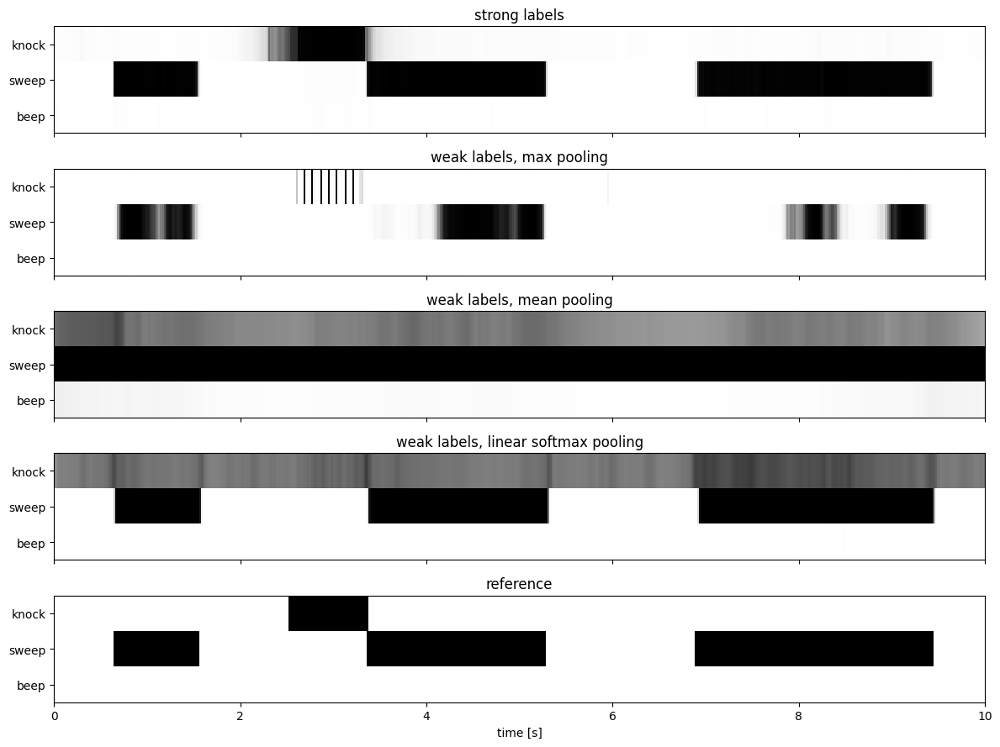

In [42]:
# 弱ラベル学習: クリップ単位のラベルだけで学習し、時刻方向のまとめ方（プーリング）による違いを比べる
def make_weak_loss(pool):
    def loss_fn(logits, y_frame):
        # クリップ単位のラベル（そのクラスが1フレームでも鳴っていれば1）だけを使う
        y_clip = y_frame.max(dim=1).values
        p = torch.sigmoid(logits)
        if pool == "max":
            p_clip = p.max(dim=1).values
        elif pool == "mean":
            p_clip = p.mean(dim=1)
        else:   # linear softmax: 確率の大きいフレームほど重く平均する
            p_clip = (p * p).sum(dim=1) / p.sum(dim=1).clamp_min(1e-7)
        return nn.functional.binary_cross_entropy(p_clip.clamp(1e-7, 1 - 1e-7), y_clip)
    return loss_fn

weak_prob = {}
for pool in ["max", "mean", "linear softmax"]:
    print("---", pool)
    weak_prob[pool] = predict_sed(train_sed(make_weak_loss(pool)))

# タグ付け正解率: 1フレームでも検出があれば、そのクリップにそのクラスがあると判定して、クリップ単位で比べる
# 検出フレームの割合: 「鳴っている」と判定されたフレームの割合（正解では約0.12）
print(f"\n{'training':22s} {'tagging acc':>11s} {'segment F':>10s} {'event F':>8s} {'active frames':>14s}")
for name, prob in [("strong labels", sed_prob)] + [("weak, " + p, weak_prob[p]) for p in weak_prob]:
    act = binarize(prob, median=7)
    print(f"{name:22s} {np.mean(act.max(axis=1) == ref_act.max(axis=1)):11.3f} {segment_f1(act, ref_act):10.3f}"
          f" {event_score(act):8.3f} {act.mean():14.3f}")
print(f"{'reference':22s} {'':11s} {'':10s} {'':8s} {ref_act.mean():14.3f}")

# 音の数が最も多いテスト用クリップについて、フレーム単位の確率を並べて表示する
kw = int(np.argmax([len(e) for e in sed_Ete]))
panels = [("strong labels", sed_prob[kw])] + [("weak labels, " + p + " pooling", weak_prob[p][kw]) for p in weak_prob] \
         + [("reference", sed_Yte[kw].numpy())]
fig, ax = plt.subplots(len(panels), 1, figsize=(12, 9), sharex=True)
for a, (title, img) in zip(ax, panels):
    a.imshow(img.T, aspect="auto", origin="lower", extent=ext, cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
    a.set_yticks(range(len(sed_classes)))
    a.set_yticklabels(sed_classes)
    a.set_title(title)
ax[-1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

### 結果の読み方

図は、音の数が最も多いテスト用クリップについて、上から、強ラベル学習、弱ラベル学習の3通り、正解を並べたものである

まとめ方によって、出力の性質がはっきり違う
- **最大値**: 検出が細切れで、短い
  - `knock` は、1回1回の打撃音の位置にだけ細い線が立っている　`sweep` も、区間の一部しか黒くなっていない
  - 「鳴っている」と判定されたフレームの割合は約0.05で、正解（約0.12）の半分以下である
  - クリップの中で最も確信のある1フレームさえ高ければ損失が下がるので、区間全体を検出する理由が無い
- **平均**: クリップ全体が「鳴っている」になる
  - `sweep` の行は、音の無い時刻まで含めて全体が真っ黒である　検出フレームの割合は約0.7に達する
  - クリップに音が含まれるなら、全フレームの確率を上げるのが、平均を1に近づける最も簡単な方法だからである
  - 時刻の情報が失われるので、イベント単位のF値はほぼ0になる
- **線形ソフトマックス**: `sweep` は、強ラベル学習とほとんど変わらない区間が得られている
  - 区間の境界を一度も教えていないのに、開始と終了が正解とほぼ一致している
  - 一方、`knock` の行は全体が灰色で、いつ鳴ったかを特定できていない　難しいクラスでは、弱ラベルだけでは時刻を絞り込めなかった

数値で見ると
- タグ付けの正解率（クリップにそのクラスが含まれるか）は、どのまとめ方でも0.82〜0.88であり、強ラベル学習（0.96）との差は比較的小さい
- フレーム単位の検出性能は、強ラベル学習（セグメント単位0.94）に対して、0.43〜0.74と大きく下がる
- **「クリップに何が含まれるか」は弱ラベルで学べるが、「いつ鳴ったか」は、まとめ方の工夫をしても強ラベルほどには学べない**

弱ラベル学習の結果は、乱数による変動が大きい
- 手元の数回の実行では、線形ソフトマックスのイベント単位F値は0.42〜0.60の範囲で変わった
- 学習の長さにも敏感で、60エポックまで延ばすと、線形ソフトマックスのセグメント単位F値は0.6から0.8程度に上がった
- 1回の実行結果だけで手法の優劣を決めてはならない

それでも弱ラベル学習が広く使われるのは、ラベルを付ける費用が桁違いに小さいためである
- 少量の強ラベルと大量の弱ラベル（やラベル無しデータ）を組み合わせるのが、実用上の定石となっている
- 次に使う学習済みモデルも、弱ラベルの大規模データで学習されたものである

## 事前学習済みの音響モデルの利用

画像でImageNetの学習済みモデルを転用したのと同じく（転移学習の章を参照）、音でも大規模データで学習済みのモデルを転用できる

ここでは2種類のモデルを使う

|モデル|学習方法|できること|
|-|-|-|
|AST（Audio Spectrogram Transformer）|AudioSetの527クラスのタグ付けを教師あり学習|527クラスの確率を出す、特徴抽出器として転用する|
|CLAP（Contrastive Language-Audio Pretraining）|音とその説明文の組で対照学習|音と文を同じ空間の埋め込みにする、ゼロショット分類|

- **AudioSet**は、動画から切り出した約10秒のクリップ約200万件に、527種類の音のラベルを付けたデータセットである
  - ラベルはクリップ単位の弱ラベルで、1クリップに複数付く
- ASTは、メルスペクトログラムを小さなパッチに分けてTransformerに入力する（画像のViTと同じ構成、ViTの章を参照）
- CLAPは、画像と文を対応付けるCLIP（CLIPの章を参照）の音版である
  - 音のエンコーダと文のエンコーダを、対応する組の埋め込みが近く、対応しない組が遠くなるように学習する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-clap-zero-shot.png" width=700>

上の図は、CLAPによるゼロショット分類の流れである
- 音とクラス名の文を別々のエンコーダで同じ空間の埋め込みにし、音の埋め込みと最も向きの近い文のクラスを答える

データには、この章の前半で使ったESC-50を使う
- 前半のセルを実行済みであれば、次のセルは何もしない

In [43]:
# ESC-50が無ければ取得する（この章の前半を実行済みなら何もしない）
import pandas as pd
!test -f ESC-50-master/LICENSE || (pip install -q gdown && gdown 1OiP_cuLUVe4c0HzUB-vro4Jm106w_lOo && unzip -q ESC-50-master.zip)
esc_dir = "ESC-50-master/"
esc_df = pd.read_csv(esc_dir + "meta/esc50.csv")

### 学習済みの分類器でタグを付ける

ASTに、ESC-50の音をそのまま入力する
- 出力は527クラスそれぞれの確率であり、合計は1にならない（複数のラベルが同時に成り立つため）

In [44]:
# AudioSetで学習済みのAST（Audio Spectrogram Transformer）で、ESC-50の音にタグを付ける
import numpy as np
import torch
import librosa
from transformers import ASTFeatureExtractor, ASTForAudioClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ast_name = "MIT/ast-finetuned-audioset-10-10-0.4593"
ast_fe = ASTFeatureExtractor.from_pretrained(ast_name)
ast_model = ASTForAudioClassification.from_pretrained(ast_name).to(device).eval()
print("出力クラス数:", ast_model.config.num_labels)

def ast_tags(path, top=5):
    wav, _ = librosa.load(path, sr=16000)            # このモデルの入力は16kHz
    inputs = ast_fe(wav, sampling_rate=16000, return_tensors="pt").to(device)
    with torch.no_grad():
        prob = torch.sigmoid(ast_model(**inputs).logits[0])   # 多ラベルなのでソフトマックスではなくシグモイド
    score, idx = prob.topk(top)
    return [(ast_model.config.id2label[i.item()], round(s.item(), 3)) for s, i in zip(score, idx)]

for cat in ["dog", "rain", "vacuum_cleaner", "siren"]:
    row = esc_df[esc_df.category == cat].iloc[0]
    print(f"{cat:15s} ->", ast_tags(esc_dir + "audio/" + row.filename))

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

出力クラス数: 527
dog             -> [('Bark', 0.199), ('Animal', 0.192), ('Dog', 0.115), ('Bow-wow', 0.1), ('Domestic animals, pets', 0.086)]
rain            -> [('Rain', 0.73), ('Rain on surface', 0.704), ('Raindrop', 0.564), ('Thunderstorm', 0.123), ('Thunder', 0.091)]
vacuum_cleaner  -> [('Vacuum cleaner', 0.185), ('Tools', 0.076), ('Jet engine', 0.07), ('Drill', 0.048), ('Power tool', 0.029)]
siren           -> [('Siren', 0.631), ('Emergency vehicle', 0.298), ('Speech', 0.213), ('Police car (siren)', 0.143), ('Car alarm', 0.114)]


- ESC-50について何も学習していないのに、内容に合ったタグが上位に並ぶ
- 「Animal」と「Dog」と「Bark」のように、上位概念と下位概念が同時に出力される
  - AudioSetのラベルは階層構造を持っており、タグ付けではこれらが矛盾しない
- 確率の値そのものは小さいことがある（犬の例では、最も高いタグでも0.2程度である）
  - 何個のタグを採用するかは、クラスごとにしきい値を決める必要がある

### タグ付けモデルで時刻つきの検出を行う

このモデルは、クリップ全体に対するタグ（弱ラベル）で学習されており、時刻は出力しない

しかし、長い録音を短い窓に区切り、窓ごとにタグ付けを行えば、「どの窓で何が鳴っていたか」がわかる
- ESC-50から4種類の音（雨、犬、サイレン、掃除機）を5秒ずつつないで、20秒の録音を作る
- 2秒の窓を0.5秒ずつずらしながら、窓ごとに4つのクラスの確率を求める

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-sliding-window.png" width=700>

上の図は、窓ごとのタグ付けで時刻つきの検出を行う様子である
- 境界をまたぐ窓（赤）には2種類の音が入るので、確率は境界の前後でなだらかに変わる

合成した音ではなく、実際に録音された音での検出である

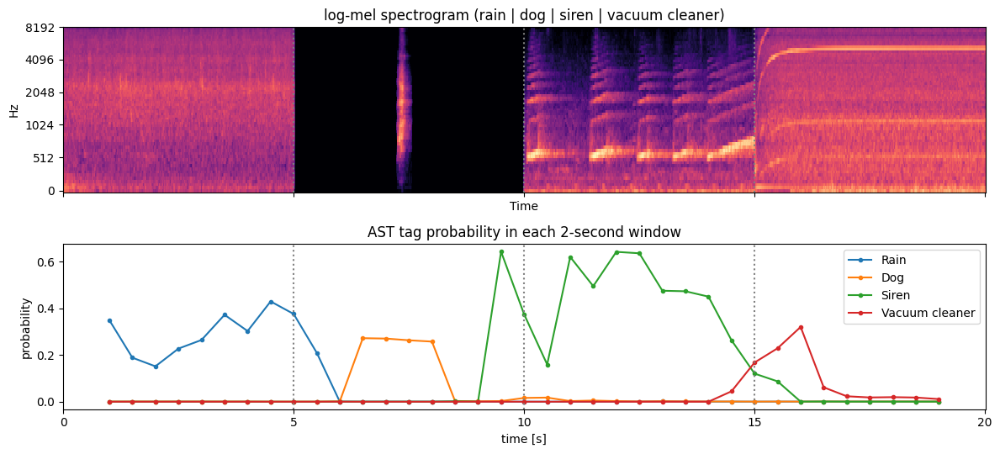

rain            の区間: Rain 0.27  Dog 0.00  Siren 0.00  Vacuum cleaner 0.00
dog             の区間: Rain 0.00  Dog 0.15  Siren 0.00  Vacuum cleaner 0.00
siren           の区間: Rain 0.00  Dog 0.00  Siren 0.54  Vacuum cleaner 0.00
vacuum_cleaner  の区間: Rain 0.00  Dog 0.00  Siren 0.00  Vacuum cleaner 0.07


In [45]:
# 実際の音をつないだ20秒の録音に、タグ付けモデル（AST）を2秒の窓ごとに適用して、時刻つきの検出を行う
stream_cats = ["rain", "dog", "siren", "vacuum_cleaner"]       # 5秒ずつ、この順につなぐ
stream = np.concatenate([librosa.load(esc_dir + "audio/" + esc_df[esc_df.category == c].iloc[0].filename, sr=16000)[0]
                         for c in stream_cats])
watch = ["Rain", "Dog", "Siren", "Vacuum cleaner"]             # 確率を追跡するAudioSetのクラス
watch_ids = [ast_model.config.label2id[w] for w in watch]

AST_WIN, AST_HOP = 2.0, 0.5                                    # 窓の長さとずらし幅[秒]
win_starts = np.arange(0, len(stream) / 16000 - AST_WIN + 1e-6, AST_HOP)
segments = [stream[int(s * 16000):int((s + AST_WIN) * 16000)] for s in win_starts]
inputs = ast_fe(segments, sampling_rate=16000, return_tensors="pt").to(device)
with torch.no_grad():
    win_prob = torch.sigmoid(ast_model(**inputs).logits)[:, watch_ids].cpu().numpy()     # [窓の数, 4]

fig, ax = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
mel = librosa.power_to_db(librosa.feature.melspectrogram(y=stream, sr=16000, n_fft=1024, hop_length=320, n_mels=64), ref=np.max)
librosa.display.specshow(mel, sr=16000, hop_length=320, x_axis="time", y_axis="mel", ax=ax[0])
ax[0].set_title("log-mel spectrogram (rain | dog | siren | vacuum cleaner)")
for j, w in enumerate(watch):
    ax[1].plot(win_starts + AST_WIN / 2, win_prob[:, j], marker="o", markersize=3, label=w)
for b in [5, 10, 15]:
    for a in ax:
        a.axvline(b, color="gray", linestyle=":")
ax[1].set_xlabel("time [s]")
ax[1].set_ylabel("probability")
ax[1].set_title("AST tag probability in each 2-second window")
ax[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

# 各5秒の区間で、4つのクラスの確率の平均を表にする
for i, c in enumerate(stream_cats):
    inside = (win_starts >= 5 * i) & (win_starts + AST_WIN <= 5 * (i + 1))
    print(f"{c:15s} の区間:", "  ".join(f"{w} {win_prob[inside, j].mean():.2f}" for j, w in enumerate(watch)))

上の図がつないだ録音のメルスペクトログラム、下の図が窓ごとの確率である（点線は音の切り替わる時刻）

- 4種類の音それぞれについて、対応する区間でそのクラスの確率が上がり、他の区間ではほぼ0になっている
  - 時刻のラベルを一切使わずに学習したモデルで、時刻つきの検出ができている
- 犬の区間（5〜10秒）は、メルスペクトログラムを見ると、鳴き声は7秒過ぎの1回だけで、残りは無音である
  - `Dog` の確率が上がるのは、鳴き声を含む窓（中心が6.5〜8秒付近）だけである　無音の窓では何も検出されない
- 切り替わりの前後では、確率がなだらかに変わる　例えば `Siren` は、境界の10秒より前の窓（中心9.5秒）で既に高い
  - 窓の長さが2秒あるので、窓の中心が境界より前でも、窓の後半にはサイレンが入っている
  - **時刻の細かさは、窓の長さより良くはならない**　窓を短くすれば細かくなるが、1つの窓に入る情報が減って判定が不安定になる
- 掃除機の区間では、切り替わった直後だけ確率が上がり、その後は低いままである
  - 一定の音がずっと続く**定常音**は、短い窓で切り取ると手がかりが少なく、このモデルでは確信が持てていない
  - しきい値を全クラス共通の値にすると、掃除機は見逃される　クラスごとにしきい値を決める必要がある

この「窓ごとに点数を付け、時刻方向に並べて判定する」という形は、「G-音声処理-2-異常音検知」の章の「流れてくる音を窓ごとに判定する」でも使われる

### 音と文の対照学習モデルによるゼロショット分類

CLAPで、ESC-50の2000クリップすべてと、50クラスの名前から作った文（`This is a sound of dog` など）を埋め込みにする
- T4で1分程度かかる

In [46]:
# 音とテキストの対照学習モデルCLAPで、ESC-50の全クリップとクラス名の文を埋め込みにする
from transformers import ClapModel, ClapProcessor

clap_name = "laion/clap-htsat-unfused"
clap_proc = ClapProcessor.from_pretrained(clap_name)
clap_model = ClapModel.from_pretrained(clap_name).to(device).eval()

def unit(v):
    # 長さ1に正規化する（内積がコサイン類似度になる）
    return v / v.norm(dim=-1, keepdim=True)

def clap_audio_embed(paths, batch=32):
    out = []
    for i in range(0, len(paths), batch):
        wavs = [librosa.load(p, sr=48000)[0] for p in paths[i:i + batch]]   # このモデルの入力は48kHz
        inputs = clap_proc(audio=wavs, sampling_rate=48000, return_tensors="pt").to(device)
        with torch.no_grad():
            h = clap_model.audio_model(input_features=inputs["input_features"]).pooler_output
            out.append(unit(clap_model.audio_projection(h)).cpu())
    return torch.cat(out)

def clap_text_embed(texts):
    inputs = clap_proc(text=texts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        h = clap_model.text_model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"]).pooler_output
        return unit(clap_model.text_projection(h)).cpu()

esc_cats = sorted(esc_df.category.unique())
esc_y = torch.tensor([esc_cats.index(c) for c in esc_df.category])
esc_emb = clap_audio_embed([esc_dir + "audio/" + f for f in esc_df.filename])
txt_emb = clap_text_embed(["This is a sound of " + c.replace("_", " ") for c in esc_cats])
print("音の埋め込み:", tuple(esc_emb.shape), " テキストの埋め込み:", tuple(txt_emb.shape))

preprocessor_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  614MB            

model.safetensors: downloading bytes:           |  0.00B            

音の埋め込み: (2000, 512)  テキストの埋め込み: (50, 512)


埋め込みが得られれば、分類は内積を計算するだけである
- **ゼロショット分類**: 各クリップについて、50個の文の埋め込みのうち最も近いものを答えとする　学習は一切行わない
- **転用（線形分類器）**: 音の埋め込みを特徴量として、ロジスティック回帰を学習する

In [47]:
# ゼロショット分類（学習なし）と、埋め込みの上の線形分類器（転用）を、同じテストデータで比べる
from sklearn.linear_model import LogisticRegression

test = torch.tensor(esc_df.fold.values == 5)        # ESC-50は5分割が決められている　第5分割をテストに使う
sim = esc_emb @ txt_emb.T                            # [クリップ数, クラス数] のコサイン類似度
zs_pred = sim.argmax(dim=1)
print(f"ゼロショット分類の正解率: {(zs_pred[test] == esc_y[test]).float().mean().item():.3f}")

clf = LogisticRegression(max_iter=2000, C=10.0).fit(esc_emb[~test].numpy(), esc_y[~test].numpy())
print(f"線形分類器（第1〜4分割の1600件で学習）の正解率: {clf.score(esc_emb[test].numpy(), esc_y[test].numpy()):.3f}")

# クラス名に無い言葉でも検索できる: 文に最も近いクリップを3件ずつ表示する
for q in ["an animal is making noise", "water is flowing", "a machine with a motor is running"]:
    s = esc_emb @ clap_text_embed([q])[0]
    print(q, "->", [esc_df.category[i] for i in s.topk(3).indices.tolist()])

ゼロショット分類の正解率: 0.895
線形分類器（第1〜4分割の1600件で学習）の正解率: 0.970
an animal is making noise -> ['crow', 'crow', 'crow']
water is flowing -> ['rain', 'rain', 'rain']
a machine with a motor is running -> ['engine', 'washing_machine', 'engine']


### 結果の読み方

- ゼロショット分類は、ESC-50のラベルを1つも使わずに9割近い正解率になった（手元の実行では0.895）
- 埋め込みの上で線形分類器を学習すると、さらに高くなった（同0.970）
  - 学習は数秒で終わる　この章の前半でResNetを50エポック学習させたのと比べると、手間の差は大きい
- クラス名に無い言い回し（「モーターのある機械が動いている」など）でも、意味の近い音を取り出せる
  - クラスを後から追加したり、言葉で検索したりできるのが、対照学習モデルの利点である

注意点もある
- 公開されている大規模モデルは、学習データにどの音が含まれていたかを完全には確認できない
  - 公開の評価用データと同じ出所の音を学習時に見ている可能性があるので、上の数値を「未知の音に対する性能」とそのまま受け取ってはならない
- ゼロショット分類の結果は、文の書き方（プロンプト）で変わる
- 学習データに少ない種類の音（特定の機械の動作音など）では、性能は保証されない

### 埋め込みの転用: 「正常な音だけ」で異常を見つける

線形分類器による転用では、すべてのクラスのラベル付きデータを使った

しかし、機械の監視では事情が違う
- 工場の設備、空調、車両などの機械は、故障の前に音が変わることが多い
- ところが、検出器の学習に必要な「異常な音」の録音は、ほとんど手に入らない　故障はめったに起こらず、わざと起こすこともできない
- しかも、次に起こる故障が過去と同じ音を出すとは限らない

そこで問題の立て方を変える
- **正常な音だけ**を集め、「正常からどれだけ外れているか」を点数（**異常スコア**）にする
- これを**異常音検知**（anomalous sound detection）と呼ぶ

埋め込みがあれば、これは学習なしで試せる
1. 正常な音の埋め込みを保存しておく（参照データ）
2. 新しい音の埋め込みと、参照データの中で近いものとの類似度を求める
3. 類似度が低いほど「いつもと違う」とみなす（**k近傍法**）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/sed-knn-anomaly.png" width=650>

上の図は、埋め込み空間でのk近傍法の考え方である
- 正常音のかたまりの近くにある音Aは異常スコアが低く、離れた音Bは高くなる

ここでは考え方を確かめるために、ESC-50の1つのクラス（洗濯機、掃除機など）を「正常」、それ以外のすべての音を「異常」とみなす
- 評価には**AUC**を使う　正常と異常を1件ずつ取り出したとき、異常のほうの点数が高い確率であり、0.5ならでたらめ、1.0なら完全に分けられることを表す（「機械学習の基礎」の章を参照）
- しきい値を決めなくても、点数の付け方の良し悪しを比べられる

In [48]:
# 埋め込みを使った「正常音だけ」による検知の予告編: 1つのクラスを正常とし、それ以外の音を異常とみなす
import soundfile as sf
from sklearn.metrics import roc_auc_score

E = esc_emb.numpy()
is_test = esc_df.fold.values == 5

def knn_anomaly_score(ref, x, k=3):
    # 参照する正常音の埋め込みのうち、近いほうからk個とのコサイン類似度の平均が低いほど「いつもと違う」
    sim = x @ ref.T
    return 1 - np.sort(sim, axis=1)[:, -k:].mean(axis=1)

for normal in ["washing_machine", "vacuum_cleaner", "engine", "clock_tick"]:
    is_normal = (esc_df.category == normal).values
    ref = E[is_normal & ~is_test]                          # 正常音32件を参照データにする（学習は行わない）
    score = knn_anomaly_score(ref, E[is_test])             # 第5分割の400件（正常8件、それ以外392件）に点数を付ける
    auc = roc_auc_score(~is_normal[is_test], score)
    print(f"正常 = {normal:16s} 参照 {len(ref)} 件  AUC = {auc:.3f}")

# 正常音に雑音が重なっただけで、点数はどう変わるか（正常 = washing_machine の場合）
is_normal = (esc_df.category == "washing_machine").values
ref = E[is_normal & ~is_test]
rng = np.random.default_rng(0)
noisy_paths = []
for f in esc_df.filename[is_normal & is_test]:
    wav, sr = librosa.load(esc_dir + "audio/" + f, sr=48000)
    noise = rng.standard_normal(len(wav)) * np.sqrt(np.mean(wav ** 2) / 10 ** (10 / 10))     # SNR 10dBの白色雑音
    sf.write("noisy_" + f, wav + noise, sr)
    noisy_paths.append("noisy_" + f)
s_clean = knn_anomaly_score(ref, E[is_normal & is_test])
s_noisy = knn_anomaly_score(ref, clap_audio_embed(noisy_paths).numpy())
s_other = knn_anomaly_score(ref, E[~is_normal & is_test])
print(f"\n異常スコアの平均  正常 {s_clean.mean():.3f}  雑音を重ねた正常 {s_noisy.mean():.3f}  他のクラスの音 {s_other.mean():.3f}")
threshold = s_clean.max()
print(f"正常音の最大値 {threshold:.3f} をしきい値にすると、雑音を重ねた正常音8件のうち {(s_noisy > threshold).sum()} 件が異常と判定される")

正常 = washing_machine  参照 32 件  AUC = 0.986
正常 = vacuum_cleaner   参照 32 件  AUC = 0.999
正常 = engine           参照 32 件  AUC = 1.000
正常 = clock_tick       参照 32 件  AUC = 1.000

異常スコアの平均  正常 0.200  雑音を重ねた正常 0.312  他のクラスの音 0.685
正常音の最大値 0.305 をしきい値にすると、雑音を重ねた正常音8件のうち 5 件が異常と判定される


### 結果の読み方

- 正常音32件の埋め込みを保存しておくだけで、AUCは0.99〜1.00になった
  - ネットワークの学習は一切行っていない　異常の例も1つも使っていない
- ただし、これは非常に易しい設定である
  - 「異常」とした音は、犬の声や雨の音など、洗濯機とは種類のまったく違う音である
  - 実際の機械の監視で見つけたいのは、**同じ機械の、いつもと少しだけ違う音**である　これは、音の種類を見分けるように学習された埋め込みにとって、はるかに難しい

後半の実験は、もう1つの問題を示している
- 正常な洗濯機の音に白色雑音（SNR 10dB）を重ねただけで、異常スコアの平均は0.20から0.31に上がった
- 正常音の最大値をしきい値にすると、雑音を重ねた正常音8件のうち5件が「異常」と判定された
- 機械は正常なのに、録音の条件が変わっただけで警報が出ることになる
  - 異常検知は「いつもと違う」ことを検知するので、機械の変化と環境の変化を区別できない
  - これは**ドメインシフト**と呼ばれ、実際の現場で最も問題になる点である

この2つの問題（同じ機械のわずかな違いを見分けること、条件の変化に惑わされないこと）に、実際の機械の録音で取り組むのが、「G-音声処理-2-異常音検知」の章である
- そこでは、ここと同じ「事前学習済みモデルの埋め込みと、正常音からの距離」の手法を、ASTの埋め込みを使ってポンプとバルブの音に適用し、他の手法（統計量、AutoEncoder、識別型）と比べている

## 機械の監視への応用: 「G-音声処理-2-異常音検知」の章へ

機械の音による異常検知は、「G-音声処理-2-異常音検知」の章で、実際の機械（ポンプとバルブ）の録音を使って本格的に扱う

この節で扱った内容は、G-2の章の次の箇所に対応する

|この節で扱ったこと|G-2の章での対応|
|-|-|
|デシベルスケールのメルスペクトログラム|第2部「特徴量」　窓長、ホップ長、メルフィルタの本数が、異常の見え方をどう変えるか|
|合成した音で仕組みを確かめる|第2部「機械音を合成して確かめる」　回転数と高調波、欠陥の種類ごとの音の違い|
|定常的な音と短い音の難しさの違い|第2部「定常音と突発音」　ポンプ（定常音）とバルブ（突発音）で、効く手法が違う|
|事前学習済みモデル（AST）の埋め込みと、正常音からの距離|第3部「事前学習済みの音響モデル」　ASTの埋め込みにk近傍法とマハラノビス距離を当てる　どの層の埋め込みがよいか、参照する正常音は何個必要か|
|フレームや窓ごとの点数、しきい値、時刻方向の平滑化|第4部「流れてくる音を窓ごとに判定する」「誤報を抑える: 平滑化と連続検知」|
|適合率と再現率の引き換え、しきい値の決め方|第3部「部分AUC」「しきい値の決め方」「誤報率から逆算する」、第4部「誤報と見逃しのコストからしきい値を決める」|
|雑音が重なっただけで点数が上がる|第4部「ドメインシフトへの対処」　正規化、データ拡張、少数の新条件データでの適応|

G-2の章で新しく出てくる考え方もある
- 再構成誤差による検知（AutoEncoder）と、その弱点
- 機械の個体を当てる補助タスクで表現を学ぶ、識別型の手法
- 回転機械に特有の信号処理（エンベロープ解析）
- 軽量化とエッジ機器への搭載、正常の定義が時間とともに変わることへの対処

この節の音響イベント検出と、G-2の章の異常音検知の違いを整理しておく

|項目|音響イベント検出（この節）|異常音検知（G-2の章）|
|-|-|-|
|見つけたいもの|あらかじめ決めた種類の音|種類のわからない「いつもと違う音」|
|学習データ|見つけたい音の例（強ラベルまたは弱ラベル）|正常な音だけ|
|出力|クラスごとの確率と区間|1つの異常スコア|
|主な評価指標|F値（セグメント単位、イベント単位）|AUC、部分AUC|
|向いている場面|警報音、ガラスの割れる音など、起こりうる音が列挙できる場合|故障のように、起こり方が予想できない場合|

- 実際の監視システムでは、両方を組み合わせることも多い
  - 既知の異常音（過去に起きた故障の音）は検出器で名前を付けて検出し、未知の変化は異常音検知で拾う

# 話者認識（Speaker Recognition）

音声認識は「何と言ったか」を取り出し、誰が話したかの違いは捨てる

**話者認識**はその逆で、「誰が話したか」を取り出し、何を言ったかの違いは捨てる

## 話者識別と話者照合

話者認識には2つの課題がある

|課題|問い|出力|例|
|-|-|-|-|
|話者識別（speaker identification）|登録された $N$ 人のうち誰か|$N$ 人のうちの1人|会議の録音から発言者を特定する|
|話者照合（speaker verification）|名乗った本人か|はい、または、いいえ|声による本人確認|

<img src="https://class.west.sd.keio.ac.jp/dataai/text/spk-identify-vs-verify.png" width=720>

上の図は、2つの課題の入力と出力の違いである
- 話者識別は登録された全員と比べて1人を選び、話者照合は名乗った1人とだけ比べて、しきい値で本人か他人かを判定する

- 話者識別は $N$ クラスの分類であり、人数が増えるほど難しくなる
- 話者照合は2値の判定であり、登録人数には依存しない
  - ただし、学習時に見たことのない人に対しても働かなければならない（未知のクラスを扱う）
  - この点で、顔認証と同じ構造の問題である

話す内容による区別もある
- **テキスト依存**（text-dependent）: 決められた言葉（合言葉）を話してもらう　短い発話でも精度が出やすい
- **テキスト非依存**（text-independent）: 何を話してもよい　使いやすいが、内容の違いに影響されない特徴が必要になる

以下では、テキスト非依存の話者照合を中心に扱う

## 話者埋め込み

学習時にいなかった人を扱うために、分類器そのものではなく**話者埋め込み**（speaker embedding）を使う
1. 可変長の音声を、ニューラルネットワークで固定長のベクトル（数百次元）に変換する
2. 2つの音声の埋め込みの**コサイン類似度**を計算する
3. 類似度がしきい値以上なら「同じ人」と判定する

$$ \mathrm{sim}(\mathbf{e}_1, \mathbf{e}_2) = \frac{\mathbf{e}_1 \cdot \mathbf{e}_2}{\|\mathbf{e}_1\| \, \|\mathbf{e}_2\|} $$

- 新しい人を登録するには、その人の音声の埋め込みを保存するだけでよい（再学習は不要）
- 文の埋め込みで検索を行う（NLPの章、LLMの応用の章を参照）のと同じ仕組みである

### 統計プーリング

可変長の系列を固定長にする部分が要点である
- エンコーダは、フレームごとの特徴 $\mathbf{h}_1, \dots, \mathbf{h}_T$ を出力する（$T$ は発話の長さで変わる）
- **統計プーリング**（statistics pooling）は、時刻方向の平均と標準偏差を求めて並べる

$$ \boldsymbol{\mu} = \frac{1}{T} \sum_{t=1}^{T} \mathbf{h}_t, \qquad \boldsymbol{\sigma} = \sqrt{\frac{1}{T} \sum_{t=1}^{T} (\mathbf{h}_t - \boldsymbol{\mu})^2}, \qquad \mathbf{e} = W [\boldsymbol{\mu}; \boldsymbol{\sigma}] $$

- 何を話したかは時刻とともに変わるが、声の性質は発話全体を通じて変わらない
  - 時刻方向に平均すると、内容による変動が打ち消され、話者に固有の成分が残る、という考え方である
- 標準偏差を加えるのは、声の高さや音色の「揺れ方」も話者の特徴になるためである
- この構成の埋め込みは**x-vector**と呼ばれる
- フレームごとに重みを付けて平均する注意機構つきのプーリングもある（無音や雑音のフレームを軽く扱える）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/spk-embedding-pooling.png" width=750>

上の図は、長さの違う2つの発話が、同じ次元のベクトルになるまでの流れである
- エンコーダの出力は発話の長さに応じた個数のフレームであるが、統計プーリングで時刻方向にまとめると、長さによらない1本のベクトルになる

### マージン付き損失

埋め込みは、学習用の数千人の話者を分類する課題で学習する
- 通常のソフトマックス損失でも分類はできるが、「クラスの境界を越えていればよい」という学習になる
- 照合では、未知の人どうしを類似度で比べるので、同じ人の埋め込みは固まり、違う人の埋め込みは離れていてほしい

そこで、正解クラスに対してだけ条件を厳しくする
- 埋め込みと各クラスの重みベクトルを正規化し、ロジットをコサイン類似度 $\cos\theta_k$ で表す
- 正解クラス $y$ のロジットだけを、マージン $m$ のぶん不利にしてから、スケール $s$ を掛けてソフトマックスに入れる

$$ L = -\log \frac{e^{s(\cos\theta_y - m)}}{e^{s(\cos\theta_y - m)} + \sum_{k \neq y} e^{s \cos\theta_k}} $$

- 正解クラスとの類似度が、他のクラスより $m$ 以上大きくならないと損失が下がらない
- その結果、同じ話者の埋め込みがより狭い範囲に集まる
- 角度そのものにマージンを加える $\cos(\theta_y + m)$ の形もあり、顔認証で広く使われている

<img src="https://class.west.sd.keio.ac.jp/dataai/text/spk-margin-loss.png" width=700>

上の図は、長さ1に正規化した埋め込みを円周上の点として描いた模式図である
- 通常の損失（左）では、埋め込みは境界のすぐ近くまで広がる
- マージン付き損失（右）では、境界の両側にすき間ができ、同じ話者の埋め込みが重みベクトルの近くに集まる

## 評価: 2種類の誤りと等価誤り率

照合の誤りには2種類ある

|誤り|内容|日本語の呼び方|困ること|
|-|-|-|-|
|FRR（False Rejection Rate）|本人なのに拒否した割合|本人拒否率|利便性が下がる|
|FAR（False Acceptance Rate）|他人なのに受け入れた割合|他人受入率|安全性が下がる|

<img src="https://class.west.sd.keio.ac.jp/dataai/text/spk-score-distributions.png" width=560>

上の図は、類似度の2つの分布としきい値の関係を示す概念図である（測定値ではない）
- しきい値より右にはみ出した別話者対が他人受入、左にはみ出した同一話者対が本人拒否になる

しきい値を動かすと、2つは逆向きに変わる
- しきい値を上げる（厳しくする）と、FARは下がり、FRRは上がる
- しきい値を下げる（緩くする）と、FRRは下がり、FARは上がる

1つの数値でモデルを比べるために、FARとFRRが等しくなる点の誤り率を使う
- これを**等価誤り率**（Equal Error Rate、EER）と呼ぶ
- EERは、しきい値の選び方に依存しない、モデルの分離能力の指標である

<img src="https://class.west.sd.keio.ac.jp/dataai/text/spk-far-frr-eer.png" width=560>

上の図は、しきい値を動かしたときの2つの誤り率の変化を示す概念図である（測定値ではない）
- 2本の曲線が交わる点の誤り率がEERである　実際の曲線は、後の実習で求める

ただし、実際に運用するしきい値がEERの点である必要はない
- 決済や入退室の認証では、他人の受け入れは重大なので、FARを十分小さく（例えば0.1%以下に）するしきい値を選び、FRRの増加は受け入れる
- スマートスピーカーの利用者の切り替えのように、誤っても害の小さい用途では、FRRを小さくする側に寄せる
- しきい値は、評価に使うデータとは別のデータで決める
  - 評価データでしきい値を決めると、そのデータに都合のよい値になり、性能を過大に見積もる

## 実習: 事前学習済みの話者埋め込みで照合を行う

### データ

**Mini LibriSpeech**の開発用セット（`dev-clean-2`）を使う
- 「音声認識」の節の後半で、評価用データとして使ったものと同じである
  - そこでは「何と言ったか」（書き起こし）を使ったが、ここでは「誰が言ったか」（話者ID）だけを使う
  - 同じ録音が、ラベルの見方を変えるだけで別の課題のデータになる
- 26人の話者、1089発話、圧縮ファイルは約126MBである
- ディレクトリ名が話者IDになっているので、「誰の声か」のラベルがそのまま得られる

次のセルは、`LibriSpeech/dev-clean-2` が既にあれば何もダウンロードしない
- 「音声認識」の節を実行済みであれば、そのデータをそのまま使う
- この節から始めた場合は、ここで取得する

In [49]:
# 複数話者の英語読み上げ音声（Mini LibriSpeechの開発用セット、約126MB）を取得する
import os, glob, tarfile, urllib.request

if not os.path.exists("LibriSpeech/dev-clean-2"):
    urllib.request.urlretrieve("https://www.openslr.org/resources/31/dev-clean-2.tar.gz", "dev-clean-2.tar.gz")
    with tarfile.open("dev-clean-2.tar.gz") as tar:
        tar.extractall(".")

# ディレクトリは 話者ID/章ID/話者ID-章ID-発話番号.flac の形になっている
spk_files = {}
for path in sorted(glob.glob("LibriSpeech/dev-clean-2/*/*/*.flac")):
    spk_files.setdefault(path.split("/")[-3], []).append(path)
print("話者数:", len(spk_files), " 発話数:", sum(len(v) for v in spk_files.values()))

話者数: 26  発話数: 1089


### 話者埋め込みの計算

話者埋め込みモデルには、`microsoft/wavlm-base-plus-sv` を使う
- 自己教師あり学習モデルWavLM（「音声認識」の節で触れたwav2vec 2.0やHuBERTの系統）の上に、統計プーリングを持つx-vectorの層を載せ、話者照合用に学習したモデルである
- 入力は16kHzの波形、出力は512次元の埋め込みである

20人の話者から8発話ずつ、合計160発話を選ぶ
- 長い発話は先頭の6秒だけを使う（短い音声での照合を想定する）
- 1発話ずつ処理するので、T4で1分程度かかる

In [50]:
# 20人の話者から8発話ずつ選び、話者埋め込みを求める
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt
from transformers import AutoFeatureExtractor, WavLMForXVector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(0)
N_SPK, N_UTT, MAX_SEC = 20, 8, 6

spk_wavs, spk_ids = [], []
for s in sorted(spk_files)[:N_SPK]:
    for path in rng.choice(spk_files[s], N_UTT, replace=False):
        wav, _ = librosa.load(path, sr=16000)
        spk_wavs.append(wav[:MAX_SEC * 16000])       # 長い発話は先頭6秒だけを使う
        spk_ids.append(s)
spk_ids = np.array(spk_ids)

sv_name = "microsoft/wavlm-base-plus-sv"
sv_fe = AutoFeatureExtractor.from_pretrained(sv_name)
sv_model = WavLMForXVector.from_pretrained(sv_name).to(device).eval()

def speaker_embed(wavs):
    # 波形のリストを、長さ1に正規化した話者埋め込み [発話数, 次元] にする
    out = []
    for wav in wavs:      # 長さの違う発話を無音で埋めてまとめると埋め込みが変わるので、1発話ずつ処理する
        inputs = sv_fe(wav, sampling_rate=16000, return_tensors="pt").to(device)
        with torch.no_grad():
            e = sv_model(**inputs).embeddings
        out.append(torch.nn.functional.normalize(e, dim=-1).cpu())
    return torch.cat(out).numpy()

spk_emb = speaker_embed(spk_wavs)
print("発話の長さ[秒]:", [round(len(w) / 16000, 1) for w in spk_wavs[:8]])
print("話者埋め込み:", spk_emb.shape)

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/58.6k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  405MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/266 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


model.safetensors: reconstructing file:   0%|          |  0.00B /  404MB            

model.safetensors: downloading bytes:           |  0.00B            

発話の長さ[秒]: [6.0, 4.2, 6.0, 6.0, 2.3, 1.7, 6.0, 4.6]
話者埋め込み: (160, 512)


### 類似度の分布

160発話から作れるすべての対（12720組）について、コサイン類似度を計算する
- 同じ話者の対は560組、別の話者の対は12160組である

比較のために、学習を一切しない埋め込みも作る
- MFCC（この章の前半を参照）の、時刻方向の平均と標準偏差を並べたベクトルである
- 統計プーリングを、ニューラルネットワークの出力ではなく、MFCCに直接適用したものにあたる

同一話者対: 560  別話者対: 12160


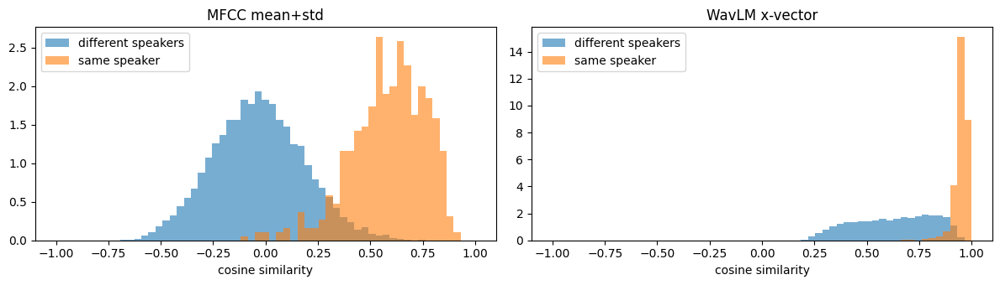

In [51]:
# 比較用: MFCCの平均と標準偏差を並べただけの埋め込み（学習なしの統計プーリング）
def mfcc_stats_embed(wavs):
    out = []
    for wav in wavs:
        m = librosa.feature.mfcc(y=wav, sr=16000, n_mfcc=20)[1:]      # 第0成分（音量に相当）を除く
        out.append(np.concatenate([m.mean(axis=1), m.std(axis=1)]))   # 時刻方向の統計量で固定長にする
    e = np.stack(out)
    e = (e - e.mean(axis=0)) / e.std(axis=0)                          # 次元ごとに尺度をそろえる
    return e / np.linalg.norm(e, axis=1, keepdims=True)

mfcc_emb = mfcc_stats_embed(spk_wavs)

def pair_scores(emb, ids):
    # すべての発話対のコサイン類似度を、同一話者対と別話者対に分けて返す
    sim = emb @ emb.T
    i, j = np.triu_indices(len(ids), k=1)
    same = ids[i] == ids[j]
    return sim[i, j][same], sim[i, j][~same]

sv_same, sv_diff = pair_scores(spk_emb, spk_ids)
mf_same, mf_diff = pair_scores(mfcc_emb, spk_ids)
print("同一話者対:", len(sv_same), " 別話者対:", len(sv_diff))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for a, same, diff, title in [(ax[0], mf_same, mf_diff, "MFCC mean+std"), (ax[1], sv_same, sv_diff, "WavLM x-vector")]:
    bins = np.linspace(-1, 1, 60)
    a.hist(diff, bins=bins, alpha=0.6, density=True, label="different speakers")
    a.hist(same, bins=bins, alpha=0.6, density=True, label="same speaker")
    a.set_xlabel("cosine similarity")
    a.set_title(title)
    a.legend()
plt.tight_layout()
plt.show()

- どちらの図でも、同じ話者の対（same speaker）の類似度は、別の話者の対（different speakers）より右側に分布する
- 2つの山は完全には分かれず、重なる部分がある
  - 重なりの部分が、どこにしきい値を置いても誤る対である
- 分布の位置は、埋め込みによってまったく違う
  - MFCCの統計量では、別の話者の対は0を中心に広がり、同じ話者の対は0.3〜0.9にある
  - WavLMの埋め込みでは、別の話者の対が0.2〜0.95に広く分布し、同じ話者の対は大部分が0.9以上の狭い範囲に集まっている
  - コサイン類似度の絶対値には意味がなく、「0.8なら同じ人」のような共通の基準は無い　しきい値は、モデルごとにデータから決める必要がある

### 埋め込みを目で見る

512次元の埋め込みは、そのままでは見ることができない

そこで、近いものどうしが近くに来るように2次元に写す**t-SNE**という方法で、160発話の埋め込みを平面に並べる
- 点の色と番号が話者を表す　同じ話者の8発話が1か所に固まっていれば、埋め込みが話者をよく表している
- t-SNEは、近くの点どうしの関係を保つように配置する方法であり、離れたかたまりの間の距離や、かたまりの大きさには意味が無い

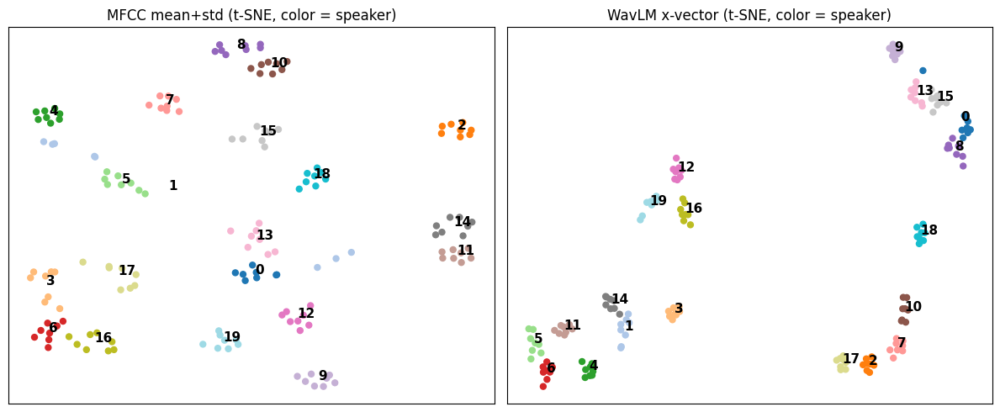

In [52]:
# 話者埋め込みを2次元に写して、話者ごとに色分けして表示する
from sklearn.manifold import TSNE

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
spk_index = np.array([sorted(set(spk_ids)).index(s) for s in spk_ids])
for a, emb, title in [(ax[0], mfcc_emb, "MFCC mean+std"), (ax[1], spk_emb, "WavLM x-vector")]:
    xy = TSNE(n_components=2, perplexity=15, metric="cosine", init="random", random_state=0).fit_transform(emb)
    a.scatter(xy[:, 0], xy[:, 1], c=spk_index, cmap="tab20", s=25)
    for s in range(N_SPK):                       # 各話者の重心に番号を書く
        a.text(*xy[spk_index == s].mean(axis=0), str(s), fontsize=11, weight="bold")
    a.set_title(title + " (t-SNE, color = speaker)")
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show()

- どちらの埋め込みでも、同じ話者の発話は、おおむね1つのかたまりになっている
- WavLMの埋め込みのほうが、かたまりが小さくまとまり、かたまりどうしの間が空いている
- MFCCの統計量では、かたまりが緩く、1〜2個の点がかたまりから離れている話者がある（図の中で、同じ色の点が離れた場所にあるもの）
  - このような発話が、同じ話者なのに類似度が低い対、つまり本人拒否の原因になる
- この図は、あくまで様子を見るためのものである　性能の比較は、次に求めるEERで行う

### EERの計算

しきい値を動かしながらFARとFRRを求め、両者が交わる点を探す
- `compute_eer` は、極端な場合（完全に分かれている場合は0、区別できない場合は約0.5）で確かめている

MFCC mean+std   EER = 6.07%  しきい値 = 0.308
WavLM x-vector  EER = 4.64%  しきい値 = 0.898


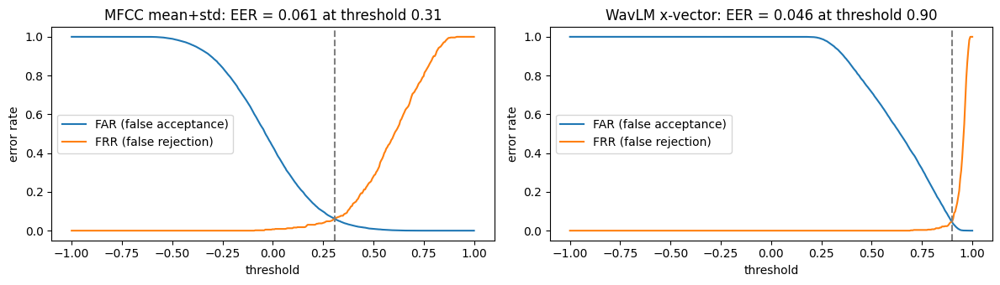

FAR<=0.1%とするしきい値 = 0.954  そのときのFRR = 44.11%


In [53]:
# 本人拒否率と他人受入率をしきい値ごとに求め、等価誤り率（EER）を計算する
def far_frr(same, diff, thresholds):
    # 類似度がしきい値以上なら「本人」と判定する
    far = np.array([(diff >= t).mean() for t in thresholds])   # 他人受入率: 別話者対を本人と判定した割合
    frr = np.array([(same < t).mean() for t in thresholds])    # 本人拒否率: 同一話者対を他人と判定した割合
    return far, frr

def compute_eer(same, diff):
    # 観測された類似度をすべてしきい値の候補とし、FARとFRRの差が最小になる点を探す
    thresholds = np.sort(np.concatenate([same, diff]))
    far, frr = far_frr(same, diff, thresholds)
    k = np.argmin(np.abs(far - frr))
    return (far[k] + frr[k]) / 2, thresholds[k]

# 動作確認: 完全に分かれていればEERは0、同じ分布ならほぼ0.5になる
assert compute_eer(np.array([0.8, 0.9]), np.array([0.1, 0.2]))[0] == 0.0
_r = np.random.default_rng(0)
assert abs(compute_eer(_r.normal(size=5000), _r.normal(size=5000))[0] - 0.5) < 0.03

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ts = np.linspace(-1, 1, 400)
for a, same, diff, title in [(ax[0], mf_same, mf_diff, "MFCC mean+std"), (ax[1], sv_same, sv_diff, "WavLM x-vector")]:
    eer, th = compute_eer(same, diff)
    far, frr = far_frr(same, diff, ts)
    a.plot(ts, far, label="FAR (false acceptance)")
    a.plot(ts, frr, label="FRR (false rejection)")
    a.axvline(th, color="gray", linestyle="--")
    a.set_xlabel("threshold")
    a.set_ylabel("error rate")
    a.set_title(f"{title}: EER = {eer:.3f} at threshold {th:.2f}")
    a.legend()
    print(f"{title:15s} EER = {eer * 100:.2f}%  しきい値 = {th:.3f}")
plt.tight_layout()
plt.show()

# 他人受入率を0.1%以下に抑えるしきい値と、そのときの本人拒否率
th_strict = np.sort(sv_diff)[int(np.ceil(len(sv_diff) * 0.999))]
print(f"FAR<=0.1%とするしきい値 = {th_strict:.3f}  そのときのFRR = {(sv_same < th_strict).mean() * 100:.2f}%")

### 結果の読み方

- しきい値を上げるとFARが下がり、FRRが上がる　2本の曲線の交点がEERである
- 手元の実行では、EERはWavLMの埋め込みで約4.6%、MFCCの統計量で約6.1%であった
- WavLMの埋め込みでは、2本の曲線が0.9付近の狭い範囲で急に入れ替わる
  - しきい値を少し動かすだけで、FARとFRRが大きく変わる　しきい値の設定に敏感であることを意味する
- FARを0.1%以下にするしきい値では、FRRが4割を超える
  - 「他人をほぼ受け入れない」設定にすると、本人も半分近く拒否される
  - EERだけを見ていると、この運用上の厳しさは見えない
- ここでは同じ160発話でしきい値を決めて評価もしているので、得られた数値は楽観的である

学習なしのMFCCの統計量が意外に健闘しているのには、理由がある
- このデータは静かな環境での朗読であり、1人の話者の録音は、同じマイク、同じ部屋で行われている
- MFCCの平均は、声の性質だけでなく、マイクや部屋の周波数特性も含んでいる
  - つまり「同じ話者か」ではなく「同じ録音環境か」を見分けているだけの可能性がある

これを確かめるために、半数の発話にだけ弱い白色雑音を加えて、録音条件が揃っていない状況を作る

In [54]:
# 録音条件が変わった場合: 半数の発話にだけ白色雑音（SNR 20dB）を加えて、EERを求め直す
def add_noise(wav, snr_db, rng):
    noise = rng.standard_normal(len(wav))
    scale = np.sqrt(np.mean(wav ** 2) / 10 ** (snr_db / 10))      # 信号と雑音のパワー比がsnr_dbになる大きさ
    return (wav + scale * noise).astype(np.float32)

rng = np.random.default_rng(1)
mixed_wavs = [add_noise(w, 20, rng) if i % 2 else w for i, w in enumerate(spk_wavs)]
for name, emb in [("MFCC mean+std", mfcc_stats_embed(mixed_wavs)), ("WavLM x-vector", speaker_embed(mixed_wavs))]:
    eer, th = compute_eer(*pair_scores(emb, spk_ids))
    print(f"{name:15s} EER = {eer * 100:.2f}%  しきい値 = {th:.3f}")

/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


MFCC mean+std   EER = 33.04%  しきい値 = 0.176
WavLM x-vector  EER = 7.32%  しきい値 = 0.884


- 雑音はSNR 20dBであり、信号のパワーが雑音の100倍ある　声を聞き取るのに支障のない程度の弱い雑音である
- それでも、MFCCの統計量によるEERは大きく悪化し、ほとんど使いものにならなくなる（手元の実行では約33%）
  - 雑音の有無という録音条件の違いが、話者の違いより大きく埋め込みを動かしてしまう
- WavLMの埋め込みも悪化するが、その幅は小さい（同約7%）
  - 多数の話者の、条件の異なる録音で学習しているため、条件の違いに影響されにくい特徴を使っている

話者照合の難しさは、きれいな録音で人を見分けることではなく、**録音条件が変わっても同じ人を同じと判定する**ことにある
- 実際の評価では、登録時と照合時で、機器、場所、日時、体調が違うデータを使う
- 上で得た数値は、条件の揃った小さなデータでのものであり、公表されているベンチマークの値と直接比べることはできない
- 「条件が変わると性能が崩れる」という問題は、「G-音声処理-2-異常音検知」の章でドメインシフトとして詳しく扱うものと同じである

### 発話の長さの影響

もう1つ、性能を大きく左右するのが発話の長さである

これまで各発話の先頭6秒までを使っていたが、これを1秒、2秒、4秒に短くして、EERを求め直す

1 秒  MFCC 15.54%  WavLM 21.96%
2 秒  MFCC 10.85%  WavLM 10.00%
4 秒  MFCC  7.16%  WavLM  5.00%
6 秒  MFCC  6.07%  WavLM  4.64%


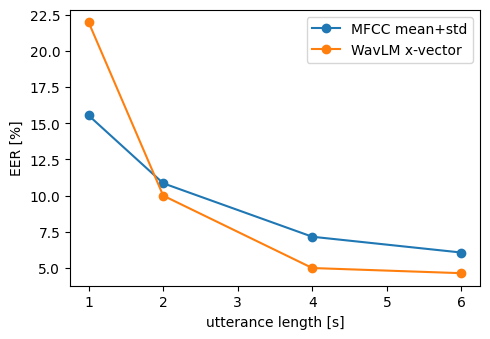

In [55]:
# 発話の長さを変えて、EERがどう変わるかを調べる
dur_list = [1, 2, 4, 6]
dur_eer = {"MFCC mean+std": [], "WavLM x-vector": []}
for sec in dur_list:
    cut = [w[:sec * 16000] for w in spk_wavs]
    dur_eer["MFCC mean+std"].append(compute_eer(*pair_scores(mfcc_stats_embed(cut), spk_ids))[0])
    dur_eer["WavLM x-vector"].append(compute_eer(*pair_scores(speaker_embed(cut), spk_ids))[0])
    print(f"{sec} 秒  MFCC {dur_eer['MFCC mean+std'][-1] * 100:5.2f}%  WavLM {dur_eer['WavLM x-vector'][-1] * 100:5.2f}%")

plt.figure(figsize=(5, 3.5))
for name, v in dur_eer.items():
    plt.plot(dur_list, np.array(v) * 100, marker="o", label=name)
plt.xlabel("utterance length [s]")
plt.ylabel("EER [%]")
plt.legend()
plt.tight_layout()
plt.show()

- どちらの埋め込みでも、発話が短いほどEERは大きくなる
  - 統計プーリングは、時刻方向の平均で「何を話したか」の変動を打ち消している　短い発話では平均するフレームが少なく、話した内容の影響が残る
- WavLMの埋め込みは、4秒以上あれば5%前後であるが、2秒で10%、1秒では約22%まで悪化する
  - 1秒では、学習なしのMFCCの統計量（約16%）より悪い
  - このモデルは数秒以上の発話で学習されており、極端に短い入力は想定されていない
- **事前学習済みモデルは、学習時と同じ条件で使ったときにだけ、公表されている性能を出す**
  - 使う前に、自分の用途の条件（発話の長さ、雑音、言語）で必ず評価し直す
- 実用のシステムが「もう少し長く話してください」と求めることがあるのは、このためである
  - 短い合言葉で照合したい場合は、テキスト依存の方式を使う

### 話者識別

同じ埋め込みで、話者識別も行える
- 各話者の4発話の埋め込みを平均して、その人の登録データとする（複数の発話を平均すると、発話ごとのばらつきが減る）
- 残りの4発話について、最も類似度の高い登録データの話者を答えとする

In [56]:
# 話者識別: 各話者の先頭4発話の平均を登録データとし、残りの発話が誰のものかを最も近い登録データで決める
enroll = np.arange(len(spk_ids)) % N_UTT < 4
speakers = sorted(set(spk_ids))
for name, emb in [("MFCC mean+std", mfcc_emb), ("WavLM x-vector", spk_emb)]:
    proto = np.stack([emb[enroll & (spk_ids == s)].mean(axis=0) for s in speakers])
    proto /= np.linalg.norm(proto, axis=1, keepdims=True)
    pred = np.array(speakers)[(emb[~enroll] @ proto.T).argmax(axis=1)]
    print(f"{name:15s} {len(speakers)}人の中からの話者識別の正解率: {(pred == spk_ids[~enroll]).mean():.3f}")

MFCC mean+std   20人の中からの話者識別の正解率: 0.963
WavLM x-vector  20人の中からの話者識別の正解率: 0.975


- 20人の中から選ぶ話者識別は、高い正解率になる
- 人数が増えると、似た声の人が現れる確率が上がるので、正解率は下がっていく
- 登録されていない人の声が入力される場合は、最も近い人を答える前に、類似度がしきい値を超えているかを確かめる必要がある（照合と識別の組み合わせ）

## 話者ダイアライゼーション

会議や通話の録音では、複数の人が入れ替わりながら話す

**話者ダイアライゼーション**（speaker diarization）は、「誰がいつ話したか」を求める課題である
- 出力は「話者A: 0.0〜4.2秒、話者B: 4.5〜9.1秒、話者A: 9.0〜12.3秒、...」のような区間の列である
- 話者が誰であるか（名前）は求めない　同じ人の区間に同じ記号が付いていればよい
- 音響イベント検出の「クラス」が、あらかじめ決まっていない話者に置き換わったものと考えることができる

基本的な構成は、これまでに扱った部品の組み合わせである
1. **音声区間検出**（Voice Activity Detection、VAD）で、誰かが話している区間を取り出す（フレーム単位の2値の検出）
2. 取り出した区間を1〜2秒程度の短い窓に分け、それぞれの話者埋め込みを求める
3. 埋め込みを**クラスタリング**する　1つのクラスタが1人の話者に対応する（人数がわからない場合は、類似度のしきい値で決める）
4. 同じクラスタの連続する窓をつなぎ、区間の列にする

<img src="https://class.west.sd.keio.ac.jp/dataai/text/spk-diarization-pipeline.png" width=720>

上の図は、4つの手順を上から順に描いたものである
- 窓ごとの埋め込みをクラスタリングし、同じクラスタの窓をつなぐと、「話者1、話者2、話者1、話者3」という区間の列になる

評価には、誤った話者に割り当てられた時間、見逃した時間、誤って検出した時間の合計を全発話時間で割った**ダイアライゼーション誤り率**（Diarization Error Rate、DER）を使う

### 小さな実験

手順の2.と3.を、実際に動かしてみる
- 照合の実習で使わなかった3人の話者の発話を、3〜6秒ずつ交互につないで、約30秒の「会話」を作る
  - つないだ時刻がわかっているので、正解（誰がいつ話したか）が正確に得られる
  - 朗読の録音をつないだだけなので、実際の会話にある相づちや発話の重なりは無い（その意味で易しい設定である）
- 1.5秒の窓を0.5秒ずつずらして、窓ごとに話者埋め込みを求める
- 3人であることを与えて、k-means法（「Sklearn」の章を参照）で埋め込みを3つのクラスタに分ける
- クラスタの番号（0、1、2）と話者（A、B、C）の対応は決まっていないので、一致する窓の数が最大になる対応を選んでから、誤りを数える

音声区間検出は省略し、全区間を対象にする

窓の数 65  話者を誤った窓 3  誤り率 0.046
誤った窓の中心から最も近い交代時刻までの距離[秒]: [0.04 0.14 0.13]


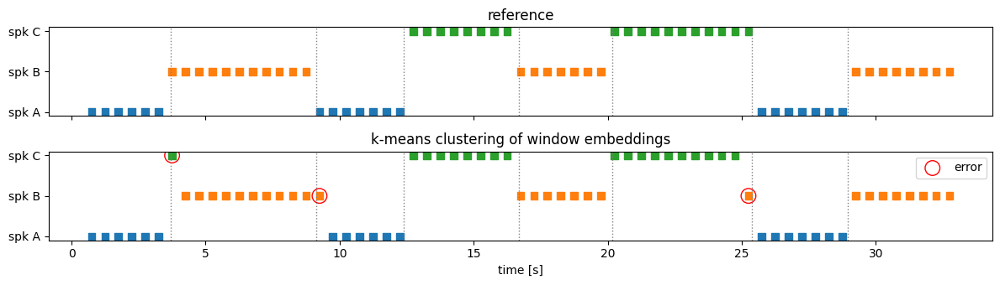

In [57]:
# 3人の話者の発話を交互につないだ「会話」を作り、窓ごとの話者埋め込みをクラスタリングして「誰がいつ話したか」を求める
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(3)
dia_speakers = sorted(spk_files)[23:26]            # 照合の実習で使っていない3人
turns = [0, 1, 0, 2, 1, 2, 0, 1]                    # 話す順番（話者の番号）
dia_wav, dia_ref = [], []                           # 波形と、(開始[秒], 終了[秒], 話者)の正解
t = 0.0
for s in turns:
    path = rng.choice(spk_files[dia_speakers[s]])
    wav, _ = librosa.load(path, sr=16000)
    wav = wav[:int(rng.uniform(3, 6) * 16000)]      # 1回の発言は3〜6秒
    dia_wav.append(wav)
    dia_ref.append((t, t + len(wav) / 16000, s))
    t += len(wav) / 16000
dia_wav = np.concatenate(dia_wav)

# 1.5秒の窓を0.5秒ずつずらして、窓ごとに埋め込みを求める
WIN, HOP = 1.5, 0.5
starts = np.arange(0, len(dia_wav) / 16000 - WIN, HOP)
win_emb = speaker_embed([dia_wav[int(s * 16000):int((s + WIN) * 16000)] for s in starts])
centers = starts + WIN / 2

# 人数（3人）を与えて、k-means法でクラスタリングする（埋め込みは長さ1に正規化済みなので、距離の近さはコサイン類似度の高さに対応する）
cluster = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(win_emb)

# 窓の中心時刻での正解の話者
ref_spk = np.array([next(s for a, b, s in dia_ref if a <= c < b) for c in centers])
# クラスタの番号と話者の番号は対応していないので、一致が最大になる対応を求める
count = np.array([[np.sum((cluster == i) & (ref_spk == j)) for j in range(3)] for i in range(3)])
row, col = linear_sum_assignment(-count)
mapped = np.array([dict(zip(row, col))[c] for c in cluster])
wrong = mapped != ref_spk
print(f"窓の数 {len(centers)}  話者を誤った窓 {wrong.sum()}  誤り率 {wrong.mean():.3f}")
# 誤った窓が、話者の交代時刻からどれだけ離れているか
change = np.array([b for a, b, s in dia_ref[:-1]])
print("誤った窓の中心から最も近い交代時刻までの距離[秒]:", np.round([np.abs(change - c).min() for c in centers[wrong]], 2))

fig, ax = plt.subplots(2, 1, figsize=(12, 3.5), sharex=True)
for a, lab, title in [(ax[0], ref_spk, "reference"), (ax[1], mapped, "k-means clustering of window embeddings")]:
    a.scatter(centers, lab, c=lab, cmap="tab10", vmin=0, vmax=9, s=40, marker="s")
    for b in change:
        a.axvline(b, color="gray", linestyle=":", linewidth=1)
    a.set_yticks(range(3))
    a.set_yticklabels(["spk A", "spk B", "spk C"])
    a.set_title(title)
ax[1].scatter(centers[wrong], mapped[wrong], facecolors="none", edgecolors="red", s=160, label="error")
ax[1].legend(loc="upper right")
ax[1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

上の図が正解、下の図がクラスタリングの結果である（四角1つが1つの窓、点線が話者の交代時刻、赤い丸が誤り）

- 65個の窓のうち、誤ったのは3個だけであった（手元の実行では誤り率0.046）
- 誤った窓は、すべて話者の交代時刻のすぐ近く（0.15秒以内）にある
  - 窓の長さは1.5秒あるので、交代時刻をまたぐ窓には2人の声が混ざっている
  - クラスタリングは1つの窓に1人しか割り当てられないので、どちらに判定しても半分は誤りになる
- 交代から離れた窓は、すべて正しく3人に分けられている　話者の名前も登録データも与えていない点に注意する

ただし、この結果をそのまま一般化してはならない
- 同じ実験を別の3人の組で行うと、手元では誤り率が0.14〜0.45になる組があった（声の似た話者が含まれる場合）
- クラスタリングの方法（k-means法、凝集型、スペクトラルクラスタリング）を変えるだけでも、誤り率は大きく変わった
- 窓を長くすると埋め込みは安定するが、交代時刻の近くの誤りが増える　窓を短くするとその逆になる（上で見た、発話の長さとEERの関係による）
- ここでは人数（3人）を与えたが、実際には人数もわからない

実際のダイアライゼーションがさらに難しくなる要因
- 複数の人が同時に話す部分（発話の重なり）がある　クラスタリングは1つの窓に1人しか割り当てられない
  - そこで、音響イベント検出と同じく、フレームごとに「各話者が話しているか」をシグモイドで直接出力するモデルも使われている
- 相づちのような、1秒に満たない短い発話が多い
- 話者によって発話量が大きく偏る

音声認識と組み合わせると、発言者つきの議事録が作れる

## 声は生体情報である

声から得た話者埋め込みは、指紋や顔の特徴量と同じく、個人を識別できる**生体情報**である

パスワードとの違いを理解しておく必要がある
- 漏れても変更できない（声は取り替えられない）
- 本人が知らないうちに取得できる（録音は離れた場所からでもできる）
- 声からは、本人であること以外にも、性別、年代、体調、感情などが推定されうる

話者認識を使うシステムを作るときは、次の点に注意する
- **同意**: 何のために声を登録し、何に使うかを説明し、本人の同意を得る　同意した目的以外には使わない
- **保管**: 埋め込みは個人情報として扱う　暗号化し、アクセスできる人を限り、不要になれば削除する
  - 録音そのものを残す必要があるかも検討する（埋め込みだけで足りるなら、録音は残さない）
- **代替手段**: 声を登録したくない人、声が変わった人のために、別の認証手段を用意する
- **なりすまし**: 録音の再生や、次の節で扱う合成音声による攻撃がありうる　声だけで重要な認証を行わない
- **誤りの偏り**: 上の実習で見たとおり、誤り率は発話の長さや録音条件で大きく変わる　特定の利用者（声の似た家族、雑音の多い環境で使う人）にだけ誤りが集中しないかを確かめる
- 生体情報の取り扱いは、国や地域の法令で規制されている　実際に運用する前に、適用される法令と組織の規程を確認する

研究や演習でも同じである
- 他人の声を録音してデータにするときは、本人の了解を得る
- 公開データセットを使うときは、その利用条件を確認する

# 音声合成（Text-to-Speech）

**音声合成**（Text-to-Speech、TTS）は、文章を入力として音声の波形を出力する

音声認識の逆向きの変換であるが、難しさの性質が違う
- 音声認識は多対一である　話し方が違っても、同じ文には同じ文字列を返せばよい
- 音声合成は一対多である　同じ文でも、速さ、高さ、抑揚、声色の違う無数の正解がある
  - 学習データの「平均的な正解」を出力させると、どの話し方でもない、抑揚に乏しく細部のぼやけた音声になる
  - どの正解を選ぶかをモデルが決めなければならず、生成モデル（GAN、拡散モデル、言語モデルの各章を参照）の技術が使われる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-one-to-many.png" width=680>

上の図は、認識と合成の対応の向きの違いである
- 認識では多くの音声が1つの文字列にまとまり、合成では1つの文字列から多くの正解が枝分かれする

この節は次の順に進む
1. 全体の流れ（テキストの前処理、音響モデル、ボコーダ）
2. 日本語のテキスト前処理を実際に動かす（読みの推定、アクセントの推定、アクセントが声の高さに現れること）
3. メルスペクトログラムから波形を作る難しさ（位相）を確かめ、Griffin-Lim法を実装し、ニューラルボコーダと比べる
4. 公開モデルで英語と日本語の文章を音声にし、音声認識に通して確かめる（合成と認識の往復）
5. 評価の方法と、悪用の危険

## 全体の流れ

多くの音声合成システムは、3つの段階に分けられる

|段階|入力 → 出力|役割|
|-|-|-|
|テキストの前処理（フロントエンド）|文章 → 音素と韻律の記号列|読みを決める|
|音響モデル|記号列 → メルスペクトログラム|どの音を、どの長さ、どの高さで出すかを決める|
|ボコーダ（vocoder）|メルスペクトログラム → 波形|実際の音の波を作る|

- 中間表現としてメルスペクトログラムが使われるのは、この章で見てきたとおり、音の内容を少ない次元で表せるためである
  - 1秒の音声は、波形では16000〜48000個の値であるが、メルスペクトログラムでは80次元のベクトルが100個前後である
  - 文字列からいきなり波形を作るより、メルスペクトログラムを経由するほうが学習しやすい

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-pipeline.png" width=760>

上の図は、3つの段階と、その間を流れるデータである
- 前処理が音素と高低の列を作り、音響モデルがメルスペクトログラムを作り、ボコーダが波形を作る

### テキストの前処理

文字をそのまま音響モデルに入れることもできるが、綴りと発音が一致しない言語では、先に**音素**（phoneme、発音の最小単位）の列に変換するほうが安定する
- 数字、記号、略語の読みを決める（「2026年」「3.5kg」「Dr.」）　これを**テキスト正規化**と呼ぶ
- 単語を辞書や規則で音素列に変換する　これを**G2P**（grapheme-to-phoneme、書記素から音素への変換）と呼ぶ
- 高さや区切りの情報（**韻律**、prosody）を付ける

日本語では、この段階が特に難しい　次の小節で、実際のツールを動かして確かめる

### 音響モデル

記号列（数十個）からメルスペクトログラム（数百フレーム）を作るので、ここでも入力と出力の長さが違う
- 音声認識では「長い入力を短い出力に」対応させたが、音声合成では「短い入力を長い出力に」引き伸ばす
- 方法は大きく2つある
  - 注意機構つきのデコーダで、1フレームずつ自己回帰的に生成する
  - 各音素が何フレーム続くか（**継続長**、duration）を予測し、そのぶんだけ引き伸ばしてから、全フレームを並列に生成する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-duration-expand.png" width=680>

上の図は、継続長を使う方法の例である
- 5個の音素それぞれが何フレーム続くかを予測し、その数だけ複製して16フレームの列にしている

## 日本語のテキスト前処理: 読みとアクセント

日本語の文章を音声にするには、音響モデルに渡す前に、2つのことを決めなければならない

**読みの推定**
- 漢字には複数の読みがあり、文脈で決まる
  - 「今日は」（きょうは／こんにちは）、「一日」（いちにち／ついたち）、「行った」（いった／おこなった）
- 単語の区切りが書かれていないので、形態素解析（NLPの章を参照）が前提になる
- 数字は、後ろに付く言葉で読みが変わる（「一本」いっぽん、「二本」にほん、「三本」さんぼん）

**アクセントの推定**
- 日本語（東京方言）は、音の強さではなく**高さの上がり下がり**で単語を区別する（高低アクセント）
  - 「箸」と「橋」と「端」、「雨」と「飴」は、仮名で書くと同じであるが、高低の型が違う
- 高低は、**モーラ**（拍、ほぼ仮名1文字に対応する長さの単位）ごとに決まる
- 単語のアクセントは、「どのモーラの後で高さが下がるか」を表す番号（**アクセント型**）で表す

|アクセント型|下がり目|例|高低（助詞「が」を付けた場合）|
|-|-|-|-|
|0型（平板）|なし|端（はし）|低高高|
|1型（頭高）|1モーラ目の後|箸（はし）|高低低|
|2型（2モーラ語では尾高）|2モーラ目の後|橋（はし）|低高低|

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-accent-types.png" width=700>

上の図は、表の3つの語の高低をモーラごとに描いたものである
- 3つとも「はしが」という同じ音の並びであり、違うのは下がり目の位置（または下がり目が無いこと）だけである

- 単語が続くと、アクセントは変化する（複合語になると1つにまとまる、助詞や助動詞が付くと型が変わる、など）
  - まとまって1つの高低の山を作る単位を**アクセント句**と呼ぶ
- アクセントは地域によっても異なる　ここで扱うのは東京方言（共通語）の規則である

読みやアクセントを誤ると、音質がどれだけ高くても、意味が伝わらない、または不自然な音声になる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-frontend-steps.png" width=740>

上の図は、前処理の3つの段階を1つの文で示した例である
- 単語に分け、単語ごとの読みを決め、アクセント句にまとめて下がり目の位置を決める

### 使う道具

**Open JTalk**の前処理部を使う
- Open JTalkは、名古屋工業大学で開発された日本語音声合成システムであり、前処理部（形態素解析、読み、アクセントの推定）は、後発の多くの日本語音声合成システムでも利用されている
- ここでは、そのPython用ラッパーである `pyopenjtalk-plus` を導入する（辞書を同梱しており、`pyopenjtalk` という名前で読み込む）

In [58]:
# 日本語のテキスト前処理を行うライブラリを導入する（Open JTalkのPython用ラッパー、辞書を同梱）
!pip install -q pyopenjtalk-plus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 80.8 MB/s eta 0:00:00


In [59]:
# 日本語の文章の読みを推定する（漢字かな交じり文 → 発音のカタカナ列 → 音素列）
import re
import numpy as np
import pyopenjtalk

def reading(text):
    # 形態素ごとの発音（pron）をつなぐ　記号「’」は母音の無声化などを表す印なので取り除く
    return "".join(f["pron"] for f in pyopenjtalk.run_frontend(text)).replace("’", "")

front_examples = [
    "今日は一日、雨が降った。",
    "十月一日は都民の日である。",
    "2026年10月7日、3.5kgの荷物が届いた。",
    "Dr.田中はAIの研究者で、GPUを100台使う。",
    "会議を行った後、現地へ行った。",
    "市場の動向を、魚市場で聞いた。",
    "日本橋で一本、二本、三本と数えた。",
    "この辛いカレーは辛い。",
]
for text in front_examples:
    print(text)
    print("   読み:", reading(text))
print()
print("音素列:", pyopenjtalk.g2p(front_examples[0]))

# 形態素解析の結果を1文だけ詳しく見る（表層形、品詞、発音、アクセント型、モーラ数）
for f in pyopenjtalk.run_frontend("今日は一日、雨が降った。"):
    print(f"{f['string']:4s} {f['pos']:4s} {f['pron']:8s} acc={f['acc']} mora={f['mora_size']}")

Please install ONNX Runtime by `pip install pyopenjtalk-plus[onnxruntime]`
今日は一日、雨が降った。
   読み: キョーワイチニチ、アメガフッタ、
十月一日は都民の日である。
   読み: ジューガツツイタチワトミンノヒデアル、
2026年10月7日、3.5kgの荷物が届いた。
   読み: ニセンニジューロクネンジューガツナノカ、サンテンゴキログラムノニモツガトドイタ、
Dr.田中はAIの研究者で、GPUを100台使う。
   読み: ドクター、タナカワエーアイノケンキュウシャデ、ジーピーユーヲヒャクダイツカウ、
会議を行った後、現地へ行った。
   読み: カイギヲオコナッタアト、ゲンチエイッタ、
市場の動向を、魚市場で聞いた。
   読み: シジョーノドーコーヲ、ウオイチバデキイタ、
日本橋で一本、二本、三本と数えた。
   読み: ニホンバシデイッポン、ニホン、サンボントカゾエタ、
この辛いカレーは辛い。
   読み: コノツライカレーワツライ、

音素列: ky o o w a i ch i n i ch i pau a m e g a f u cl t a
今日   名詞   キョー      acc=1 mora=2
は    助詞   ワ        acc=0 mora=1
一日   名詞   イチニチ     acc=4 mora=4
、    記号   、        acc=0 mora=0
雨    名詞   アメ       acc=1 mora=2
が    助詞   ガ        acc=0 mora=1
降っ   動詞   フッ       acc=1 mora=2
た    助動詞  タ        acc=0 mora=1
。    記号   、        acc=0 mora=0


### 結果の読み方

出力の「読み」は、発音どおりのカタカナ列である（助詞の「は」は「ワ」、長音は「ー」で表される）

正しく読めている例
- 「今日は一日」は「イチニチ」、「十月一日」は「ツイタチ」と、同じ「一日」が文脈で読み分けられている
- 「会議を行った」は「オコナッタ」、「現地へ行った」は「イッタ」と読み分けられている
- 「市場の動向」は「シジョー」、「魚市場」は「ウオイチバ」である
- 数字と単位と略語も展開されている（「2026年」「10月7日」→「ナノカ」、「3.5kg」→「サンテンゴキログラム」、「Dr.」→「ドクター」、「GPU」→「ジーピーユー」）
- 「一本、二本、三本」は「イッポン、ニホン、サンボン」と、数によって変わる読みが正しく出ている

誤っている、または決められない例
- 「この辛いカレーは辛い」は、2つとも「ツライ」と読まれた
  - 「辛い」には「からい」と「つらい」の読みがあり、辞書と品詞の情報だけでは決まらない　「カレー」という語との意味のつながりを使わないと正しく読めない
- 「日本橋」は「ニホンバシ」と読まれた
  - 東京の地名としては正しいが、大阪の地名は「ニッポンバシ」である　文字だけからは決められない

ここからわかること
- 読みの推定は、形態素解析（単語への分割と品詞の推定）と辞書に基づいている
  - 最後に表示した表が、その中身である　単語ごとに、品詞、発音、アクセント型、モーラ数が求まっている
- 辞書と規則で大部分は正しく読めるが、意味や常識が必要な読み分けは誤る
  - このため、文脈を読む言語モデル（BERTなど）で読みの推定を補う方法が使われている
- 実用のシステムでは、利用者が読みを指定する手段（ふりがな、ユーザ辞書）を必ず用意する

なお、辞書やライブラリの版によって、ここに示した結果は変わることがある

次に、アクセントの推定結果を見る

In [60]:
# アクセントを推定する: 単語ごとのアクセント型と、アクセント句ごとの高低の並びを表示する
def accent_pattern(text):
    # フルコンテキストラベル（音素ごとに前後の文脈を書いた文字列）から、モーラごとの高（H）低（L）を求める
    out, key = [], None
    for lab in pyopenjtalk.extract_fullcontext(text):
        ph = re.search(r"-(.+?)\+", lab).group(1)              # 現在の音素
        if ph in ("sil", "pau"):                               # 無音と休止
            out.append(" /")
            key = None
            continue
        pos = int(re.search(r"\+(\d+)\+", lab).group(1))       # アクセント句の中で何番目のモーラか
        m = re.search(r"/F:(\d+)_(\d+)", lab)
        acc = int(m.group(2))                                  # アクセント句のアクセント型（0は下がり目なし）
        # 東京方言の規則: 1モーラ目は低く始まり（1型だけ高い）、下がり目のモーラまで高く、その後は低い
        high = (pos == 1 and acc == 1) or (pos > 1 and (acc == 0 or pos <= acc))
        if (lab.split("/F:")[1].split("/")[0], lab.split("/A:")[1].split("/")[0]) != key:   # 新しいモーラの始まり
            if pos == 1 and out and out[-1] != " /":             # アクセント句の切れ目
                out.append(" |")
            out.append(" " + ("H" if high else "L") + ":")
            key = (lab.split("/F:")[1].split("/")[0], lab.split("/A:")[1].split("/")[0])
        out.append(ph)
    return "".join(out).strip(" /|")

for text in ["箸が", "橋が", "端が", "雨が", "飴が"]:
    words = [(f["pron"].replace("’", ""), f["acc"]) for f in pyopenjtalk.run_frontend(text)]
    print(f"{text}  単語ごとの(発音, アクセント型): {words}  高低: {accent_pattern(text)}")
print()
# 単語が続く場合（「|」はアクセント句の切れ目、大文字のIとUは無声化した母音）
for text in ["機械", "学習", "システム", "機械学習システム", "日本語の音声合成は難しい"]:
    print(f"{text}  高低: {accent_pattern(text)}")

箸が  単語ごとの(発音, アクセント型): [('ハシ', 1), ('ガ', 0)]  高低: H:ha L:shi L:ga
橋が  単語ごとの(発音, アクセント型): [('ハシ', 2), ('ガ', 0)]  高低: L:ha H:shi L:ga
端が  単語ごとの(発音, アクセント型): [('ハシ', 0), ('ガ', 0)]  高低: L:ha H:shi H:ga
雨が  単語ごとの(発音, アクセント型): [('アメ', 1), ('ガ', 0)]  高低: H:a L:me L:ga
飴が  単語ごとの(発音, アクセント型): [('アメ', 0), ('ガ', 0)]  高低: L:a H:me H:ga

機械  高低: H:ki L:ka L:i
学習  高低: L:ga H:kU H:shu H:u
システム  高低: H:shi L:sU L:te L:mu
機械学習システム  高低: L:kI H:ka H:i H:ga H:kU H:shu H:u H:shi L:sU L:te L:mu
日本語の音声合成は難しい  高低: L:ni H:ho H:N H:go H:no | L:o H:N H:se H:e H:go L:o L:se L:e L:wa | L:mu H:zu H:ka H:shi L:i


### 結果の読み方

- 「箸が」「橋が」「端が」は、音素の並びは同じ `h a sh i g a` であるが、高低の並びが違う
  - 箸が: 高低低（1型）、橋が: 低高低（2型）、端が: 低高高（0型）
  - 橋と端の違いは、単語だけでは現れない　後ろに助詞が付いて初めて、「が」が低いか高いかの違いになる
- 「雨が」（高低低）と「飴が」（低高高）も同様である
- 単語が続くと、アクセントは足し算にはならない
  - 「機械」「学習」「システム」は、それぞれに高低の型を持つが、「機械学習システム」では全体が1つのアクセント句にまとまり、下がり目は「システム」の「シ」の後の1か所だけになる
  - 前の単語が単独で持っていた下がり目は消えている　これを複合語のアクセント規則と呼ぶ
- 文は、いくつかのアクセント句に分かれる
  - 「日本語の音声合成は難しい」は、「日本語の」「音声合成は」「難しい」の3つに分かれ、それぞれが低く始まって上がり、下がり目があればそこで下がる

これらは、辞書に登録された単語ごとのアクセント型と、単語が結合するときの規則から計算されたものである
- 読みと同じく、辞書に無い語（新語、固有名詞）や、規則の例外では誤る
- 音声合成の音響モデルには、音素の列と一緒に、この高低の情報が入力される

では、この高低の情報は、実際の音声にどう現れるのか

声の高さは、声帯が1秒間に振動する回数、すなわち**基本周波数**（fundamental frequency、F0）で決まる
- 次のセルでは、「箸が見える」「橋が見える」「端が見える」の3つを合成し、基本周波数の時間変化を推定して重ねて描く
  - 後ろに「見える」を付けるのは、文の終わりでは型によらず高さが下がってしまい、「が」の高低の違いが見えにくくなるためである
- 合成には、Open JTalkに付属する**統計的パラメトリック音声合成**（隠れマルコフモデルに基づく方式）を使う
  - ニューラルネットワーク以前の方式であるが、前処理で求めた高低がそのまま音に反映されるので、ここでの確認に向いている
- 基本周波数の推定には、`librosa.pyin` を使う

箸が見える: H:ha L:shi L:ga | L:mi H:e L:ru  長さ 1.33 秒


橋が見える: L:ha H:shi L:ga | L:mi H:e L:ru  長さ 1.33 秒


端が見える: L:ha H:shi H:ga | L:mi H:e L:ru  長さ 1.34 秒


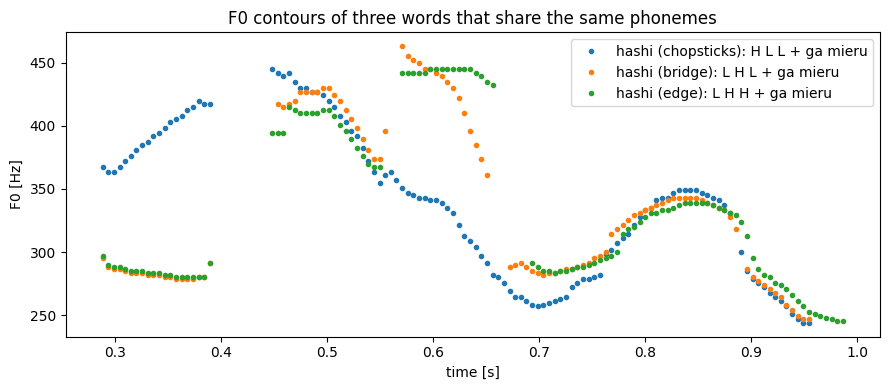

In [61]:
# アクセントの違いが音の高さ（基本周波数）の動きとして現れることを、合成音声で確かめる
import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import IPython.display as ipd

def hts_tts(text):
    # Open JTalkに付属する統計的パラメトリック合成（HMM音声合成）で、文章を波形にする
    wav, sr = pyopenjtalk.tts(text)
    return (wav / 32768).astype(np.float32), sr

def f0_contour(wav, sr):
    # 基本周波数（声の高さ）の時間変化を推定する　声帯が振動していない区間はNaNになる
    f0, _, _ = librosa.pyin(wav, fmin=80, fmax=600, sr=sr, frame_length=2048, hop_length=256)
    return np.arange(len(f0)) * 256 / sr, f0

plt.figure(figsize=(9, 4))
for word, label in [("箸", "hashi (chopsticks): H L L"), ("橋", "hashi (bridge): L H L"), ("端", "hashi (edge): L H H")]:
    text = word + "が見える"
    wav, sr = hts_tts(text)
    t, f0 = f0_contour(wav, sr)
    plt.plot(t, f0, ".", label=label + " + ga mieru")
    print(f"{text}: {accent_pattern(text)}  長さ {len(wav) / sr:.2f} 秒")
    sf.write("accent_" + label.split(":")[1].replace(" ", "") + ".wav", wav, sr)
    ipd.display(ipd.Audio(wav, rate=sr))
plt.xlabel("time [s]")
plt.ylabel("F0 [Hz]")
plt.title("F0 contours of three words that share the same phonemes")
plt.legend()
plt.tight_layout()
plt.show()

### 結果の読み方

横軸は時刻、縦軸は基本周波数であり、点の無い部分は声帯が振動していない区間（子音の `sh` など）である

3つの文は音素の並びが同じなので、違いは高さの動きだけに現れる
- 0.3〜0.4秒付近（最初のモーラ「は」）
  - 「箸」（青）だけが高い（370〜420Hz）　「橋」（橙）と「端」（緑）は低い（約290Hz）
  - 前処理の結果（箸は高で始まり、橋と端は低で始まる）と一致している
- 0.45〜0.65秒付近（「しが」）
  - 「箸」は、ここから0.7秒にかけて下がり続ける（高低低）
  - 「橋」は、高い位置（420〜460Hz）に上がった後、0.6秒付近から急に下がる（「し」が高く「が」が低い、低高低）
  - 「端」は、高い位置（約440Hz）を0.65秒付近まで保つ（「し」も「が」も高い、低高高）
- 0.7秒以降（「見える」）は、3つともほぼ同じ動きになる

つまり、テキストの前処理が出した「H」と「L」の並びが、音響モデルを通って、基本周波数の上がり下がりとして実現されている
- 逆に言えば、前処理がアクセント型を誤ると、別の単語に聞こえる音声がそのまま作られる
- 実際の高さの動きは、階段状ではなく滑らかである　高い位置も文の後ろへ行くほど少しずつ下がっていく

3つの音声は `accent_HLL.wav`、`accent_LHL.wav`、`accent_LHH.wav` として保存している
- 聴き比べて、どれが「箸」「橋」「端」に聞こえるかを確かめること
- 自分の話す方言のアクセントと違う場合は、どこが違うかを図と照らし合わせてみるとよい

## なぜメルスペクトログラムから波形を作るのは難しいか

メルスペクトログラムを作るとき、2つの情報を捨てている
1. **位相**: STFTの結果は複素数であるが、その絶対値（振幅）だけを使っている
2. **周波数の細かさ**: メルフィルタバンクで、数百本の周波数ビンを数十本にまとめている

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-lost-information.png" width=740>

上の図は、波形からメルスペクトログラムを作る流れと、途中で捨てられる情報である
- ボコーダは、この流れを逆向きにたどり、捨てられた2つの情報を補わなければならない

特に問題になるのは位相である
- 振幅は「その時刻、その周波数の成分がどれだけ強いか」、位相は「その成分の波がどの位置から始まるか」を表す
- 「STFTの逆変換」の節で見たとおり、位相があればISTFTで波形に戻せるが、振幅だけでは戻せない

位相を適当に決めればよさそうに思えるが、そうはいかない
- STFTの窓は互いに重なっている（ずらし幅は窓幅の1/4など）
- 隣り合うフレームは同じ波形の重なった部分を見ているので、位相は互いに整合していなければならない
- 整合しない位相でISTFTを行うと、重なった部分で波が打ち消し合い、振幅まで変わってしまう

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-phase-consistency.png" width=740>

上の図は、隣り合う2つのフレームを重ねて足す様子である
- 位相が整合していれば（左）、重なる部分で2つの波が一致し、なめらかにつながる
- 整合していなければ（右）、重なる部分で波が打ち消し合い、与えた振幅とは違う波形になる

まず、位相の扱いを変えて波形に戻すとどうなるかを確かめる
- 正しい位相を使う
- 位相をすべて0にする
- 位相を乱数にする

In [62]:
# 音声を読み込み、STFTの振幅と位相に分け、位相の扱いを変えて波形に戻す
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import IPython.display as ipd

GL_SR, GL_NFFT, GL_HOP = 16000, 1024, 256
speech, _ = librosa.load(librosa.ex("libri1"), sr=GL_SR, duration=5.0)   # librosa付属の英語読み上げ音声の先頭5秒

D = librosa.stft(speech, n_fft=GL_NFFT, hop_length=GL_HOP)
S, phase = np.abs(D), np.angle(D)             # 振幅と位相
print("STFTの形状 [周波数ビン, フレーム]:", D.shape)

def spec_error(S_target, wav):
    # 波形をもう一度STFTし、その振幅が目標の振幅からどれだけずれているかを相対誤差で測る
    S_hat = np.abs(librosa.stft(wav, n_fft=GL_NFFT, hop_length=GL_HOP))
    n = min(S_target.shape[1], S_hat.shape[1])
    return np.linalg.norm(S_target[:, :n] - S_hat[:, :n]) / np.linalg.norm(S_target[:, :n])

rng = np.random.default_rng(0)
recon = {
    "true phase": librosa.istft(S * np.exp(1j * phase), hop_length=GL_HOP, length=len(speech)),
    "zero phase": librosa.istft(S.astype(complex), hop_length=GL_HOP, length=len(speech)),
    "random phase": librosa.istft(S * np.exp(2j * np.pi * rng.random(S.shape)), hop_length=GL_HOP, length=len(speech)),
}
for name, y in recon.items():
    print(f"{name:13s} 振幅スペクトログラムの相対誤差 {spec_error(S, y):.3f}")
    sf.write("gl_" + name.replace(" ", "_") + ".wav", y, GL_SR)
    ipd.display(ipd.Audio(y, rate=GL_SR))

STFTの形状 [周波数ビン, フレーム]: (513, 313)
true phase    振幅スペクトログラムの相対誤差 0.000


zero phase    振幅スペクトログラムの相対誤差 0.895


random phase  振幅スペクトログラムの相対誤差 0.635


- 正しい位相を使えば、振幅スペクトログラムの相対誤差は0であり、元の波形がそのまま復元される
- 位相を0や乱数にすると、相対誤差は0.9や0.6といった大きな値になる
  - 与えた振幅と、できた波形をSTFTし直して得た振幅が、一致していない
  - これが「整合しない位相では振幅まで変わる」ということである

3つの音声は `gl_true_phase.wav`、`gl_zero_phase.wav`、`gl_random_phase.wav` として保存している
- 再生して、位相を誤った音声がどのように聞こえるか（何を話しているかは聞き取れるか、音色はどう変わるか）を、自分の耳で確かめること

## Griffin-Lim法

**Griffin-Lim法**は、振幅だけから、整合した位相を反復計算で推定する方法である

考え方は次のとおりである
- 任意の複素数の行列が、ある波形のSTFTになっているとは限らない（窓の重なりによる制約がある）
- 求めたいのは、「振幅が与えられた $S$ に一致する」と「実在する波形のSTFTである」の2つの条件を同時に満たすものである
- そこで、2つの条件を交互に満たすように修正を繰り返す

1. 位相を乱数で初期化する
2. 振幅 $S$ と現在の位相から、ISTFTで波形を作る
3. その波形をSTFTする（これは必ず「実在する波形のSTFT」である）
4. 3.の結果から位相だけを取り出し、振幅は $S$ に戻す
5. 2.〜4.を繰り返す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-griffin-lim-loop.png" width=700>

上の図は、この反復を輪として描いたものである
- 上半分で「実在する波形」に直し、下半分で位相だけを取り出して振幅を目標の $S$ に戻す

この章の「STFTの逆変換」の節にある `griffinlim` 関数が、この手順の実装である

ここでは、同じ手順を、反復ごとの誤差を記録する形で書き直し、反復回数による違いを調べる

反復   1 回  振幅スペクトログラムの相対誤差 0.381


反復  10 回  振幅スペクトログラムの相対誤差 0.222


反復 100 回  振幅スペクトログラムの相対誤差 0.067


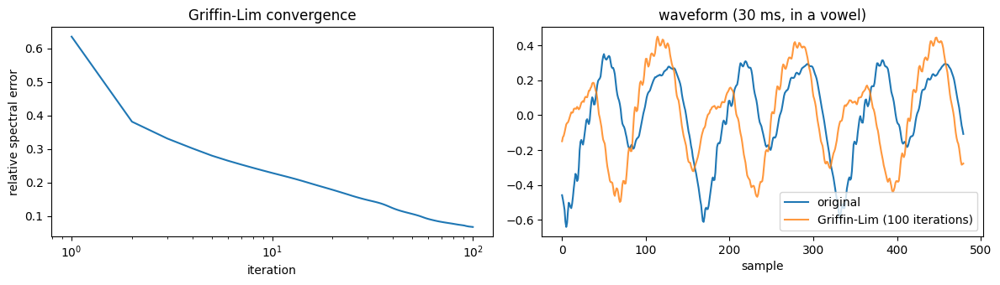

In [63]:
# Griffin-Lim法を実装し、反復回数と誤差の関係を調べる
def griffin_lim(S, n_iter, seed=0):
    # S: 振幅スペクトログラム　乱数の位相から始め、「波形に戻す → STFTし直す → 位相だけ採用する」を繰り返す
    rng = np.random.default_rng(seed)
    angles = np.exp(2j * np.pi * rng.random(S.shape))
    errors = []
    for _ in range(n_iter):
        y = librosa.istft(S * angles, hop_length=GL_HOP)                 # 振幅は目標、位相は現在の推定
        rebuilt = librosa.stft(y, n_fft=GL_NFFT, hop_length=GL_HOP)      # 実在する波形のSTFTに直す
        errors.append(np.linalg.norm(S - np.abs(rebuilt)) / np.linalg.norm(S))
        angles = np.exp(1j * np.angle(rebuilt))                          # 位相だけを取り出して次の推定にする
    return librosa.istft(S * angles, hop_length=GL_HOP), errors

gl_wavs = {}
for n in [1, 10, 100]:
    gl_wavs[n], gl_errors = griffin_lim(S, n)
    print(f"反復 {n:3d} 回  振幅スペクトログラムの相対誤差 {spec_error(S, gl_wavs[n]):.3f}")
    sf.write(f"gl_iter{n}.wav", gl_wavs[n], GL_SR)
    ipd.display(ipd.Audio(gl_wavs[n], rate=GL_SR))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(range(1, len(gl_errors) + 1), gl_errors)
ax[0].set_xscale("log")
ax[0].set_xlabel("iteration")
ax[0].set_ylabel("relative spectral error")
ax[0].set_title("Griffin-Lim convergence")
rms = librosa.feature.rms(y=speech, frame_length=1024, hop_length=256)[0]
seg_start = int(np.argmax(rms)) * 256          # 最も音の大きい位置（母音の中）
seg = slice(seg_start, seg_start + 480)       # そこから30ミリ秒ぶんを拡大する
ax[1].plot(speech[seg], label="original")
ax[1].plot(gl_wavs[100][seg], label="Griffin-Lim (100 iterations)", alpha=0.8)
ax[1].set_xlabel("sample")
ax[1].set_title("waveform (30 ms, in a vowel)")
ax[1].legend()
plt.tight_layout()
plt.show()

- 左の図: 反復を重ねるほど、振幅スペクトログラムの誤差は小さくなる（手元の実行では、1回で0.38、10回で0.22、100回で0.07）
  - 最初の数回で大きく下がり、その後は減り方が遅くなる（横軸が対数であることに注意する）　100回でも0にはならない
- 右の図: 母音の部分の波形を30ミリ秒ぶん拡大したものである
  - 元の波形もGriffin-Lim法の波形も、同じ周期（約160サンプル、基本周波数にして約100Hz）で繰り返している　声の高さは再現されている
  - しかし、山と谷の位置がずれており、1周期の中の形も違う　波形としては一致していない
  - 振幅スペクトログラムが同じになる波形は1つではない　求まるのは「振幅が合う波形の1つ」であって、元の波形ではない
- 波形が違っても、振幅スペクトログラムが近ければ、人には似た音に聞こえる　人の聴覚は、位相の違いには比較的鈍感である
  - 波形どうしの二乗誤差が、音の近さの指標として適さない理由でもある

反復1回、10回、100回の音声を `gl_iter1.wav`、`gl_iter10.wav`、`gl_iter100.wav` として保存している
- 聴き比べて、誤差の数値（0.38、0.22、0.07）の違いが、聞こえ方のどのような違いに対応するかを確かめること
- 100回のものと元の音声を比べて、違いが聞き取れるかどうかも確かめるとよい

### メルスペクトログラムからの復元

音声合成の音響モデルが出力するのは、振幅スペクトログラムではなくメルスペクトログラムである
- メルフィルタバンクでまとめた周波数ビンを、元の本数に戻す必要がある
- ここでは、フィルタバンクの行列の疑似逆行列を使って近似的に戻し、その後にGriffin-Lim法を適用する

メルスペクトログラムの形状: (80, 313)
メルから戻した振幅の相対誤差 0.325
メル → Griffin-Lim 100回  元の振幅スペクトログラムに対する相対誤差 0.350


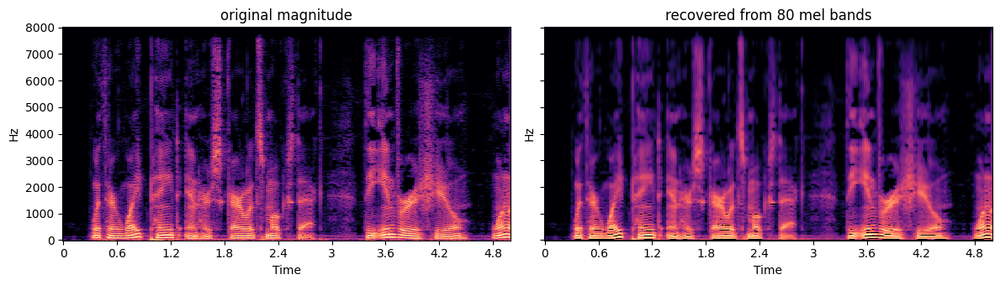

In [64]:
# メルスペクトログラムから波形を作る: メル → 線形周波数の振幅（近似） → Griffin-Lim法
mel_basis = librosa.filters.mel(sr=GL_SR, n_fft=GL_NFFT, n_mels=80)      # [80, 513] のメルフィルタバンク
mel = mel_basis @ S                                                      # 513本の周波数ビンを80本にまとめる
S_from_mel = np.maximum(np.linalg.pinv(mel_basis) @ mel, 0)              # 疑似逆行列で513本に戻す（完全には戻らない）
print("メルスペクトログラムの形状:", mel.shape)
print(f"メルから戻した振幅の相対誤差 {np.linalg.norm(S - S_from_mel) / np.linalg.norm(S):.3f}")

mel_wav, _ = griffin_lim(S_from_mel, 100)
print(f"メル → Griffin-Lim 100回  元の振幅スペクトログラムに対する相対誤差 {spec_error(S, mel_wav):.3f}")
sf.write("gl_from_mel.wav", mel_wav, GL_SR)
ipd.display(ipd.Audio(mel_wav, rate=GL_SR))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for a, M, title in [(ax[0], S, "original magnitude"), (ax[1], S_from_mel, "recovered from 80 mel bands")]:
    librosa.display.specshow(librosa.amplitude_to_db(M, ref=np.max), sr=GL_SR, hop_length=GL_HOP,
                             x_axis="time", y_axis="hz", ax=a)
    a.set_title(title)
plt.tight_layout()
plt.show()

- 図の左が元の振幅スペクトログラム、右が80本のメルから戻したものである
  - 左には、細い横縞が何本も等間隔に並んでいる　これは声の**倍音**（基本周波数の整数倍の成分）である
  - 右では、低い周波数（およそ1kHz以下）の縞は残っているが、それより上では縞がつぶれて、ぼやけた帯になっている
  - メルフィルタは高い周波数ほど幅が広いので、隣り合う倍音が1つのフィルタにまとめられ、区別できなくなる
- メルから戻した時点で、振幅の相対誤差が0.33ある
- その後にGriffin-Lim法を100回繰り返しても、元の振幅に対する誤差は0.35であり、減らない
  - 先ほど100回の反復で0.07まで下がったのは、正しい振幅が与えられていたからである
  - ここでの誤差は、位相の問題ではなく、振幅の情報そのものが足りないことによる　反復を増やしても回復しない

`gl_from_mel.wav` として保存しているので、`gl_iter100.wav`（正しい振幅から復元したもの）と聴き比べること

Griffin-Lim法は、学習が不要で仕組みも単純であるが、失われた情報を補うことはできない

## ニューラルボコーダ

そこで、メルスペクトログラムから波形への変換そのものを、ニューラルネットワークに学習させる　これを**ニューラルボコーダ**と呼ぶ
- 大量の音声について、「メルスペクトログラム → 元の波形」の対応を学習する
- 失われた位相や高域の細かな構造を、「人の声らしい波形」の知識で補う　これは生成モデルの仕事である

代表的な方式は次のとおりである

|方式|波形の作り方|特徴|
|-|-|-|
|自己回帰型（WaveNetなど）|1サンプルずつ、過去のサンプルを条件に生成|高音質であるが、1秒に数万回の推論が必要で遅い|
|GAN型（HiFi-GANなど）|転置畳み込みで段階的に引き伸ばし、全サンプルを一度に生成|識別器で本物らしさを学習する　高速で、広く使われている|
|拡散モデル型|雑音から始めて、少しずつ波形に近づける|高音質　反復の回数ぶん時間がかかる|

- GANの学習については「GAN」の章を、拡散モデルについては「Diffusion」の章を参照すること
- この章の最後で扱うDemucsが、波形を直接入出力する畳み込みネットワークであるのと同じ系統の技術である

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-gan-vocoder.png" width=720>

上の図は、GAN型のボコーダの学習の仕組みである
- 生成器（ボコーダ）はメルスペクトログラムから波形を作り、識別器は本物の波形と見分けようとする　生成器は、見分けられない波形を作るように学習する

### Griffin-Lim法とニューラルボコーダを比べる

公開されているGAN型のボコーダ（HiFi-GAN、`microsoft/speecht5_hifigan`）を使い、**同じメルスペクトログラム**から波形を作って、Griffin-Lim法と比べる
- このボコーダは、16kHz、80次元のメルスペクトログラム（窓幅1024、ずらし幅256）を入力とするように学習されている
- 学習時と同じ形式のメルスペクトログラムを計算するために、対になっている特徴抽出器 `SpeechT5FeatureExtractor` を使う
  - ボコーダは、学習時と違う設定（メルフィルタの本数、周波数範囲、対数の取り方）で作ったメルスペクトログラムを入れると、正しく働かない
- 入力する音声は、上で使ったものと同じ5秒の録音である　ボコーダが学習時に見ていない話者の声である

preprocessor_config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 50.7MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

ボコーダのパラメータ数: 12656257
メルスペクトログラムの形状: (313, 80)


model.safetensors: reconstructing file:   0%|          |  0.00B / 50.6MB            

model.safetensors: downloading bytes:           |  0.00B            

Griffin-Lim (100 iterations) 振幅スペクトログラムの相対誤差 0.512  メルの誤差 0.92 dB  計算時間 5.52 秒


HiFi-GAN                     振幅スペクトログラムの相対誤差 0.335  メルの誤差 1.99 dB  計算時間 2.69 秒


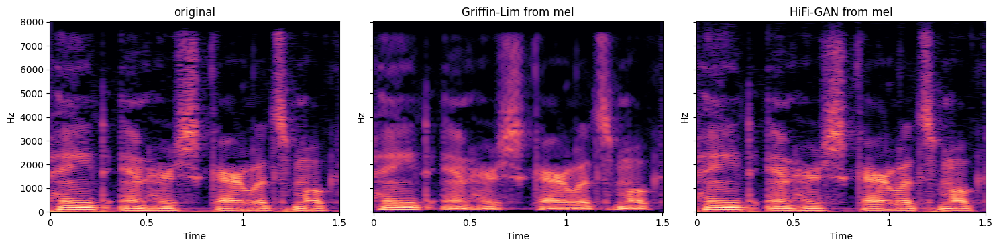

In [65]:
# 同じメルスペクトログラムから、Griffin-Lim法とニューラルボコーダ（HiFi-GAN）で波形を作って比べる
import time
import torch
from transformers import SpeechT5FeatureExtractor, SpeechT5HifiGan

voc_fe = SpeechT5FeatureExtractor.from_pretrained("microsoft/speecht5_tts")        # このボコーダが学習時に使った形式のメルを計算する
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan").eval()
print("ボコーダのパラメータ数:", sum(p.numel() for p in vocoder.parameters()))

voc_mel = np.array(voc_fe(audio_target=speech, sampling_rate=GL_SR)["input_values"][0])    # [フレーム, 80]、常用対数のメルスペクトログラム
print("メルスペクトログラムの形状:", voc_mel.shape)

t0 = time.time()
with torch.no_grad():
    hifi_wav = vocoder(torch.tensor(voc_mel)).numpy()
t_hifi = time.time() - t0

# 同じメルスペクトログラムを、疑似逆行列で線形周波数に戻してからGriffin-Lim法にかける
t0 = time.time()
S_voc = np.maximum(np.linalg.pinv(voc_fe.mel_filters.T) @ (10 ** voc_mel.T), 0)
gl_voc_wav, _ = griffin_lim(S_voc, 100)
t_gl = time.time() - t0

def mel_error_db(wav):
    # 作った波形のメルスペクトログラムが、入力したメルスペクトログラムから平均何dBずれているか
    m = np.array(voc_fe(audio_target=wav, sampling_rate=GL_SR)["input_values"][0])
    n = min(len(m), len(voc_mel))
    return 20 * np.abs(m[:n] - voc_mel[:n]).mean()

for name, wav, sec in [("Griffin-Lim (100 iterations)", gl_voc_wav, t_gl), ("HiFi-GAN", hifi_wav, t_hifi)]:
    print(f"{name:28s} 振幅スペクトログラムの相対誤差 {spec_error(S, wav):.3f}  メルの誤差 {mel_error_db(wav):.2f} dB  計算時間 {sec:.2f} 秒")
    sf.write("voc_" + name.split()[0] + ".wav", wav, GL_SR)
    ipd.display(ipd.Audio(wav, rate=GL_SR))

# 1秒目から1.5秒ぶんを、周波数方向に細かいスペクトログラムで比べる
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for a, (name, wav) in zip(ax, [("original", speech), ("Griffin-Lim from mel", gl_voc_wav), ("HiFi-GAN from mel", hifi_wav)]):
    M = librosa.amplitude_to_db(np.abs(librosa.stft(wav[GL_SR:int(2.5 * GL_SR)], n_fft=GL_NFFT, hop_length=64)), ref=np.max)
    librosa.display.specshow(M, sr=GL_SR, hop_length=64, x_axis="time", y_axis="hz", ax=a)
    a.set_title(name)
plt.tight_layout()
plt.show()

### 結果の読み方

図は、1秒目から1.5秒ぶんのスペクトログラムである（左から、元の音声、Griffin-Lim法、HiFi-GAN）

- Griffin-Lim法（中央）では、先ほどと同じく、およそ1〜2kHzより上の倍音の縞がつぶれている
- HiFi-GAN（右）では、高い周波数まで細い縞が現れており、元の音声（左）と似た模様になっている
  - 入力したメルスペクトログラムは、中央と同じものである　つまり、縞の情報は入力には含まれていない
  - ボコーダは、「このような包絡を持つ人の声なら、倍音はこう並ぶはずだ」という知識を学習しており、それに基づいて細部を**生成**している
- 計算時間は、HiFi-GANのほうが短い（1回の順伝播で全サンプルを出力する）

2つの数値は、逆の順位を付けている
- 元の振幅スペクトログラムに対する相対誤差は、HiFi-GANのほうが小さい（手元の実行では、0.34に対してGriffin-Lim法は0.51）
- 入力したメルスペクトログラムとの誤差は、Griffin-Lim法のほうが小さい（同0.9dBに対してHiFi-GANは2.0dB）
  - Griffin-Lim法は、与えられたメルに振幅を合わせることだけを目標にしている
  - HiFi-GANは、メルに厳密に合わせることよりも、人の声らしい波形を出すことを学習している（識別器をだますように学習するGANの性質である）
- **「入力にどれだけ忠実か」と「本物の音声にどれだけ近いか」は、別のことである**
  - 1つの数値で音質を表すことはできない　この点は、後の評価の小節でもう一度扱う

`voc_Griffin-Lim.wav` と `voc_HiFi-GAN.wav` として保存している
- 図に見えた倍音の違いが、どのような聞こえ方の違いになるかを、聴いて確かめること

生成された細部は、元の音声と同じとは限らない
- 図をよく見ると、HiFi-GANの縞は元の音声と位置や濃さが少し違う
- ボコーダが学習時に見ていない種類の声（歌声、子どもの声、他の言語）では、もっともらしいが誤った細部が作られることがある

## エンドツーエンド型と音声トークン言語モデル型

音響モデルとボコーダを別々に学習すると、音響モデルの出力するメルスペクトログラム（少しぼやけている）と、ボコーダが学習時に見たメルスペクトログラム（本物）の間にずれが生じる

**エンドツーエンド型**は、文字列（または音素列）から波形までを1つのモデルとしてまとめて学習する
- 代表例のVITSは、変分オートエンコーダ（AutoEncoderの章を参照）、継続長の予測、GAN型の波形生成を1つにまとめている
- 中間表現は、人が決めたメルスペクトログラムではなく、学習で得られる潜在変数になる

もう1つの流れが、**音声を離散的なトークンの列として扱い、言語モデルで生成する**方式である
1. **ニューラル音声コーデック**（neural audio codec）で、波形を離散的なトークンの列に変換する
  - エンコーダで圧縮し、ベクトル量子化で符号帳の番号に置き換える（AutoEncoderの章のVQ-VAEと同じ考え方）　デコーダで波形に戻せる
  - 1秒の音声が、数十〜数百個の整数の列になる
2. 文章のトークン列を条件として、音声のトークン列を、Transformerの言語モデルで1つずつ予測する
  - 文章生成のGPTと同じ「次のトークンの予測」である（「J-NLP-3-Transformer」「J-NLP-6-GPT-full」の章を参照）
3. 生成したトークン列を、コーデックのデコーダで波形に戻す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-codec-tokens.png" width=720>

上の図は、ニューラル音声コーデックの働きである
- 波形が整数の列（音声トークン）に変換され、デコーダで波形に戻せる

- 音声合成が、文章生成と同じ枠組みに乗ることになる　大規模言語モデルの学習や推論の技術をそのまま使える
- 次のトークンを確率的に選ぶので、同じ文章でも毎回少し違う音声になる　笑い声やためらいのような、文字に書かれない表現も生成されうる
- 一方で、言語モデルと同じ弱点も持つ　文章に無い言葉を話す、一部を飛ばす、同じ部分を繰り返す、といった誤りが起こりうる
- この方式は、数秒の音声を「続きを書かせるための書き出し」として与えるだけで、その声に似せた音声を生成できる
  - 利便性が高い反面、後で述べる悪用の危険と直結している

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-three-architectures.png" width=760>

上の図は、ここまでに出てきた3つの構成を並べたものである
- 違いは、記号列と波形の間をいくつのモデルで、どのような中間表現を経てつなぐかにある

## 実習: 公開モデルで文章を音声にする

### エンドツーエンド型（VITS）による英語の合成

`facebook/mms-tts-eng` を使う
- 1000を超える言語の音声技術を対象とするMMS（Massively Multilingual Speech）プロジェクトの、英語の音声合成モデルである
- 構成はVITSであり、文字列から16kHzの波形を直接出力する（前処理は小文字化などの簡単なものだけで、音素への変換は行わない）
- モデルは小さく、T4でもCPUでも、音声の長さより短い時間で合成できる

音は聴けばわかるが、ここでは目でも確かめられるように、合成した音声のメルスペクトログラムを表示する
- 話す速さの設定（`speaking_rate`）と乱数のシードを変えて、同じ文章を4通りに合成する

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/413 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  145MB            

...

入力の文字数: 65  モデルに渡す記号の数: 128
サンプリング周波数 16000 Hz  波形の形状 (81664,)  長さ 5.10 秒  生成時間 0.21 秒


rate 1.0, seed 0  長さ 5.10 秒


rate 0.7, seed 0  長さ 6.62 秒


rate 1.3, seed 0  長さ 4.18 秒


rate 1.0, seed 1  長さ 4.80 秒


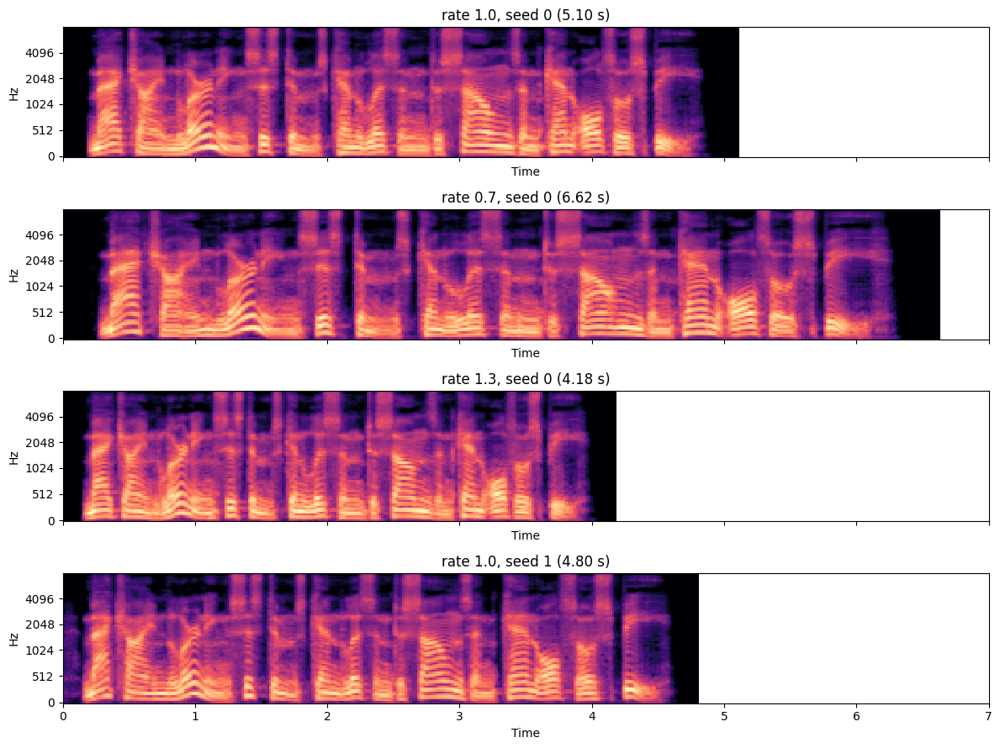

In [66]:
# 英語のエンドツーエンド型音声合成モデル（VITS）で文章を音声にする
import time
import torch
from transformers import VitsModel, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tts_name = "facebook/mms-tts-eng"
tts_tok = AutoTokenizer.from_pretrained(tts_name)
tts_model = VitsModel.from_pretrained(tts_name).to(device).eval()
TTS_SR = tts_model.config.sampling_rate

def synthesize(text, seed=0, rate=1.0):
    # 文章を波形（numpy配列）にする　このモデルは生成に乱数を使うので、シードを固定する
    torch.manual_seed(seed)
    tts_model.speaking_rate = rate
    inputs = tts_tok(text, return_tensors="pt").to(device)
    with torch.no_grad():
        return tts_model(**inputs).waveform[0].cpu().numpy()

tts_text = "Machine learning systems can listen to sounds and can also speak."
print("入力の文字数:", len(tts_text), " モデルに渡す記号の数:", len(tts_tok(tts_text).input_ids))
synthesize(tts_text)                       # 1回目はGPUの準備が入るので、時間の計測から外す
t0 = time.time()
tts_wav = synthesize(tts_text)
print(f"サンプリング周波数 {TTS_SR} Hz  波形の形状 {tts_wav.shape}  長さ {len(tts_wav) / TTS_SR:.2f} 秒  生成時間 {time.time() - t0:.2f} 秒")
sf.write("tts_en.wav", tts_wav, TTS_SR)
ipd.display(ipd.Audio(tts_wav, rate=TTS_SR))

# 話す速さ（speaking_rate）とシードを変えて合成し、メルスペクトログラムを同じ時間軸で並べる
variants = [("rate 1.0, seed 0", 1.0, 0), ("rate 0.7, seed 0", 0.7, 0), ("rate 1.3, seed 0", 1.3, 0), ("rate 1.0, seed 1", 1.0, 1)]
fig, ax = plt.subplots(len(variants), 1, figsize=(12, 9), sharex=True)
for a, (title, rate, seed) in zip(ax, variants):
    w = synthesize(tts_text, seed=seed, rate=rate)
    print(f"{title}  長さ {len(w) / TTS_SR:.2f} 秒")
    M = librosa.power_to_db(librosa.feature.melspectrogram(y=w, sr=TTS_SR, n_fft=1024, hop_length=256, n_mels=80), ref=np.max)
    librosa.display.specshow(M, sr=TTS_SR, hop_length=256, x_axis="time", y_axis="mel", ax=a)
    a.set_title(f"{title} ({len(w) / TTS_SR:.2f} s)")
    a.set_xlim(0, 7)
    ipd.display(ipd.Audio(w, rate=TTS_SR))
plt.tight_layout()
plt.show()

- 5秒ほどの音声が、T4でも1秒以内に生成される
- 出力は1次元の配列（波形）である　`tts_en.wav` に保存しているので、ダウンロードして聴くこともできる

4つのメルスペクトログラムを見比べる
- どれも、縦に区切られたかたまり（単語や音節）が同じ順に並んでおり、同じ文章を読んでいることがわかる
- `speaking_rate` を0.7にすると全体が横に引き伸ばされ（5.1秒 → 6.6秒）、1.3にすると縮む（4.2秒）
  - 模様の形は変わらず、時間方向の長さだけが変わっている　周波数方向（声の高さ）は変わっていない
  - 録音を早回しにすると声が高くなるが、それとは違う　継続長の予測値に係数を掛けているだけであり、「短い入力を長い出力に引き伸ばす」部分を外から操作している
- シードを変えると（4段目）、同じ速さの設定でも長さが変わり（5.1秒 → 4.8秒）、縞の曲がり方（声の高さの動き）も少し違う
  - 同じ文章に対する無数の正解の中から、乱数で1つを選んでいる（一対多の対応）
- 倍音の縞がはっきり見える　ボコーダにあたる部分が、細部まで生成している

### 合成と認識の往復

合成した音声を音声認識モデルに入力し、元の文章が戻ってくるかを調べる
- 認識には、仕組みの違う2つのモデルを使う
  - Whisperの小さなモデル（`openai/whisper-base`）: 注意機構つきエンコーダ・デコーダ（「N-アプリ-transformer」の章を参照）
  - wav2vec 2.0（`facebook/wav2vec2-base-960h`）: 「音声認識」の節で使ったCTCのモデル
- 元の文章を正解、認識結果を仮説として、単語誤り率（WER）を計算する
  - 計算は「音声認識」の節の `edit_distance` と同じである　この節だけを実行しても動くように、ここでも定義している

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-roundtrip.png" width=720>

上の図は、往復の流れである
- 合成した音声を2つの認識モデルに通し、それぞれの認識結果を元の文章と比べる

この往復は、双方向に使える
- **音声合成の評価**: 聞き取れる音声になっているかを、人が聴かずに数値で調べられる
- **音声認識の評価と学習**: 正解の文章がわかっている音声を、好きなだけ作れる
  - 「音声認識」の節のCTCモデルの学習データや、雑音や話速を変えた評価データを合成で用意することができる
  - ただし、合成音声は実際の人の声より変化が乏しいので、合成音声だけで学習や評価をすると、実際の音声での性能を見誤る

2つの認識モデルを使うのは、誤りの原因を切り分けるためである
- 2つのモデルが同じ箇所を誤れば、合成音声の側に問題がある可能性が高い
- 片方だけが誤れば、その認識モデルの側の問題である可能性が高い

In [67]:
# 合成した音声を2種類の音声認識モデルに通し、元の文章と比べる
from transformers import pipeline, Wav2Vec2ForCTC, Wav2Vec2Processor

asr = pipeline("automatic-speech-recognition", model="openai/whisper-base", device=0 if torch.cuda.is_available() else -1)
rt_proc = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")       # 「音声認識」の節で使ったCTCモデルと同じもの
rt_ctc = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h").to(device).eval()

def whisper_text(wav):
    return asr({"raw": wav, "sampling_rate": TTS_SR}, generate_kwargs={"language": "en", "task": "transcribe"})["text"].strip()

def ctc_text(wav):
    inputs = rt_proc(wav, sampling_rate=TTS_SR, return_tensors="pt").input_values.to(device)
    with torch.no_grad():
        ids = rt_ctc(inputs).logits[0].argmax(-1)
    return rt_proc.decode(ids).lower()          # 貪欲復号（連続する同じ記号をまとめ、blankを除く）

def normalize_text(s):
    # 大文字小文字と句読点の違いを誤りに数えないよう、英小文字と数字と空白だけを残す
    return " ".join("".join(ch if ch.isalnum() else " " for ch in s.lower()).split())

def word_errors(ref, hyp):
    # 単語単位の編集距離（「音声認識」の節の edit_distance と同じ計算）
    ref, hyp = ref.split(), hyp.split()
    d = list(range(len(hyp) + 1))
    for i in range(1, len(ref) + 1):
        prev, d[0] = d[0], i
        for j in range(1, len(hyp) + 1):
            prev, d[j] = d[j], min(d[j] + 1, d[j - 1] + 1, prev + (ref[i - 1] != hyp[j - 1]))
    return d[-1], len(ref)

assert word_errors("a b c", "a x c d") == (2, 3)

sentences = [
    "Machine learning systems can listen to sounds and can also speak.",
    "The factory monitors every motor with a small microphone.",
    "Please confirm the delivery address before four thirty.",
    "She sells seashells by the seashore.",
    "The pump started to make an unusual noise yesterday.",
    "Doctor Smith will arrive at the station at nine.",
]
errors = {"Whisper": 0, "wav2vec 2.0": 0}
total = 0
for text in sentences:
    wav = synthesize(text)
    ref = normalize_text(text)
    total += len(ref.split())
    print("入力       :", text)
    for name, recognize in [("Whisper", whisper_text), ("wav2vec 2.0", ctc_text)]:
        hyp = recognize(wav)
        e, n = word_errors(ref, normalize_text(hyp))
        errors[name] += e
        print(f"{name:11s}: {hyp}  （誤り {e}/{n} 語）")
for name in errors:
    print(f"往復のWER（{name}）= {errors[name] / total:.3f}")

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  290MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.81k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


入力       : Machine learning systems can listen to sounds and can also speak.


[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Whisper    : Matching learning systems can listen to sounds and can also be.  （誤り 2/11 語）
wav2vec 2.0: matchim learning systems can listen to sounds and can also spe  （誤り 2/11 語）
入力       : The factory monitors every motor with a small microphone.
Whisper    : The factory monitors every motor with a small microphone.  （誤り 0/9 語）
wav2vec 2.0: the factory monitors every moter with a small microphon  （誤り 2/9 語）
入力       : Please confirm the delivery address before four thirty.
Whisper    : Please confirm the delivery address before 430.  （誤り 2/8 語）
wav2vec 2.0: these confirm the delivery address before for thirty  （誤り 2/8 語）
入力       : She sells seashells by the seashore.
Whisper    : G cell C shows by the C-shore.  （誤り 6/6 語）
wav2vec 2.0: ge sells sea shows by te sea shore  （誤り 6/6 語）
入力       : The pump started to make an unusual noise yesterday.
Whisper    : The pump started to make an unusual noise yesterday.  （誤り 0/9 語）
wav2vec 2.0: the pump started to make an unusual noise yesterday

### 結果の読み方

手元の実行では、往復のWERは、Whisperで0.23、wav2vec 2.0で0.21であった（6文、52語）

誤りの中身を見ると、性質の違うものが混ざっている
- **表記の違い**（Whisperだけ）: 「four thirty」が「430」、「Doctor」が「Dr.」、「nine」が「9」と書かれた
  - 音声としては正しく伝わっている　表記の違いが誤りに数えられただけである
  - wav2vec 2.0は文字を1つずつ出力するので、「doctor」「nine」とそのまま綴っており、誤りにならない
  - WERを計算する前の正規化（数字、略語、大文字小文字、句読点の扱い）で結果が変わる例である
- **綴りの誤り**（wav2vec 2.0だけ）: 「motor」が「morter」、「microphone」が「mikraphon」、「four」が「for」、「Please」が「these」と書かれた
  - 多くは、音としては近い（four と for は同じ発音である）　CTCのモデルは言語モデルを持たないので、聞こえたとおりに綴って誤る（「音声認識」の節で見たとおりである）
  - Whisperは、デコーダが言語モデルの役割を兼ねるので、これらの箇所では正しい綴りを出している
- **両方が誤った箇所**: 文頭の「Machine」（Matching / matchim）、文末の「speak」（be / spe）、早口言葉の文（She sells seashells ...）
  - 仕組みの違う2つのモデルが同じ箇所を誤っているので、合成音声の側の問題と考えられる
  - 文頭と文末、そして似た音が続く早口言葉で誤りが起きている　実際にどのような音になっているかは、保存した音声を聴いて確かめるとよい

往復による評価の限界も理解しておく
- 測っているのは「聞き取れるか」（明瞭性）だけであり、自然に聞こえるかはわからない
- 認識モデルは、不明瞭な音を文脈から補って正しく書き起こすことがある　この場合、合成の誤りは見逃される
- 認識モデル自身の誤りも、合成の誤りとして数えられる　上のように複数の認識モデルを使っても、完全には切り分けられない

### 日本語の合成: 3つの方式を比べる

日本語の文章を、性質の違う3つの方式で合成する

|方式|モデル|テキストの前処理|波形の作り方|
|-|-|-|-|
|統計的パラメトリック合成（2000年代〜）|Open JTalk付属のHMM音声合成|Open JTalk（読みとアクセントを明示的に推定）|音素ごとの統計モデルが出力した音響パラメータから、信号処理で波形を作る|
|日本語専用のニューラル合成（エンドツーエンド型）|Style-Bert-VITS2|Open JTalk系の前処理（読みとアクセント）に加えて、日本語BERTで文脈を読む|VITS系のモデルが波形を直接生成|
|汎用の音声トークン言語モデル型|Bark|なし（文字列をそのままトークンにする）|音声トークンをTransformerで生成し、コーデックで波形に戻す|

- 1つ目は、ニューラルネットワーク以前の主流であった方式である
  - 上のアクセントの実験で使った `hts_tts` がこれにあたる　前処理の結果がそのまま音に反映されるので、読みとアクセントは安定している
  - 一方、音響パラメータを統計的に平均して作るので、細部が平均化されやすいことが知られている（どのような音になるかは、聴いて確かめること）
- 2つ目は、日本語の前処理とニューラルネットワークの生成を組み合わせた、2026年時点で広く使われている構成である
  - Style-Bert-VITS2は、公開されているVITS系の日本語音声合成の実装であり、ここでは感情表現つきの日本語音声コーパス（JVNV）で学習された公開モデルを使う
  - 声は、研究用に収録・公開されたコーパスの話者のものである　特定の人の声を新たに複製するわけではない
- 3つ目は、多言語の汎用モデルであり、日本語の読みやアクセントについての知識を明示的には持たない

Style-Bert-VITS2は追加のライブラリの導入が必要である
- 導入に失敗した場合は、次の2つのセルを飛ばしても、残りの2方式で比較のセルは動く
- 日本語BERT（約1.3GB）をダウンロードするので、初回は数分かかる

In [68]:
# 日本語専用のニューラル音声合成モデル（Style-Bert-VITS2）を導入する　失敗した場合はこのセルと次のセルを飛ばしてよい
!pip install -q cmudict cn2an g2p-en jieba loguru num2words pypinyin pyworld-prebuilt
!pip install -q --no-deps style-bert-vits2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.5/227.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.0 MB/s eta 0:00:00


In [69]:
# Style-Bert-VITS2の公開モデル（JVNVコーパスで学習された声）を読み込み、日本語の文章を音声にする
import time
import torch
from huggingface_hub import hf_hub_download
from style_bert_vits2.nlp import bert_models
from style_bert_vits2.constants import Languages
from style_bert_vits2.tts_model import TTSModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 文脈を読むための日本語BERT（約1.3GB）　float()は、重みが半精度で読み込まれた場合に単精度へ戻すためのもの
sbv2_bert = "ku-nlp/deberta-v2-large-japanese-char-wwm"
bert_models.load_model(Languages.JP, sbv2_bert).float()
bert_models.load_tokenizer(Languages.JP, sbv2_bert)
sbv2_files = [hf_hub_download("litagin/style_bert_vits2_jvnv", "jvnv-F1-jp/" + f)
              for f in ["jvnv-F1-jp_e160_s14000.safetensors", "config.json", "style_vectors.npy"]]
sbv2_model = TTSModel(model_path=sbv2_files[0], config_path=sbv2_files[1], style_vec_path=sbv2_files[2], device=str(device))

def sbv2_tts(text):
    torch.manual_seed(0)
    sr, wav = sbv2_model.infer(text=text)
    return wav.astype(np.float32) / 32768, sr

ja_text = "機械学習システムは、音を聞くことも、話すこともできます。"
sbv2_tts(ja_text)                         # 1回目はモデルの準備が入るので、時間の計測から外す
t0 = time.time()
ja_wav, ja_sr = sbv2_tts(ja_text)
print(f"サンプリング周波数 {ja_sr} Hz  波形の形状 {ja_wav.shape}  長さ {len(ja_wav) / ja_sr:.2f} 秒  生成時間 {time.time() - t0:.2f} 秒")
sf.write("tts_ja_sbv2.wav", ja_wav, ja_sr)
ipd.display(ipd.Audio(ja_wav, rate=ja_sr))

config.json:   0%|          | 0.00/895 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.32GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

10-08 01:40:39 |  INFO  | bert_models.py:92 | Loaded the Languages.JP BERT model from ku-nlp/deberta-v2-large-japanese-char-wwm


...

jvnv-F1-jp/style_vectors.npy: reconstructing file:   0%|          |  0.00B / 7.30kB            

jvnv-F1-jp/style_vectors.npy: downloading bytes:           |  0.00B            

10-08 01:40:51 |  INFO  | tts_model.py:259 | Start generating audio data from text:
機械学習システムは、音を聞くことも、話すこともできます。
10-08 01:40:51 |  INFO  | infer.py:24 | Using JP-Extra model


/usr/local/lib/python3.13/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


10-08 01:40:53 |  INFO  | safetensors.py:50 | Loaded '/root/.cache/huggingface/hub/models--litagin--style_bert_vits2_jvnv/snapshots/205830ca1d49e666ddfbf2a755f0108e9cade4dd/jvnv-F1-jp/jvnv-F1-jp_e160_s14000.safetensors' (iteration 160)
10-08 01:40:54 |  INFO  | tts_model.py:324 | Audio data generated successfully
10-08 01:40:54 |  INFO  | tts_model.py:259 | Start generating audio data from text:
機械学習システムは、音を聞くことも、話すこともできます。
10-08 01:40:55 |  INFO  | tts_model.py:324 | Audio data generated successfully
サンプリング周波数 44100 Hz  波形の形状 (216576,)  長さ 4.91 秒  生成時間 0.73 秒


- 5秒ほどの音声が、1秒以内に生成される（手元のGPUでは約0.1秒）　サンプリング周波数は44.1kHzである
- 入力の文章は、内部でOpen JTalk系の前処理にかけられ、音素の列と高低の列に変換されてからモデルに渡されている
  - つまり、先ほど見た読みとアクセントの推定の誤りは、このモデルにもそのまま引き継がれる
- `tts_ja_sbv2.wav` として保存している

次に、比較のために、汎用の音声トークン言語モデル型のモデル（Bark）で同じ文章を合成する
- `suno/bark-small` は、文章から、音声の内容を表すトークン、粗い音響トークン、細かい音響トークンの順に、Transformerで段階的に生成し、最後にニューラル音声コーデックのデコーダで24kHzの波形にする
- 日本語を含む複数の言語に対応している
- `voice_preset` は、モデルに付属する合成用の声の設定であり、ここでは日本語用のものを1つ指定する

In [70]:
# 離散的な音声トークンを言語モデルで生成する方式のモデル（Bark）で、同じ日本語の文章を音声にする
import time
import torch
from transformers import AutoProcessor, BarkModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bark_proc = AutoProcessor.from_pretrained("suno/bark-small")
bark_model = BarkModel.from_pretrained("suno/bark-small").to(device).eval()

def bark_tts(text):
    torch.manual_seed(0)
    inputs = bark_proc(text, voice_preset="v2/ja_speaker_6", return_tensors="pt").to(device)   # モデルに付属する合成用の声の設定
    with torch.no_grad():
        wav = bark_model.generate(**inputs)[0].cpu().numpy()
    return wav, bark_model.generation_config.sample_rate

ja_text = "機械学習システムは、音を聞くことも、話すこともできます。"
t0 = time.time()
bark_wav, bark_sr = bark_tts(ja_text)
print(f"サンプリング周波数 {bark_sr} Hz  波形の形状 {bark_wav.shape}  長さ {len(bark_wav) / bark_sr:.2f} 秒  生成時間 {time.time() - t0:.1f} 秒")
sf.write("tts_ja_bark.wav", bark_wav, bark_sr)
ipd.display(ipd.Audio(bark_wav, rate=bark_sr))

tokenizer_config.json:   0%|          | 0.00/353 [00:00<?, ?B/s]

speaker_embeddings_path.json:   0%|          | 0.00/61.1k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/8.80k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

...

speaker_embeddings/v2/ja_speaker_6_coars(…): downloading bytes:           |  0.00B            

speaker_embeddings/v2/ja_speaker_6_fine_(…): reconstructing file:   0%|          |  0.00B / 24.1kB            

speaker_embeddings/v2/ja_speaker_6_fine_(…): downloading bytes:           |  0.00B            

[transformers] Passing `generation_config` together with generation-related arguments=({'min_eos_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/t

サンプリング周波数 24000 Hz  波形の形状 (135360,)  長さ 5.64 秒  生成時間 37.8 秒


- 5〜6秒の音声の生成に、手元のGPUでは3〜17秒かかった（実行ごとに大きく変わる　T4ではこれより長くなる）
  - 1回の順伝播で波形を出すVITS系のモデルと比べて、トークンを1つずつ生成する方式は遅い
- `tts_ja_bark.wav` として保存している

最後に、3つの方式を同じ文章で比べる
- 7つの文を合成し、Whisper（`openai/whisper-small`）で認識する
- 認識結果と元の文章を、**読みのカタカナ列に直してから**比べ、文字誤り率（CER）を求める
  - 認識結果は、「一日」を「1日」と書いたり、漢字をひらがなで書いたりする　文字のまま比べると、音は合っているのに誤りに数えられる
  - そこで、両方をこの節の前処理（`reading`）にかけて、読みで比べる
- 文には、先ほど読みの推定で取り上げたものを混ぜてある

In [71]:
# 3つの方式で同じ日本語の文章を合成し、音声認識（Whisper）に通して、読みの文字誤り率で比べる
from transformers import pipeline

asr_ja = pipeline("automatic-speech-recognition", model="openai/whisper-small", device=0 if torch.cuda.is_available() else -1)

def kana(text):
    # 表記の違い（漢字とかな、数字の書き方、句読点）を誤りに数えないよう、読みのカタカナ列に直してから比べる
    return re.sub(r"[^ァ-ヴー]", "", reading(text))

def char_errors(ref, hyp):
    # 文字単位の編集距離（「音声認識」の節の edit_distance と同じ計算）
    d = list(range(len(hyp) + 1))
    for i in range(1, len(ref) + 1):
        prev, d[0] = d[0], i
        for j in range(1, len(hyp) + 1):
            prev, d[j] = d[j], min(d[j] + 1, d[j - 1] + 1, prev + (ref[i - 1] != hyp[j - 1]))
    return d[-1]

assert char_errors("カキクケコ", "カキケコ") == 1 and kana("今日は、雨。") == "キョーワアメ"

ja_sentences = [
    "機械学習システムは、音を聞くことも、話すこともできます。",
    "今日は一日、雨が降った。",
    "十月一日は都民の日である。",
    "2026年10月7日、3.5kgの荷物が届いた。",
    "この辛いカレーは辛い。",
    "箸で橋の端を渡る。",
    "工場のポンプから、いつもと違う音がする。",
]
ja_systems = {"Open JTalk (HMM)": hts_tts, "Bark (token LM)": bark_tts}
if "sbv2_tts" in globals():              # Style-Bert-VITS2を導入できた場合だけ比較に加える
    ja_systems["Style-Bert-VITS2"] = sbv2_tts

ja_result = {}
for name, tts in ja_systems.items():
    err = total = 0
    t0, audio_sec = time.time(), 0.0
    print("=====", name)
    for text in ja_sentences:
        wav, sr = tts(text)
        audio_sec += len(wav) / sr
        hyp = asr_ja({"raw": librosa.resample(wav, orig_sr=sr, target_sr=16000), "sampling_rate": 16000},
                     generate_kwargs={"language": "ja", "task": "transcribe"})["text"].strip()
        e = char_errors(kana(text), kana(hyp))
        err, total = err + e, total + len(kana(text))
        print(f"  入力: {text}\n  認識: {hyp}  （読みの誤り {e}/{len(kana(text))} 文字）")
    ja_result[name] = (err / total, audio_sec, time.time() - t0)

print(f"\n{'system':20s} {'CER (reading)':>14s} {'audio [s]':>10s} {'time [s]':>9s}")
for name, (cer, audio_sec, sec) in ja_result.items():
    print(f"{name:20s} {cer:14.3f} {audio_sec:10.1f} {sec:9.1f}")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

...

  入力: この辛いカレーは辛い。
  認識: この辛いカレーは辛い  （読みの誤り 0/12 文字）


[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/doc

  入力: 箸で橋の端を渡る。
  認識: 端で端の端を渡る  （読みの誤り 0/12 文字）


[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/doc

  入力: 工場のポンプから、いつもと違う音がする。
  認識: 工場のコンプから いつもと違う音がする  （読みの誤り 1/23 文字）
===== Style-Bert-VITS2
10-08 01:46:01 |  INFO  | tts_model.py:259 | Start generating audio data from text:
機械学習システムは、音を聞くことも、話すこともできます。
10-08 01:46:01 |  INFO  | tts_model.py:324 | Audio data generated successfully
  入力: 機械学習システムは、音を聞くことも、話すこともできます。
  認識: 機械学習システムは音を聞くことも話すこともできます  （読みの誤り 0/31 文字）
10-08 01:46:02 |  INFO  | tts_model.py:259 | Start generating audio data from text:
今日は一日、雨が降った。
10-08 01:46:02 |  INFO  | tts_model.py:324 | Audio data generated successfully
  入力: 今日は一日、雨が降った。
  認識: 今日は一日 雨が降った  （読みの誤り 0/14 文字）
10-08 01:46:03 |  INFO  | tts_model.py:259 | Start generating audio data from text:
十月一日は都民の日である。
10-08 01:46:05 |  INFO  | tts_model.py:324 | Audio data generated successfully
  入力: 十月一日は都民の日である。
  認識: 中月1日はとみの日である  （読みの誤り 5/18 文字）
10-08 01:46:06 |  INFO  | tts_model.py:259 | Start generating audio data from text:
2026年10月7日、3.5kgの荷物が届いた。
10-08 01:46:08 |  INFO  | tts_model.py:324 | Audio data gen

### 結果の読み方

手元の実行での読みの文字誤り率は、次のとおりであった（時間は実行ごとに変わる）

|方式|読みのCER|7文の合成と認識にかかった時間|
|-|-|-|
|Open JTalk（統計的パラメトリック合成）|0.014|1〜4秒|
|Style-Bert-VITS2（日本語専用のニューラル合成）|0.047|1〜4秒|
|Bark（汎用の音声トークン言語モデル）|0.169|15〜32秒|

- 日本語用の前処理を持つ2つの方式は、ほとんどの文で、入力と同じ読みに認識された
- Barkは、短く平易な文（1文目）は正しく合成できたが、数字や日付を含む文で大きく崩れた
  - 「十月一日は都民の日である」「2026年10月7日、3.5kg」は、認識結果が元の文とかけ離れている
  - 前処理を持たないモデルは、数字の読み方や「一日」の読み分けを、学習データから暗黙に身に付けるしかない　日本語のデータが少なければ、そこが弱点になる
  - 乱数による変動も大きい　シードを変えると結果が変わるので、何度か試すとよい
- 明瞭さ（認識されやすさ）では、最も古い方式であるOpen JTalkが最も良い値になった
  - この指標は「聞き取れるか」だけを測っており、人の声らしさは測っていない　人の声らしさの順位がこれと同じになるとは限らないので、3つの音声を聴いて確かめること

**この評価では見つけられない誤りがある**
- 「この辛いカレーは辛い」は、Open JTalkでは誤り0と数えられている
  - しかし、先ほど見たとおり、前処理はこの文を「ツライ」と読んでいる　合成音声も「つらい」と発音しているはずである
  - 認識結果は漢字で「辛い」と書かれ、それを同じ前処理で読みに直すと、やはり「ツライ」になる
  - 合成の側と評価の側が同じ前処理を使っているので、**同じ誤りを共有しており、誤りとして数えられない**

<img src="https://class.west.sd.keio.ac.jp/dataai/text/tts-eval-blindspot.png" width=740>

上の図は、この誤りが見えなくなる仕組みである
- 合成の入口と評価の出口で同じ前処理を使うので、両方の読みが同じ「ツライ」になり、一致してしまう

- 評価に使う道具が、評価される側と同じ弱点を持っていると、その弱点は見えなくなる
  - 読みが正しいかどうかは、別の手段（人が聴く、正しい読みを人手で付けた評価データを使う）で確かめる必要がある
- アクセントの誤りも、この評価では見つからない　音声認識は高低の違いを無視して文字にするからである
  - 「箸で橋の端を渡る」の認識結果が、3つとも「端で端の端を」になっていることが、それを示している

2026年時点で、日本語の読みとアクセントを安定して扱うには、日本語用の前処理（形態素解析とアクセント辞書）を備えた方式を使い、読みを指定できる手段を用意するのが一般的である

## 評価

音声合成には唯一の正解が無いので、評価が難しい

### 主観評価

最終的な基準は、人が聴いてどう感じるかである
- **MOS**（Mean Opinion Score、平均オピニオン評点）: 複数の評価者が、音声の自然さなどを5段階（1: 非常に悪い 〜 5: 非常に良い）で採点し、その平均をとる
  - 元は通信の音声品質を評価するために標準化された方法である
- MOSは絶対的な数値ではない
  - 評価者、聴取環境、一緒に聴かせる音声によって変わる　異なる実験のMOSを直接比べることはできない
  - 比べたい方式と、基準となる音声（人の録音）を、同じ実験の中で評価する必要がある
  - 評価者が少ないとばらつきが大きいので、信頼区間を付けて報告する
- 2つの音声を聴かせてどちらが良いかを選ばせる方法、話者がどれだけ似ているかを採点させる方法もある

### 客観指標

人による評価は費用と時間がかかるので、開発の途中では計算で求まる指標を併用する

|観点|指標の例|測っているもの|この節での例|
|-|-|-|-|
|明瞭性|音声認識に通したときのWER、CER|内容が正しく聞き取れるか|英語と日本語の往復|
|音響的な近さ|スペクトログラムの誤差、メルケプストラム歪み（Mel-Cepstral Distortion）など|同じ文を読んだ人の録音と、スペクトルがどれだけ近いか|ボコーダの比較で使った2つの誤差|
|韻律|基本周波数の誤差や相関|高さの動きが目標に近いか|アクセントの実験の基本周波数の図|
|話者の類似|話者埋め込みのコサイン類似度|目標の話者の声に似ているか|前の節の技術|
|自然さ|MOSを予測するように学習したモデルの出力|人の採点の代用|（扱っていない）|

- どの指標も、一面しか測っていない　この節の実験でも、次のことが起きた
  - ボコーダの比較では、メルスペクトログラムの誤差はGriffin-Lim法のほうが小さかったが、倍音の構造を再現していたのはニューラルボコーダのほうであった
  - 日本語の往復では、読みを誤った文（「辛い」）が誤り0と数えられた
  - 人の録音と抑揚が違っても、自然な音声はありうる　音響的な近さの指標は、これを不当に低く評価する
- 客観指標で候補を絞り、最後は主観評価で確かめる、という使い分けになる
- この章で扱った認識と話者認識の技術が、合成の評価の道具になっている点に注目するとよい

この節の実習で保存した音声ファイル（`gl_*.wav`、`voc_*.wav`、`accent_*.wav`、`tts_*.wav`）を、必ず自分の耳で聴き比べること
- 数値と図でわかるのは一部であり、音声合成の良し悪しは最終的には聴いて判断するものである
- 聴くときは、「何と言っているかがわかるか」「読みとアクセントは正しいか」「人の声らしいか」を分けて評価するとよい

## 悪用の危険

音声合成の技術は、短い録音から特定の人の声に似せた音声を作る**声の複製**（voice cloning）を可能にした

これは、次のような害につながる
- **なりすまし**: 家族や上司の声を装った電話で、送金や情報の提供を求める詐欺
- **声による認証の突破**: 前の節の話者照合は、本人の声に十分似た合成音声を受け入れてしまう
- **偽の発言の捏造**: 実在の人物が言っていないことを言ったかのような音声を作り、名誉を傷つけたり、世論を誤らせたりする
- **声の無断利用**: 声優や歌手など、声を仕事にする人の声を、本人の許可なく使う

技術を使う側が守るべきことは、次のとおりである
- **本人の同意**: 実在の人の声を合成の対象とするのは、本人が目的と範囲を理解して同意した場合に限る
  - 公開されている音声であっても、複製に使ってよいことにはならない
- **合成音声の明示**: 合成した音声であることを、聴く人にわかるように伝える
  - 人の耳には聞こえない形で印を埋め込む**電子透かし**（audio watermarking）により、後から機械で判別できるようにする技術もある
- **利用規約と法令の確認**: 公開モデルやサービスには、禁止される使い方が定められている

守る側の技術もある
- **合成音声の検出**（なりすまし対策、anti-spoofing）: 入力が本物の人の声か、合成または録音の再生かを判定する分類器
  - この章の前半と同じく、スペクトログラムや事前学習済みモデルの特徴から2値分類を行う
  - 新しい合成方式が現れるたびに、学習時に見ていない方式への対応が課題になる　検出だけに頼ることはできない
- **運用での対策**: 声だけで重要な判断をしない
  - 金銭や機密に関わる依頼は、別の経路（こちらからかけ直す、対面、事前に決めた合言葉）で確かめる
  - 声による認証は、他の要素と組み合わせる

この講義では、仕組みを理解するために公開モデルに付属する声の設定だけを使い、特定の実在の人物の声を複製することは行わない

# 課題2（音響イベント検出の改善と評価）

「音響イベント検出」の節で学習した検出器について、次の実験を行い、結果を考察せよ

1. 節の実習では、`knock` だけが検出性能が低かった　その原因についての仮説を1つ立て、それを確かめる実験を行え
  - 例: `make_clip` の背景雑音を小さくする、`knock` だけ大きさを変える、特徴量のずらし幅や窓幅を変える、学習データを増やす、など
  - クラスごとのセグメント単位F値とイベント単位F値を、変更の前後で比べること
2. クラスごとに別々のしきい値を使えるように `binarize` を拡張し、クラスごとにイベント単位F値が最大になるしきい値を求めよ
  - しきい値を選ぶためのデータ（検証用）を、`make_dataset` で新しく作ること　テスト用データでしきい値を選んではならない理由も述べること
3. `make_clip` の背景雑音の大きさを現在の2倍、4倍にしたテストデータを作り、F値がどう変わるかを調べよ
  - 学習し直さない場合と、雑音を大きくしたデータで学習し直した場合を比べること
4. 弱ラベル学習のまとめ方に、注意機構による重み付け（フレームごとの重みを出力する線形層を1つ追加し、その重みで確率を平均する）を実装し、節の3通りと比べよ
  - 乱数のシードを3通り以上変えて学習し、F値の平均とばらつきを報告すること
5. ESC-50から3種類以上の音を選んでつないだ録音を作り、ASTを窓ごとに適用して検出を行え　窓の長さを1秒、2秒、5秒と変えて、検出の様子がどう変わるかを図で示し、理由を述べよ

# 課題3（話者照合のしきい値と録音条件）

「話者認識」の節の実習について、次の実験を行い、結果を考察せよ

1. 26人の話者を、しきい値を決めるための13人と、評価のための13人に分けよ　前者でEERとなるしきい値を求め、そのしきい値を後者に適用したときのFARとFRRを求めよ
  - 後者だけで求めたEERと比べ、差が生じる理由を述べること
2. 加える雑音のSNRを30dB、20dB、10dB、0dBと変え、WavLMの埋め込みとMFCCの統計量のそれぞれについてEERをグラフに描け
  - 半数の発話にだけ雑音を加える場合と、すべての発話に加える場合を比べ、違いが生じる理由を述べること
3. 話者識別で、登録に使う発話の数を1、2、4、6と変え、正解率がどう変わるかを調べよ　また、登録していない話者の発話を「該当者なし」と判定する仕組みを追加し、そのしきい値をどう決めたかを述べよ
4. ダイアライゼーションの実験を、別の3人の組（3組以上）で行い、誤り率を比べよ　誤り率の高い組について、3人の埋め込みどうしの類似度を調べ、誤りの原因を説明せよ
  - 窓の長さを1秒、1.5秒、3秒と変えた場合も比べること
5. 声による認証を、(a) スマートスピーカーの利用者の切り替え、(b) 銀行の電話窓口での本人確認、に使う場合を考え、それぞれFARとFRRのどちらを重視してしきい値を決めるべきか、また声だけに頼ってよいかを、理由とともに述べよ

# 課題4（日本語の読みと合成音声の評価）

「音声合成」の節の実習について、次の実験を行い、結果を考察せよ

1. 読み方が複数ある語（同形異音語）や、数字、記号、固有名詞を含む日本語の文を10文以上自分で作り、`reading` で読みを推定せよ
  - 正しく読めた文と誤った文を分け、誤りの原因を分類すること（単語の区切りの誤り、辞書に無い語、文脈が必要な読み分け、など）
2. 同じ音素の並びでアクセントだけが違う語の組を、節で扱ったもの以外に2組以上探し、`accent_pattern` の結果と、合成音声の基本周波数の図を示せ
  - 自分の感覚（または辞書）と一致しない場合は、その旨を述べること
3. Griffin-Lim法の反復回数を1、3、10、30、100、300回と変え、振幅スペクトログラムの相対誤差をグラフに描け　また、それぞれの音声を聴き、数値の変化と聞こえ方の変化が対応しているかを述べよ
4. メルフィルタの本数を20、40、80、160と変えて「メルスペクトログラム → Griffin-Lim法」の復元を行い、誤差とスペクトログラムの図を比べよ
5. 日本語の文を10文以上用意し、節の3つの方式（導入できたもの）で合成して、読みのCERを求めよ
  - 1.で前処理が読みを誤った文を必ず含め、その文が往復の評価でどう数えられるかを確かめること
  - 誤りを、(a) 表記の違いだけのもの、(b) 合成の誤りと考えられるもの、(c) 認識の誤りと考えられるもの、(d) 評価では誤りにならないが実際には読みを誤っているもの、に分類し、そう判断した根拠を述べること
6. 3つの方式の音声を自分で聴き、明瞭さ、読みとアクセントの正しさ、人の声らしさの3つの観点で5段階の点を付けよ　読みのCERの順位と一致したか、一致しない場合はなぜかを述べよ

なお、この課題で実在の人物の声を複製してはならない

実行途中で、torch-devがインストールされるため再起動を促される場合がある

ここでは無視して先に進むが、問題がある場合は次のようにして一度ここで中断し、次のセルから再度実行すること
- 現状はコメントアウトされている

In [72]:
from google.colab import runtime
#runtime.unassign()

# Demucs

音楽からドラム、ベース、ボーカルを高精度に分離できるモデルを用いて、ハイブリッド音源分離を実際に扱う

どのドメインが各音源に最も適しているかをモデルに決定させ、ドメインと各音源の両方を組み合わせることで、ハイブリッド音源分離を行う
- 圧縮残差ブランチ、Local Attention、特異値正則化といった工夫も施されている

## 近年の音源分離・音声認識の発展

音源分離・音声認識の分野では、近年大きな進展が見られる

### Whisper (OpenAI, 2022)
Whisperは、OpenAIが開発した大規模音声認識モデルであり、68万時間のWebから収集した多言語音声データで学習されている
- Transformerベースのエンコーダ・デコーダアーキテクチャを採用している
- 音声認識、音声翻訳、言語識別、音声活動検出など複数のタスクをマルチタスクで処理できる
- 入力としてログメルスペクトログラムを使用し、30秒のセグメントに分割して処理する
- 日本語を含む多言語に対応しており、ゼロショットで高い認識精度を実現している

### HuBERT (Meta AI, 2021)
HuBERT(Hidden-Unit BERT)は、自己教師あり学習による音声表現学習モデルである
- オフラインのクラスタリングステップで擬似ラベルを生成し、BERTのようなマスク予測で学習する
- 音声認識、話者認識、感情認識など幅広い下流タスクに適用できる

### 音源分離の最新動向
Demucsの発展として、Hybrid Transformer Demucs(HTDemucs, 2023)ではTransformerベースのアーキテクチャを導入し、音源分離の精度がさらに向上している
- Bandit(2023)やBSRoformer(2024)など、Band-Split手法を用いたモデルも高い性能を示している

## 構造


U-Net アーキテクチャを2次元である画像ではなく1次元である音声の時間領域に適用させて、エンドツーエンドの音源分離を実行するWave-U-Netを基本としている

これに、ハイブリッド スペクトログラム/波形分離、圧縮残差ブランチ、ローカル アテンション、および特異値正則化を施している


ハイブリッドDemucsの構造は次のとおりである

- 入力波形は、時間エンコーダーとして、最初にSTFT、次にスペクトルエンコーダーの両方で処理される
  - 2つの表現は、次元が揃った時点で合計される
- デコーダはU-Netを基本としており、左右対称の構造を有する
- 出力されたスペクトログラムはISTFTを通り、波形出力と合計され、最終的なモデル出力となる
- Z接頭辞はスペクトル層に、T接頭辞は時間層に使用される

<img src="http://class.west.sd.keio.ac.jp/dataai/text/demucs1.jpg" width="900">

ライブラリの読み込みと、補助関数の定義を行う

In [73]:
# install demucs
! pip install demucs

# clone github code
! git clone https://github.com/cedro3/demucs.git
%cd demucs

# import library
import io
from pathlib import Path
import select
from shutil import rmtree
import subprocess as sp
import sys
from typing import Dict, Tuple, Optional, IO
from google.colab import files
import os
import shutil

# define function
def find_files(in_path):
    out = []
    for file in Path(in_path).iterdir():
        if file.suffix.lower().lstrip(".") in extensions:
            out.append(file)
    return out

def copy_process_streams(process: sp.Popen):
    def raw(stream: Optional[IO[bytes]]) -> IO[bytes]:
        assert stream is not None
        if isinstance(stream, io.BufferedIOBase):
            stream = stream.raw
        return stream

    p_stdout, p_stderr = raw(process.stdout), raw(process.stderr)
    stream_by_fd: Dict[int, Tuple[IO[bytes], io.StringIO, IO[str]]] = {
        p_stdout.fileno(): (p_stdout, sys.stdout),
        p_stderr.fileno(): (p_stderr, sys.stderr),
    }
    fds = list(stream_by_fd.keys())

    while fds:
        # `select` syscall will wait until one of the file descriptors has content.
        ready, _, _ = select.select(fds, [], [])
        for fd in ready:
            p_stream, std = stream_by_fd[fd]
            raw_buf = p_stream.read(2 ** 16)
            if not raw_buf:
                fds.remove(fd)
                continue
            buf = raw_buf.decode()
            std.write(buf)
            std.flush()

def separate(inp=None, outp=None):
    inp = inp or in_path
    outp = outp or out_path
    cmd = ["python3", "-m", "demucs.separate", "-o", str(outp), "-n", model]
    if mp3:
        cmd += ["--mp3", f"--mp3-bitrate={mp3_rate}"]
    if float32:
        cmd += ["--float32"]
    if int24:
        cmd += ["--int24"]
    if two_stems is not None:
        cmd += [f"--two-stems={two_stems}"]
    files = [str(f) for f in find_files(inp)]
    if not files:
        print(f"No valid audio files in {in_path}")
        return
    print("Going to separate the files:")
    print('\n'.join(files))
    print("With command: ", " ".join(cmd))
    p = sp.Popen(cmd + files, stdout=sp.PIPE, stderr=sp.PIPE)
    copy_process_streams(p)
    p.wait()
    if p.returncode != 0:
        print("Command failed, something went wrong.")

def reset_folder(path):
    if os.path.isdir(path):
      shutil.rmtree(path)
    os.makedirs(path,exist_ok=True)

# make directory
! mkdir target
! mkdir separated

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 906.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.6/247.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 33.3 MB/s eta 0:00:00
Cloning into 'demucs'...
remote: Enumerating objects: 5373, done.
remote: Counting objects: 100% (468/468), done.
remote: Compressing objects: 100% (159/159), done.
remote: Total 5373 (delta 310), reused 309 (delta 309), pack-reused 4905 (from 1)
Receiving objects: 100% (5373/5373), 85.85 MiB | 19.64 MiB/s, done.
Resolving deltas: 100% (847/847), done.
/content/demucs


In [74]:
!pip install diffq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 942.3 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffq: filename=diffq-0.2.4-cp313-cp313-linux_x86_64.whl size=527902 sha256=9efc560d5c41fce9bc7581ecf0d6f824fd23abf8277ab04b4bd21c31826f76a2
  Stored in directory: /root/.cache/pip/wheels/7c/21/92/8105e970a00c384d60bdc28684b028072aee0a8fbd091304b5
Successfully built diffq


In [75]:
!pwd

/content/demucs


音源分離を行う

まず、音楽データを指定する

ボーカルを抜く場合は、既に英語である"karaoke"をチェックしておく

ここは、Demucsがデフォルトで持っている、荒井由実のさざ波を対象とする
- 私の趣味ではない

各自、自分でファイルを用意し、targetにmp3ファイルを置いて試してみるとよい

In [76]:
#@markdown 音楽ファイルの指定

# setting
input = 'sazanami.mp3' #@param {type:"string"}
reset_folder('target')
reset_folder('separated')
shutil.copy('./music/'+input, './target/'+input)
karaoke = False #@param {type:"boolean"}

まず、依存ライブラリをインストール

In [89]:
!pip install -q dora-search openunmix

In [90]:
# Customize the following options!
model = "mdx_extra"
extensions = ["mp3", "wav", "ogg", "flac"]  # we will look for all those file types.

if karaoke:
  two_stems = "vocals"
else:
  two_stems = None   # only separate one stems from the rest, for instance

# Options for the output audio.
mp3 = True
mp3_rate = 320
float32 = False  # output as float 32 wavs, unsused if 'mp3' is True.
int24 = False    # output as int24 wavs, unused if 'mp3' is True.
# You cannot set both `float32 = True` and `int24 = True` !!

in_path = './target/'
out_path = './separated/'

separate()

Going to separate the files:
target/sazanami.mp3
With command:  python3 -m demucs.separate -o ./separated/ -n mdx_extra --mp3 --mp3-bitrate=320
Selected model is a bag of 4 models. You will see that many progress bars per track.
Separated tracks will be stored in /content/demucs/separated/mdx_extra
Separating track target/sazanami.mp3


100%|████████████████████████████████████████████████████████████████████████| 297.0/297.0 [00:13<00:00, 21.82seconds/s]
100%|████████████████████████████████████████████████████████████████████████| 297.0/297.0 [00:10<00:00, 28.12seconds/s]
100%|████████████████████████████████████████████████████████████████████████| 297.0/297.0 [00:11<00:00, 25.17seconds/s]
100%|████████████████████████████████████████████████████████████████████████| 297.0/297.0 [00:10<00:00, 28.97seconds/s]


分離された音源を再生する

karaokeオプションをONにした場合、vocalsか、no_vocalsを選択でき、そうではない場合bass, drums, other, vocalsを選択できる

In [91]:
from IPython.display import Audio
import os

# 直前のセルで定義したファイル名（sazanami.mp3）を文字列として明示的に指定、または変数から安全に取得します
audio_input = 'sazanami.mp3'
part = "vocals" #@param ["bass", "drums", "other", "vocals", "no_vocals"]
file_path = './separated/mdx_extra/' + os.path.splitext(audio_input)[0] + '/' + part + '.mp3'

if not os.path.exists(file_path):
    print(f"エラー: 音声ファイルが見つかりません。Demucsによる分離が成功しているか確認してください。\n想定パス: {file_path}")
else:
    display(Audio(filename=file_path))

Output hidden; open in https://colab.research.google.com to view.

分離した音源をダウンロードする
- 実行時間削減の観点から、separated.zipが生成されるため、フォルダから直接ダウンロードするとよい

In [92]:
from google.colab import files

if os.path.isfile('separated.zip'):
  os.remove('separated.zip')

! zip -r separated.zip separated/mdx_extra
#files.download('separated.zip')

  adding: separated/mdx_extra/ (stored 0%)
  adding: separated/mdx_extra/sazanami/ (stored 0%)
  adding: separated/mdx_extra/sazanami/drums.mp3 (deflated 1%)
  adding: separated/mdx_extra/sazanami/vocals.mp3 (deflated 2%)
  adding: separated/mdx_extra/sazanami/bass.mp3 (deflated 4%)
  adding: separated/mdx_extra/sazanami/other.mp3 (deflated 1%)


# 参考文献

- Piczak, K. J. (2015). "ESC: Dataset for Environmental Sound Classification." ACM Multimedia 2015.
- Hershey, S. et al. (2017). "CNN Architectures for Large-Scale Audio Classification." ICASSP 2017.
- Défossez, A. et al. (2019). "Music Source Separation in the Waveform Domain." arXiv:1911.13254.
- Hsu, W.-N. et al. (2021). "HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction of Hidden Units." IEEE/ACM TASLP.
- Rouard, S. et al. (2023). "Hybrid Transformers for Music Source Separation." ICASSP 2023.
- Radford, A. et al. (2023). "Robust Speech Recognition via Large-Scale Weak Supervision." ICML 2023.
- Luo, Y. et al. (2023). "Music Source Separation with Band-Split RNN." arXiv:2309.02612.
- Graves, A. et al. (2006). "Connectionist Temporal Classification: Labelling Unsegmented Sequence Data with Recurrent Neural Networks." ICML 2006.
- Baevski, A. et al. (2020). "wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations." NeurIPS 2020.
- Hannun, A. et al. (2014). "First-Pass Large Vocabulary Continuous Speech Recognition using Bi-Directional Recurrent DNNs." arXiv:1408.2873.
- Mesaros, A. et al. (2016). "Metrics for Polyphonic Sound Event Detection." Applied Sciences, 6(6), 162.
- Gemmeke, J. F. et al. (2017). "Audio Set: An Ontology and Human-Labeled Dataset for Audio Events." ICASSP 2017.
- Wang, Y. et al. (2019). "A Comparison of Five Multiple Instance Learning Pooling Functions for Sound Event Detection with Weak Labeling." ICASSP 2019.
- Gong, Y. et al. (2021). "AST: Audio Spectrogram Transformer." Interspeech 2021.
- Wu, Y. et al. (2023). "Large-Scale Contrastive Language-Audio Pretraining with Feature Fusion and Keyword-to-Caption Augmentation." ICASSP 2023.
- Panayotov, V. et al. (2015). "Librispeech: An ASR Corpus Based on Public Domain Audio Books." ICASSP 2015.
- Snyder, D. et al. (2018). "X-Vectors: Robust DNN Embeddings for Speaker Recognition." ICASSP 2018.
- Deng, J. et al. (2019). "ArcFace: Additive Angular Margin Loss for Deep Face Recognition." CVPR 2019.
- Chen, S. et al. (2022). "WavLM: Large-Scale Self-Supervised Pre-Training for Full Stack Speech Processing." IEEE Journal of Selected Topics in Signal Processing.
- Griffin, D. and Lim, J. (1984). "Signal Estimation from Modified Short-Time Fourier Transform." IEEE Transactions on Acoustics, Speech, and Signal Processing.
- van den Oord, A. et al. (2016). "WaveNet: A Generative Model for Raw Audio." arXiv:1609.03499.
- Shen, J. et al. (2018). "Natural TTS Synthesis by Conditioning WaveNet on Mel Spectrogram Predictions." ICASSP 2018.
- Kong, J. et al. (2020). "HiFi-GAN: Generative Adversarial Networks for Efficient and High Fidelity Speech Synthesis." NeurIPS 2020.
- Kim, J. et al. (2021). "Conditional Variational Autoencoder with Adversarial Learning for End-to-End Text-to-Speech." ICML 2021.
- Wang, C. et al. (2023). "Neural Codec Language Models are Zero-Shot Text to Speech Synthesizers." arXiv:2301.02111.
- Pratap, V. et al. (2023). "Scaling Speech Technology to 1,000+ Languages." arXiv:2305.13516.
- ITU-T Recommendation P.800 (1996). "Methods for Subjective Determination of Transmission Quality."
- van der Maaten, L. and Hinton, G. (2008). "Visualizing Data using t-SNE." Journal of Machine Learning Research, 9, 2579-2605.
- Zen, H., Tokuda, K. and Black, A. W. (2009). "Statistical Parametric Speech Synthesis." Speech Communication, 51(11), 1039-1064.
- Mauch, M. and Dixon, S. (2014). "pYIN: A Fundamental Frequency Estimator Using Probabilistic Threshold Distributions." ICASSP 2014.
- Xin, D. et al. (2024). "JVNV: A Corpus of Japanese Emotional Speech with Verbal Content and Nonverbal Expressions." IEEE Access.